# Initialize NMRlipids databank

In [1]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

#databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"



# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()


/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still

Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations


# Ranking based on average difference with respect to the accuracy

In [2]:
qualities = []
spin_overall = []
shift_overall = []


spin_overall_best = [0, 100]
spin_overall_worst = [0, 0]
shift_overall_best = [0, 100]
shift_overall_worst = [0, 0]
both_overall_best = [0, 100]
both_overall_worst = [0, 0]


for system in systems:

    dataFolder = (
        databankPath
        + 'Data/Simulations/'
        + system['path']
        + '/'
    )

    spin_file = dataFolder + 'spin_relaxation_quality.yaml'
    shift_file = dataFolder + 'chemical_shift_quality.yaml'

    # =====================================================
    # Determine protein class
    # =====================================================

    protein_class = None

    infile = dataFolder + 'stable_contacts.json'

    try:
        with open(infile, 'r') as f:
            results = json.load(f)

        system_id = str(
            system.get('ID', system['path'])
        )

        stable_contacts = (
            results[system_id]['frac_residues_stable']
        )

        if stable_contacts >= 0.8:
            protein_class = 'folded'

        elif stable_contacts <= 0.3:
            protein_class = 'unfolded'

        else:
            protein_class = 'partially_folded'

    except (FileNotFoundError, KeyError):
        # Classification unavailable
        protein_class = None


    # =====================================================
    # Initialize values for this system
    # =====================================================

    spin_overall_value = None
    shift_overall_value = None

    dict_for_quality = {}

    dict_for_quality['System'] = system['SYSTEM']
    #print(system['path'])
    dict_for_quality['ID'] = system['ID']
    dict_for_quality['Force field'] = system['FF']

    # Add protein class
    dict_for_quality['Protein_class'] = protein_class


    # =====================================================
    # Load spin relaxation overall quality
    # =====================================================

    try:

        with open(spin_file, 'r') as f:
            spin_data = yaml.safe_load(f)

        spin_overall_value = (
            spin_data['Averages']['R1']
            + spin_data['Averages']['R2']
            + spin_data['Averages']['hetNOE']
        )

        spin_overall.append(spin_overall_value)

        # Store spin quality
        dict_for_quality[
            'Spin_relaxation_quality'
        ] = spin_overall_value

        # Update best/worst spin quality
        if spin_overall_value < spin_overall_best[1]:
            spin_overall_best = [
                system['path'],
                spin_overall_value
            ]

        if spin_overall_value > spin_overall_worst[1]:
            spin_overall_worst = [
                system['path'],
                spin_overall_value
            ]

    except FileNotFoundError:
        pass


    # =====================================================
    # Load chemical shift overall quality
    # =====================================================

    try:

        with open(shift_file, 'r') as f:
            shift_data = yaml.safe_load(f)

        shift_overall_value = sum(
            shift_data['Averages'][nucleus]
            for nucleus in ['C', 'CA', 'CB', 'H', 'N']
            if nucleus in shift_data['Averages']
        )

        shift_overall.append(
            shift_overall_value
        )

        # Store chemical shift quality
        dict_for_quality[
            'Chemical_shift_quality'
        ] = shift_overall_value

        # Update best/worst chemical shift quality
        if shift_overall_value < shift_overall_best[1]:
            shift_overall_best = [
                system['path'],
                shift_overall_value
            ]

        if shift_overall_value > shift_overall_worst[1]:
            shift_overall_worst = [
                system['path'],
                shift_overall_value
            ]

    except FileNotFoundError:
        pass


    # =====================================================
    # Calculate overall quality ONLY if both exist
    # =====================================================

    if (
        spin_overall_value is not None
        and shift_overall_value is not None
    ):

        both_overall_value = (
            spin_overall_value
            + shift_overall_value
        )

        # Store total quality
        dict_for_quality[
            'Total_quality'
        ] = both_overall_value

        # Update best/worst combined quality
        if both_overall_value < both_overall_best[1]:
            both_overall_best = [
                system['path'],
                both_overall_value
            ]

        if both_overall_value > both_overall_worst[1]:
            both_overall_worst = [
                system['path'],
                both_overall_value
            ]


    # =====================================================
    # Add this system to qualities
    # =====================================================

    qualities.append(dict_for_quality)

In [3]:
#qualities

# Convert to DataFrame
df = pd.DataFrame(qualities)

# Sort by Total_quality
df_sorted = df.sort_values(by="Total_quality")

# Optional: reset index
df_sorted = df_sorted.reset_index(drop=True)

df_sorted

,System,ID,Force field,Protein_class,Spin_relaxation_quality,Chemical_shift_quality,Total_quality
0,TonBCTD,242,amber99SB-ILDN,folded,0.000000,0.000000,0.000000
1,TonBCTD,256,amberff03ws,folded,0.000000,0.011771,0.011771
2,TonBCTD,248,DESamber,folded,0.017453,0.000000,0.017453
3,TonBCTD,241,DESamber,folded,0.033727,0.000000,0.033727
4,TonBCTD,238,amber99SBws,folded,0.040884,0.000000,0.040884
...,...,...,...,...,...,...,...
446,silk protein,378,AMBER99SBWS,unfolded,NaN,NaN,NaN
447,silk protein,379,CHARMM36M,unfolded,NaN,NaN,NaN
448,wrapping silk (AcSp1),187,AMBER99SBWS,unfolded,NaN,1.053886,NaN
449,wrapping silk (AcSp1),235,AMBER99SBWS,unfolded,NaN,1.060331,NaN


In [4]:
df_sorted.style \
    .format({"Spin_relaxation_quality": "{:.3f}",
             "Chemical_shift_quality": "{:.3f}",
             "Total_quality": "{:.3f}"}) \
    .background_gradient(subset=["Total_quality"], cmap="viridis")

,System,ID,Force field,Protein_class,Spin_relaxation_quality,Chemical_shift_quality,Total_quality
0,TonBCTD,242,amber99SB-ILDN,folded,0.000,0.000,0.000
1,TonBCTD,256,amberff03ws,folded,0.000,0.012,0.012
2,TonBCTD,248,DESamber,folded,0.017,0.000,0.017
3,TonBCTD,241,DESamber,folded,0.034,0.000,0.034
4,TonBCTD,238,amber99SBws,folded,0.041,0.000,0.041
5,TonBCTD,236,amber99SBws,folded,0.049,0.000,0.049
6,TonBCTD,245,amber99SB-ILDN,folded,0.054,0.000,0.054
7,TonBCTD,240,amber99SBws,folded,0.130,0.000,0.130
8,TonBCTD,259,amberff03ws,folded,0.000,0.133,0.133
9,TonBCTD,249,DESamber,folded,0.155,0.000,0.155


In [5]:
#ranking_system = spin_overall_best[0]
#ranking_system = spin_overall_worst[0]
#ranking_system = shift_overall_best[0]
#ranking_system = shift_overall_worst[0]
ranking_system = both_overall_best[0]
#ranking_system = both_overall_worst[0]

folder = "../../Data/Simulations/" + ranking_system
print(folder)

for file in os.listdir(folder):
    if file.endswith(".png"):
        display(Image(filename=os.path.join(folder, file)))

../../Data/Simulations/a92/e0f/a92e0f7310cc9ecf4089155458c2915c967a266b/b7563fdfa24dcb9697d54131427f46ee1141545a/


NameError: name 'Image' is not defined

# Plot correlation between spin relaxation and chemical shift quality

Pearson correlation: 0.477


LinAlgError: SVD did not converge in Linear Least Squares

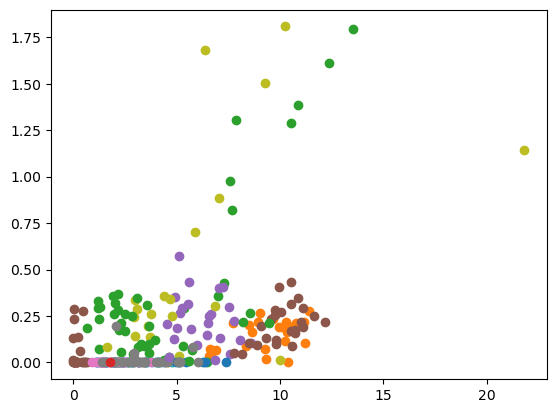

In [6]:
# Create DataFrame
df = pd.DataFrame(qualities)


# Correlation
corr = df["Spin_relaxation_quality"].corr(df["Chemical_shift_quality"])
print(f"Pearson correlation: {corr:.3f}")

# Plot
plt.figure()

systems_in_qualities = df["System"].unique()

for system in systems_in_qualities:
    subset = df[df["System"] == system]
    plt.scatter(
        subset["Spin_relaxation_quality"],
        subset["Chemical_shift_quality"],
        label=system
    )

# Regression line
x = df["Spin_relaxation_quality"]
y = df["Chemical_shift_quality"]
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Spin relaxation quality")
plt.ylabel("Chemical shift quality")
plt.title("Correlation between spin relaxation and chemical shift quality")

plt.legend(title="System", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

# Show average quality metrics for different force fields


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


<Figure size 1000x500 with 0 Axes>

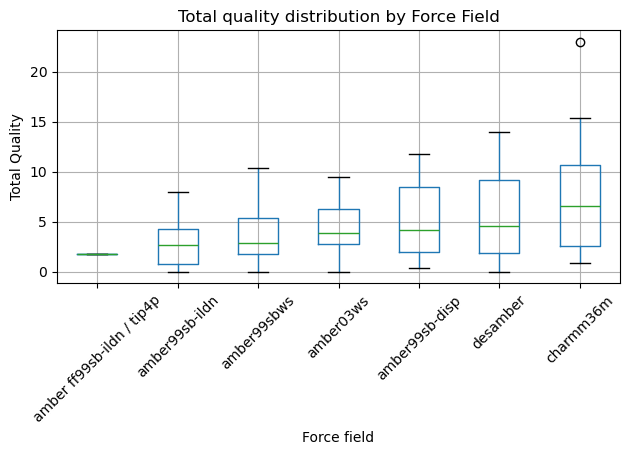

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


<Figure size 1000x500 with 0 Axes>

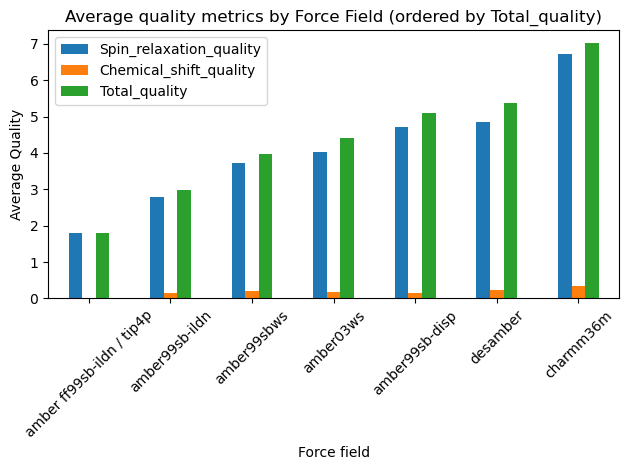

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame
df = pd.DataFrame(qualities)

# Step 1: Normalize FF names: lowercase and strip spaces
df['Force field'] = df['Force field'].astype(str).str.strip().str.lower()

# Step 2: Map variant names to canonical names
ff_canonical = {
    'amberff03ws': 'amber03ws',
    'amber03ws': 'amber03ws',
    'amber99sbws': 'amber99sbws',
    'amber99sb-disp': 'amber99sb-disp',
    'desamber': 'desamber',
    'charmm36m': 'charmm36m',
}

# Apply mapping, unknowns stay the same
df['Force field'] = df['Force field'].map(lambda x: ff_canonical.get(x, x))

# Step 3: Remove invalid or missing FFs
df.loc[df['Force field'].isin(['none','nan','unknown']), 'Force field'] = pd.NA
df_ff = df[df['Force field'].notna()]

# Step 4: Determine order (by mean Total_quality)
order = df_ff.groupby('Force field')['Total_quality'].mean().sort_values().index
df_ff['Force field'] = pd.Categorical(df_ff['Force field'], categories=order, ordered=True)

# -------------------------
# Box plot: Total_quality per Force field
# -------------------------
plt.figure(figsize=(10,5))
df_ff.boxplot(column='Total_quality', by='Force field')
plt.title("Total quality distribution by Force Field")
plt.suptitle("")
plt.ylabel("Total Quality")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------
# Bar plot: average quality metrics per Force field
# -------------------------
avg_quality = df_ff.groupby('Force field')[["Spin_relaxation_quality",
                                           "Chemical_shift_quality",
                                           "Total_quality"]].mean().loc[order]

plt.figure(figsize=(10,5))
avg_quality.plot(kind='bar')
plt.ylabel("Average Quality")
plt.title("Average quality metrics by Force Field (ordered by Total_quality)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


FOLDED
                Spin_relaxation_quality  Chemical_shift_quality  Total_quality
Force field                                                                   
amber99sbws                    0.107424                0.000000       0.107424
amber99sb-ildn                 0.160372                0.040618       0.200990
amber03ws                      0.608861                0.215902       0.824763
desamber                       3.121130                0.028809       3.149939
amber99sb-disp                 3.151327                0.036866       3.188193


<Figure size 1000x500 with 0 Axes>

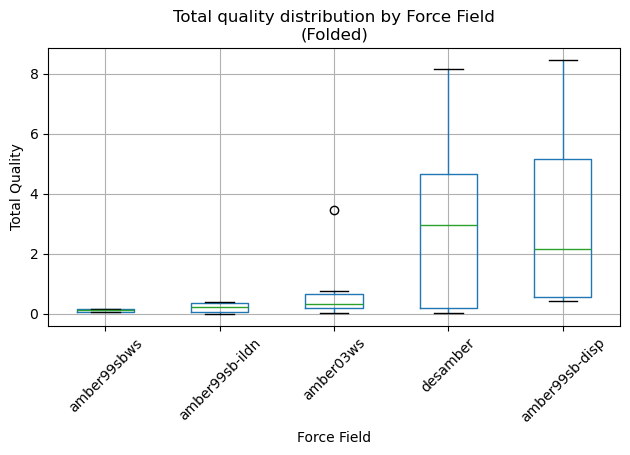

<Figure size 1000x500 with 0 Axes>

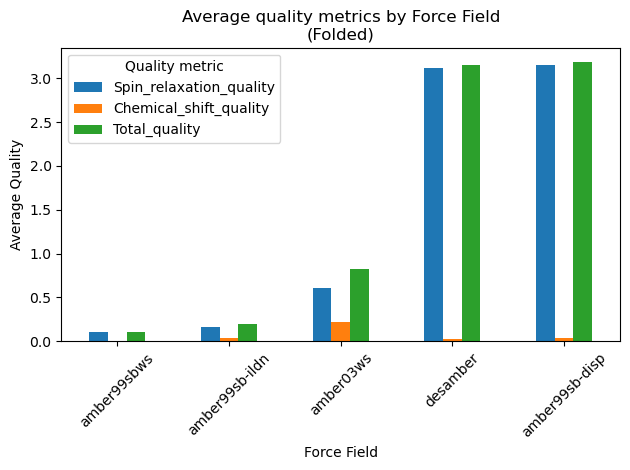


PARTIALLY_FOLDED
                Spin_relaxation_quality  Chemical_shift_quality  Total_quality
Force field                                                                   
amber99sbws                    3.356419                0.164474       3.823378
amber99sb-ildn                 3.452909                0.185330       3.916508
amber03ws                      3.403555                0.284815       4.091601
amber99sb-disp                 5.198475                0.283319       6.729766
desamber                       5.335840                0.599215       7.442064
charmm36m                     10.329368                0.839469      11.341130


<Figure size 1000x500 with 0 Axes>

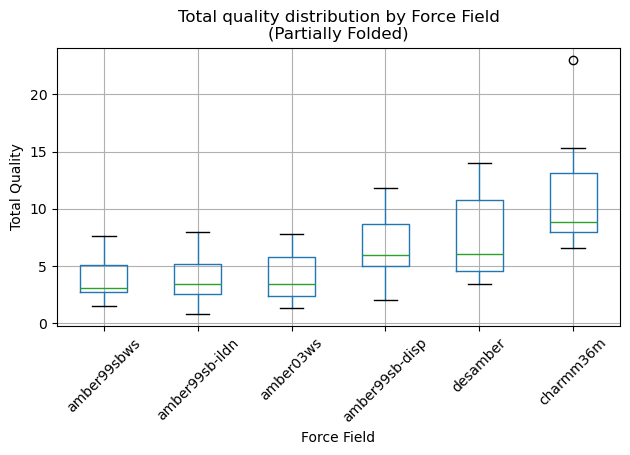

<Figure size 1000x500 with 0 Axes>

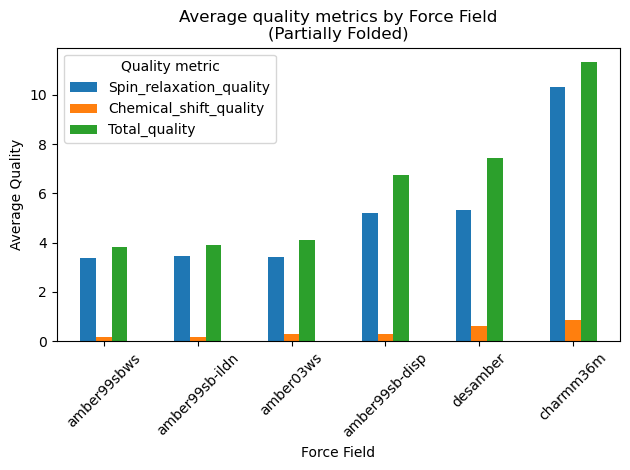


UNFOLDED
                Spin_relaxation_quality  Chemical_shift_quality  Total_quality
Force field                                                                   
amber99sbws                    4.435107                0.263245       4.594351
amber99sb-disp                 4.952488                0.122016       5.042866
amber03ws                      4.996033                0.136158       5.156728
desamber                       5.324718                0.147071       5.421479
charmm36m                      5.661901                0.122046       5.737711


<Figure size 1000x500 with 0 Axes>

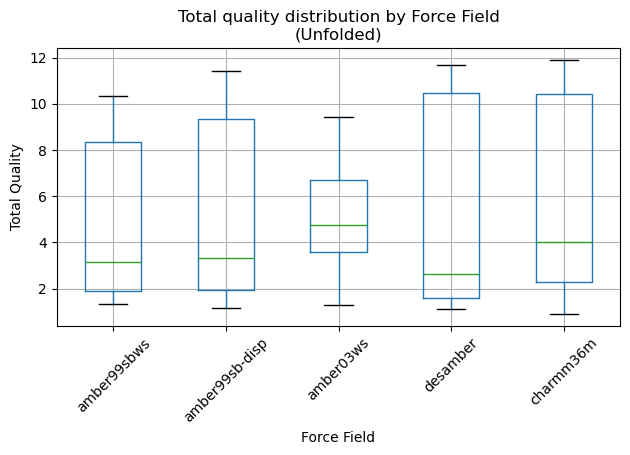

<Figure size 1000x500 with 0 Axes>

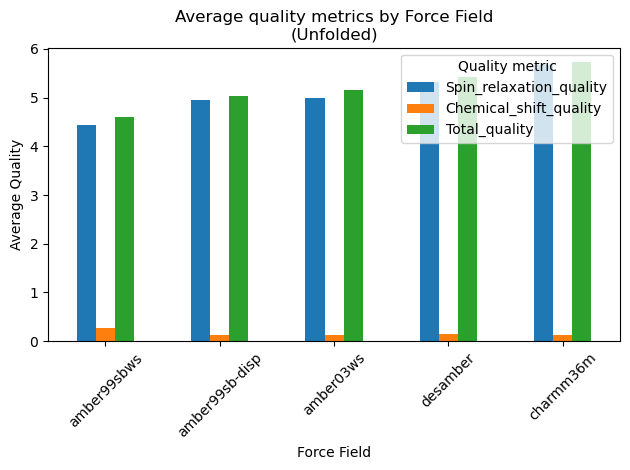

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Convert to DataFrame
# =========================================================

df = pd.DataFrame(qualities)


# =========================================================
# Normalize force-field names
# =========================================================

df['Force field'] = (
    df['Force field']
    .astype(str)
    .str.strip()
    .str.lower()
)


# =========================================================
# Map variant names to canonical names
# =========================================================

ff_canonical = {
    'amberff03ws': 'amber03ws',
    'amber03ws': 'amber03ws',
    'amber99sbws': 'amber99sbws',
    'amber99sb-disp': 'amber99sb-disp',
    'desamber': 'desamber',
    'charmm36m': 'charmm36m',
}

df['Force field'] = df['Force field'].map(
    lambda x: ff_canonical.get(x, x)
)


# =========================================================
# Remove invalid / missing force fields
# =========================================================

df.loc[
    df['Force field'].isin(['none', 'nan', 'unknown']),
    'Force field'
] = pd.NA

df_ff = df[df['Force field'].notna()].copy()


# =========================================================
# Protein classes to plot
# =========================================================

protein_classes = [
    'folded',
    'partially_folded',
    'unfolded'
]


# =========================================================
# Calculate and plot separately for each protein class
# =========================================================

for protein_class in protein_classes:

    # -----------------------------------------------------
    # Select protein class
    # -----------------------------------------------------

    df_class = df_ff[
        df_ff['Protein_class'] == protein_class
    ].copy()

    # Skip if no data
    if df_class.empty:
        print(
            f"No data available for {protein_class}"
        )
        continue


    # =====================================================
    # Determine force-field order
    # =====================================================

    order = (
        df_class
        .dropna(subset=['Total_quality'])
        .groupby('Force field')['Total_quality']
        .mean()
        .sort_values()
        .index
    )

    df_class['Force field'] = pd.Categorical(
        df_class['Force field'],
        categories=order,
        ordered=True
    )


    # =====================================================
    # Print averages
    # =====================================================

    print(
        f"\n{'=' * 60}\n"
        f"{protein_class.upper()}\n"
        f"{'=' * 60}"
    )

    avg_quality = (
        df_class
        .groupby('Force field', observed=True)[
            [
                'Spin_relaxation_quality',
                'Chemical_shift_quality',
                'Total_quality'
            ]
        ]
        .mean()
        .loc[order]
    )

    print(avg_quality)


    # =====================================================
    # Box plot: Total quality per force field
    # =====================================================

    plt.figure(figsize=(10, 5))

    df_class.boxplot(
        column='Total_quality',
        by='Force field'
    )

    plt.title(
        f"Total quality distribution by Force Field\n"
        f"({protein_class.replace('_', ' ').title()})"
    )

    plt.suptitle("")
    plt.ylabel("Total Quality")
    plt.xlabel("Force Field")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


    # =====================================================
    # Bar plot: average quality metrics per force field
    # =====================================================

    plt.figure(figsize=(10, 5))

    avg_quality.plot(
        kind='bar'
    )

    plt.ylabel("Average Quality")

    plt.title(
        f"Average quality metrics by Force Field\n"
        f"({protein_class.replace('_', ' ').title()})"
    )

    plt.xlabel("Force Field")
    plt.xticks(rotation=45)

    plt.legend(
        title="Quality metric"
    )

    plt.tight_layout()
    plt.show()

# Plotting the average qualities for each system

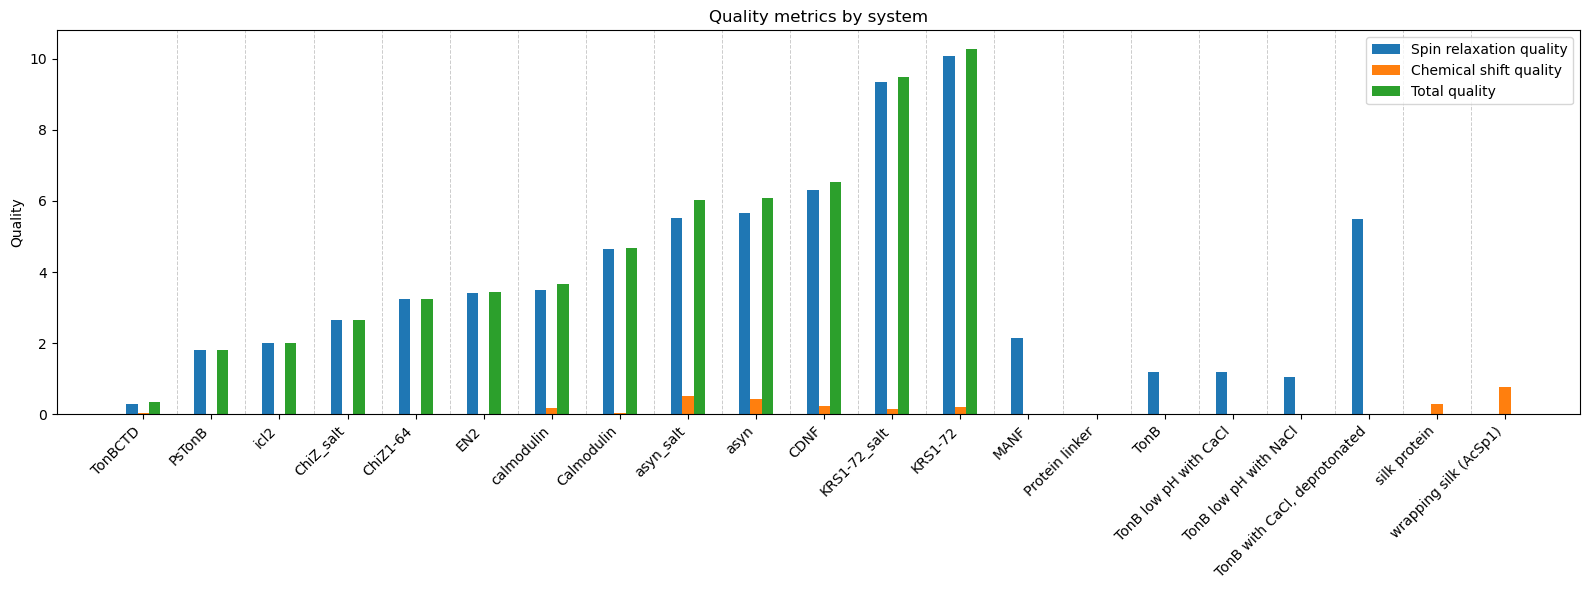


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


<Figure size 1400x600 with 0 Axes>

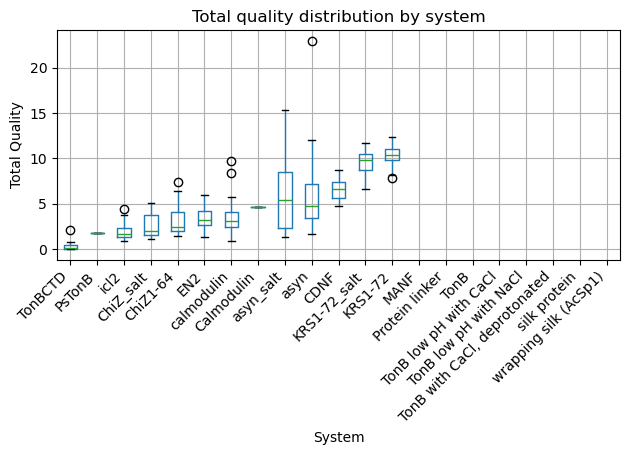

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert to DataFrame
df = pd.DataFrame(qualities)

# -------------------------
# Calculate averages independently
# -------------------------

spin_quality = (
    df.dropna(subset=["Spin_relaxation_quality"])
      .groupby("System")["Spin_relaxation_quality"]
      .mean()
)

shift_quality = (
    df.dropna(subset=["Chemical_shift_quality"])
      .groupby("System")["Chemical_shift_quality"]
      .mean()
)

total_quality = (
    df.dropna(subset=["Total_quality"])
      .groupby("System")["Total_quality"]
      .mean()
)


# =========================================================
# Order systems by increasing Total_quality
# =========================================================

# Systems that have Total_quality are sorted by their mean
systems_with_total = total_quality.sort_values().index.tolist()

# Systems without Total_quality are added afterwards
all_systems = (
    set(spin_quality.index)
    | set(shift_quality.index)
    | set(total_quality.index)
)

systems_without_total = sorted(
    all_systems - set(systems_with_total)
)

systems_to_plot = systems_with_total + systems_without_total


# =========================================================
# 1. Bar plot: quality metrics by system
# =========================================================

x = np.arange(len(systems_to_plot)) * 1.5
width = 0.25

plt.figure(figsize=(16, 6))

# Define colors for the three quality metrics
colors = {
    "spin": "tab:blue",
    "shift": "tab:orange",
    "total": "tab:green"
}

for i, system in enumerate(systems_to_plot):

    if system in spin_quality.index:
        plt.bar(
            x[i] - width,
            spin_quality[system],
            width,
            color=colors["spin"],
            label="Spin relaxation quality" if i == 0 else ""
        )

    if system in shift_quality.index:
        plt.bar(
            x[i],
            shift_quality[system],
            width,
            color=colors["shift"],
            label="Chemical shift quality" if i == 0 else ""
        )

    if system in total_quality.index:
        plt.bar(
            x[i] + width,
            total_quality[system],
            width,
            color=colors["total"],
            label="Total quality" if i == 0 else ""
        )

# Add separators between systems
for i in range(len(systems_to_plot) - 1):
    plt.axvline(
        (x[i] + x[i + 1]) / 2,
        color="gray",
        linestyle="--",
        linewidth=0.7,
        alpha=0.4
    )

plt.ylabel("Quality")
plt.title("Quality metrics by system")

plt.xticks(
    x,
    systems_to_plot,
    rotation=45,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()


# =========================================================
# 2. Boxplot: distribution of Total_quality
# =========================================================

# Only simulations where Total_quality exists
df_total = df.dropna(subset=["Total_quality"])

# Explicitly set the same system order
df_total["System"] = pd.Categorical(
    df_total["System"],
    categories=systems_to_plot,
    ordered=True
)

plt.figure(figsize=(14, 6))

df_total.boxplot(
    column="Total_quality",
    by="System"
)

plt.title("Total quality distribution by system")
plt.suptitle("")
plt.ylabel("Total Quality")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
import os
import re
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


# =========================================================
# Quality files
# =========================================================

QUALITY_FILES = {
    "Spin relaxation": "spin_relaxation_quality.yaml",
    "Chemical shift": "chemical_shift_quality.yaml",
}


# =========================================================
# Keys to ignore
# =========================================================

SKIP_KEYS = {
    "Averages",
    "overall_non_zero_percentage",
    "overall_percentage",
}


# =========================================================
# Amino-acid classification
# =========================================================

AA_CLASSES = {
    "Positively charged": ["ARG", "LYS", "HIS"],
    "Negatively charged": ["ASP", "GLU"],
    "Polar uncharged": ["SER", "THR", "ASN", "GLN", "TYR", "CYS"],
    "Hydrophobic": ["ALA", "VAL", "LEU", "ILE", "MET", "PHE", "TRP"],
    "Special": ["GLY", "PRO"],
}


# Ordered list of residue types for x-axis
ORDERED_RESIDUES = [
    aa
    for group in AA_CLASSES.values()
    for aa in group
]


# Colors for amino-acid classes
AA_CLASS_COLORS = {
    "Positively charged": "#e41a1c",
    "Negatively charged": "#377eb8",
    "Polar uncharged": "#4daf4a",
    "Hydrophobic": "#ff7f00",
    "Special": "#984ea3",
}


# =========================================================
# Extract force field
# =========================================================

def extract_force_field(system):

    trj_file = system['TRJ'][0][0]
    FF = system['FF']

    matchFF = re.search(
        r'(DESAMBER|AMBER99SBWS|CHARMM|AMBER99SB-DISP|'
        r'AMBER03WS|AMBERFF03WS|amber99SB-ILDN)',
        FF,
        re.IGNORECASE
    )

    match = re.search(
        r'_(DESAMBER|AMBER99SBWS|CHARMM|AMBER99SB-DISP|'
        r'AMBER03WS|AMBERFF03WS|amber99SB-ILDN)[^_]*_',
        trj_file,
        re.IGNORECASE
    )

    if matchFF:

        ff = matchFF.group(1).upper()

        if ff == 'AMBERFF03WS':
            return 'AMBER03WS'

        return ff

    elif match:

        ff = match.group(1).upper()

        if ff == 'AMBERFF03WS':
            return 'AMBER03WS'

        return ff

    else:

        print(
            "Could not identify force field:",
            trj_file,
            FF
        )

        return "UNKNOWN"


# =========================================================
# Process quality file
# =========================================================

def process_quality_file(filename, systems, protein_class):
    """
    Calculate average quality for each residue type and force field.

    The YAML files have the structure, e.g.:

        100LEU:
          R1: 3.16
          R2: 0.058
          hetNOE: 7.48

        101GLY:
          R1: 4.36
          R2: 0
          hetNOE: 6.93

    For every residue occurrence:

        1. Extract all numerical quality values.
        2. Include zeros in the average.
        3. Calculate the average over the observables for that residue.

    Then:

        average over all occurrences of the same residue type
        within each force field.

    Returns
    -------
    avg_residue_data:
        avg_residue_data[force_field][residue_type]
        = average quality

    ff_overall_averages:
        ff_overall_averages[force_field]
        = average quality over all residue occurrences
    """

    # Store residue-level averages
    residue_data = defaultdict(lambda: defaultdict(list))

    # ---------------------------------------------------------
    # Loop over systems/files
    # ---------------------------------------------------------

    for system in systems:

        #print(system)
        dataFolder = (
            databankPath
            + 'Data/Simulations/'
            + system['path']
            + '/'
        )

        force_field = extract_force_field(system)

        file_path = dataFolder + filename

        # -----------------------------------------------------
        # Protein-class filtering
        # -----------------------------------------------------

        infile = dataFolder + 'stable_contacts.json'

        if protein_class != 'all':

            if not os.path.isfile(infile):
                continue

            with open(infile, 'r') as f:
                results = json.load(f)

            system_id = str(
                system.get('ID', system['path'])
            )

            stable_contacts = (
                results[system_id]['frac_residues_stable']
            )

            if (
                protein_class == 'folded'
                and stable_contacts < 0.8
            ):
                continue

            if (
                protein_class == 'unfolded'
                and stable_contacts > 0.3
            ):
                continue

            if protein_class == 'partially_folded':

                if stable_contacts > 0.8:
                    continue

                if stable_contacts < 0.3:
                    continue

        # -----------------------------------------------------
        # Read quality file
        # -----------------------------------------------------

        try:

            with open(file_path, 'r') as f:
                data = yaml.safe_load(f)

        except FileNotFoundError:
            continue

        if not data:
            continue

        # -----------------------------------------------------
        # Loop over residues
        # -----------------------------------------------------

        for residue_key, info in data.items():

            # Skip non-residue entries
            if residue_key in SKIP_KEYS:
                continue

            # Must contain a dictionary of quality values
            if not isinstance(info, dict):
                continue

            # -------------------------------------------------
            # Extract residue type
            #
            # Examples:
            #   100LEU -> LEU
            #   101GLY -> GLY
            #   102LYS -> LYS
            # -------------------------------------------------

            match = re.search(
                r'[A-Z]+$',
                residue_key
            )

            if not match:
                continue

            residue_type = match.group(0)

            # -------------------------------------------------
            # Extract numerical quality values
            #
            # IMPORTANT:
            # zeros ARE included.
            # -------------------------------------------------

            quality_values = []

            for value in info.values():

                if value is None:
                    continue

                try:
                    value = float(value)

                except (TypeError, ValueError):
                    continue

                # Include zero!
                quality_values.append(value)

            # No numerical values available
            if not quality_values:
                continue

            # -------------------------------------------------
            # Average quality for this residue occurrence
            # -------------------------------------------------

            residue_average = (
                sum(quality_values)
                / len(quality_values)
            )

            residue_data[
                force_field
            ][
                residue_type
            ].append(residue_average)

    # =========================================================
    # Calculate averages by residue type
    # =========================================================

    avg_residue_data = defaultdict(dict)

    ff_overall_averages = {}

    for ff, residues in residue_data.items():

        all_vals = []

        for res_type, vals in residues.items():

            if not vals:
                continue

            # Average over all occurrences of this residue type
            avg_residue_data[ff][res_type] = (
                sum(vals) / len(vals)
            )

            all_vals.extend(vals)

        # Average over all residue occurrences
        if all_vals:

            ff_overall_averages[ff] = (
                sum(all_vals)
                / len(all_vals)
            )

        else:

            ff_overall_averages[ff] = 0.0

    return (
        avg_residue_data,
        ff_overall_averages
    )


# =========================================================
# Plot quality
# =========================================================

def plot_quality(avg_residue_data, title):

    plt.figure(figsize=(14, 6))

    # ---------------------------------------------------------
    # Keep only residues that actually exist
    # ---------------------------------------------------------

    residue_types = [
        aa
        for aa in ORDERED_RESIDUES
        if any(
            aa in residues
            for residues in avg_residue_data.values()
        )
    ]

    x_positions = np.arange(
        len(residue_types)
    )

    # ---------------------------------------------------------
    # Plot force fields
    # ---------------------------------------------------------

    for ff, residues in avg_residue_data.items():

        values = [
            residues.get(
                res,
                np.nan
            )
            for res in residue_types
        ]

        plt.plot(
            x_positions,
            values,
            marker='o',
            label=ff
        )

    # ---------------------------------------------------------
    # Background shading by residue class
    # ---------------------------------------------------------

    start = 0

    for cls, aas in AA_CLASSES.items():

        cls_residues = [
            aa
            for aa in aas
            if aa in residue_types
        ]

        if not cls_residues:
            continue

        end = start + len(cls_residues)

        plt.axvspan(
            start - 0.5,
            end - 0.5,
            color=AA_CLASS_COLORS[cls],
            alpha=0.35,
            label=cls
        )

        start = end

    # ---------------------------------------------------------
    # Axis formatting
    # ---------------------------------------------------------

    plt.xticks(
        x_positions,
        residue_types,
        rotation=45
    )

    plt.xlabel("Residue type")
    plt.ylabel("Average quality")
    plt.title(title)

    plt.ylim(bottom=0)

    # ---------------------------------------------------------
    # De-duplicate legend entries
    # ---------------------------------------------------------

    handles, labels = (
        plt.gca().get_legend_handles_labels()
    )

    unique = dict(
        zip(labels, handles)
    )

    plt.legend(
        unique.values(),
        unique.keys(),
        title="Force field / residue class"
    )

    plt.tight_layout()

    plt.savefig(
        'res_quality.pdf',
        bbox_inches='tight'
    )

    plt.show()


# =========================================================
# Run everything
# =========================================================

for label, filename in QUALITY_FILES.items():

    # -----------------------------------------------------
    # Select protein class
    # -----------------------------------------------------

    protein_class = 'folded'
    # protein_class = 'unfolded'
    #protein_class = 'partially_folded'
    #protein_class = 'all'

    # -----------------------------------------------------
    # Process
    # -----------------------------------------------------

    (
        avg_residue_data,
        ff_overall_averages
    ) = process_quality_file(
        filename,
        systems,
        protein_class
    )

    # -----------------------------------------------------
    # Print overall averages
    # -----------------------------------------------------

    print(
        f"\n{label}: "
        f"average quality over all residues"
    )

    for ff, avg in ff_overall_averages.items():

        print(
            f"  {ff:15s}: {avg:8.3f}"
        )

    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------

    plot_quality(
        avg_residue_data,
        f"{label}: average quality per residue type "
        f"by force field"
    )

TypeError: expected string or bytes-like object, got 'NoneType'

# Quality based on non-zero percentages

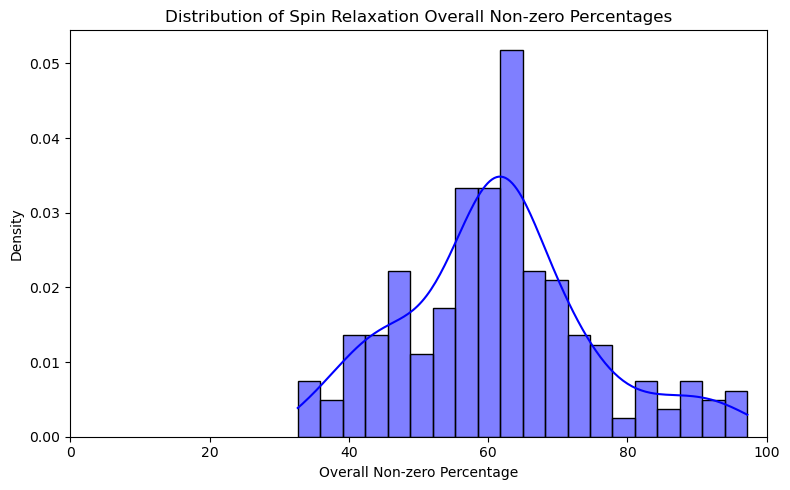

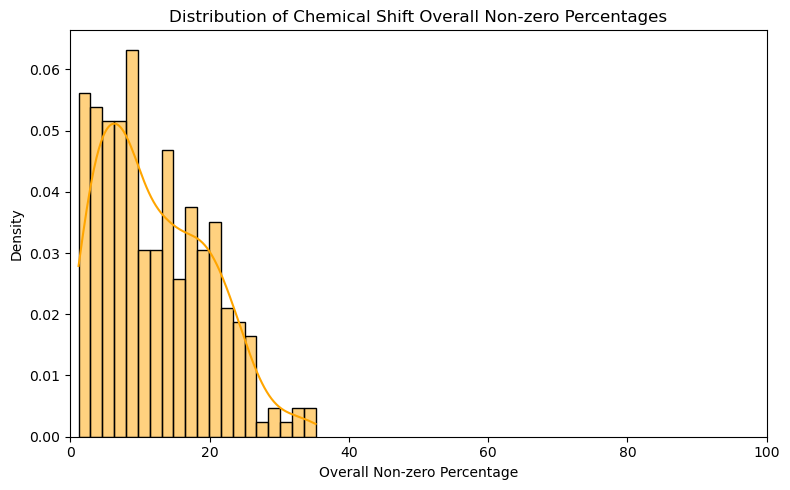

In [2]:
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

spin_overall = []
shift_overall = []

for system in systems:
    dataFolder = databankPath + 'Data/Simulations/' + system['path'] + '/'

    spin_file = dataFolder + 'spin_relaxation_res_quality.yaml'
    shift_file = dataFolder + 'chemical_shift_res_quality.yaml'

    # Load spin relaxation overall percentage
    try:
        with open(spin_file, 'r') as f:
            spin_data = yaml.safe_load(f)
        if 'overall_non_zero_percentage' in spin_data:
            spin_overall.append(spin_data['overall_non_zero_percentage'])
    except FileNotFoundError:
        pass
        #print(f"Warning: {spin_file} not found")

    # Load chemical shift overall percentage
    try:
        with open(shift_file, 'r') as f:
            shift_data = yaml.safe_load(f)
        if 'overall_non_zero_percentage' in shift_data:
            shift_overall.append(shift_data['overall_non_zero_percentage'])
    except FileNotFoundError:
        pass
        #print(f"Warning: {shift_file} not found")

# Plot spin relaxation overall percentages
plt.figure(figsize=(8, 5))
sns.histplot(spin_overall, color='blue', kde=True, stat='density', bins=20)
plt.xlabel('Overall Non-zero Percentage')
plt.ylabel('Density')
plt.title('Distribution of Spin Relaxation Overall Non-zero Percentages')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# Plot chemical shift overall percentages
plt.figure(figsize=(8, 5))
sns.histplot(shift_overall, color='orange', kde=True, stat='density', bins=20)
plt.xlabel('Overall Non-zero Percentage')
plt.ylabel('Density')
plt.title('Distribution of Chemical Shift Overall Non-zero Percentages')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


In [4]:
def extract_force_field(system):
    #try:
    trj_file = system['TRJ'][0][0]
    #except (IndexError, TypeError):
    #    return "UNKNOWN"

    FF = system['FF']
    
    matchFF = re.search(r'(DESAMBER|AMBER99SBWS|CHARMM|AMBER99SB-DISP|AMBER03WS|AMBERFF03WS|amber99SB-ILDN)', FF, re.IGNORECASE)
    match = re.search(r'_(DESAMBER|AMBER99SBWS|CHARMM|AMBER99SB-DISP|AMBER03WS|AMBERFF03WS|amber99SB-ILDN)[^_]*_', trj_file, re.IGNORECASE)
    if matchFF:
        if matchFF.group(1).upper() == 'AMBERFF03WS':
            return 'AMBER03WS'
        else:
            return matchFF.group(1).upper() #if match 
    elif match:
        if match.group(1).upper() == 'AMBERFF03WS':
            return 'AMBER03WS'
        else:
            return match.group(1).upper() #if match 
            
    else: 
        print(trj_file, FF, matchFF)
        return "UNKNOWN"


def process_quality_file(filename, systems, protein_class):
    """
    Returns:
      avg_residue_data[force_field][residue_type] = average percentage
      ff_overall_averages[force_field] = average over all residues
    """
    residue_data = defaultdict(lambda: defaultdict(list))

    for system in systems:
        dataFolder = databankPath + 'Data/Simulations/' + system['path'] + '/'
        force_field = extract_force_field(system)
        file_path = dataFolder + filename

        infile = dataFolder + 'stable_contacts.json'

        if protein_class != 'all':
            if not os.path.isfile(infile):
                continue

            with open(infile, 'r') as f:
                results = json.load(f)

            system_id = str(system.get('ID', system['path']))
            stable_contacts = results[system_id]['frac_residues_stable']
            if protein_class == 'folded' and stable_contacts < 0.8:
                continue
            if protein_class == 'unfolded' and stable_contacts > 0.3:
                continue
            if protein_class == 'partially_folded' and stable_contacts > 0.8:
                continue
            if protein_class == 'partially_folded' and stable_contacts < 0.3:
                continue

        
        
        try:
            with open(file_path, 'r') as f:
                data = yaml.safe_load(f)
        except FileNotFoundError:
            continue

        for residue_key, info in data.items():

            if residue_key in SKIP_KEYS:
                continue

            if not (isinstance(info, dict) and 'non_zero_percentage' in info):
                continue

            match = re.search(r'[A-Z]+$', residue_key)
            if not match:
                continue

            residue_type = match.group(0)
            residue_data[force_field][residue_type].append(
                info['non_zero_percentage']
            )

        #print(system['SYSTEM'],force_field,residue_data[force_field])
    
    avg_residue_data = defaultdict(dict)
    ff_overall_averages = {}

    for ff, residues in residue_data.items():
        all_vals = []

        for res_type, vals in residues.items():
            avg_residue_data[ff][res_type] = sum(vals) / len(vals)
            all_vals.extend(vals)

        ff_overall_averages[ff] = sum(all_vals) / len(all_vals) if all_vals else 0.0

    return avg_residue_data, ff_overall_averages


def plot_quality(avg_residue_data, title):
    plt.figure(figsize=(14, 6))

    # Keep only residues that actually exist in data
    residue_types = [
        aa for aa in ORDERED_RESIDUES
        if any(aa in residues for residues in avg_residue_data.values())
    ]

    x_positions = range(len(residue_types))

    # Plot force fields
    for ff, residues in avg_residue_data.items():
        values = [residues.get(res, 0.0) for res in residue_types]
        plt.plot(x_positions, values, marker='o', label=ff)

    # Background shading by residue class
    start = 0
    for cls, aas in AA_CLASSES.items():
        cls_residues = [aa for aa in aas if aa in residue_types]
        if not cls_residues:
            continue

        end = start + len(cls_residues)
        plt.axvspan(
            start - 0.5,
            end - 0.5,
            color=AA_CLASS_COLORS[cls],
            alpha=0.35,
            label=cls
        )
        start = end

    # Axis formatting
    plt.xticks(x_positions, residue_types, rotation=45)
    plt.xlabel("Residue type")
    plt.ylabel("Average non-zero percentage")
    plt.title(title)
    plt.ylim(0, 100)

    # De-duplicate legend entries
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    plt.legend(unique.values(), unique.keys(), title="Force field / residue class")

    plt.tight_layout()
    plt.show()
    plt.savefig('res_quality.pdf')
    
    



Spin relaxation: average non-zero percentage over all residues
  CHARMM    :  56.70 %
  DESAMBER  :  58.52 %
  AMBER99SBWS:  55.88 %
  AMBER99SB-DISP:  62.81 %
  AMBER03WS :  59.82 %


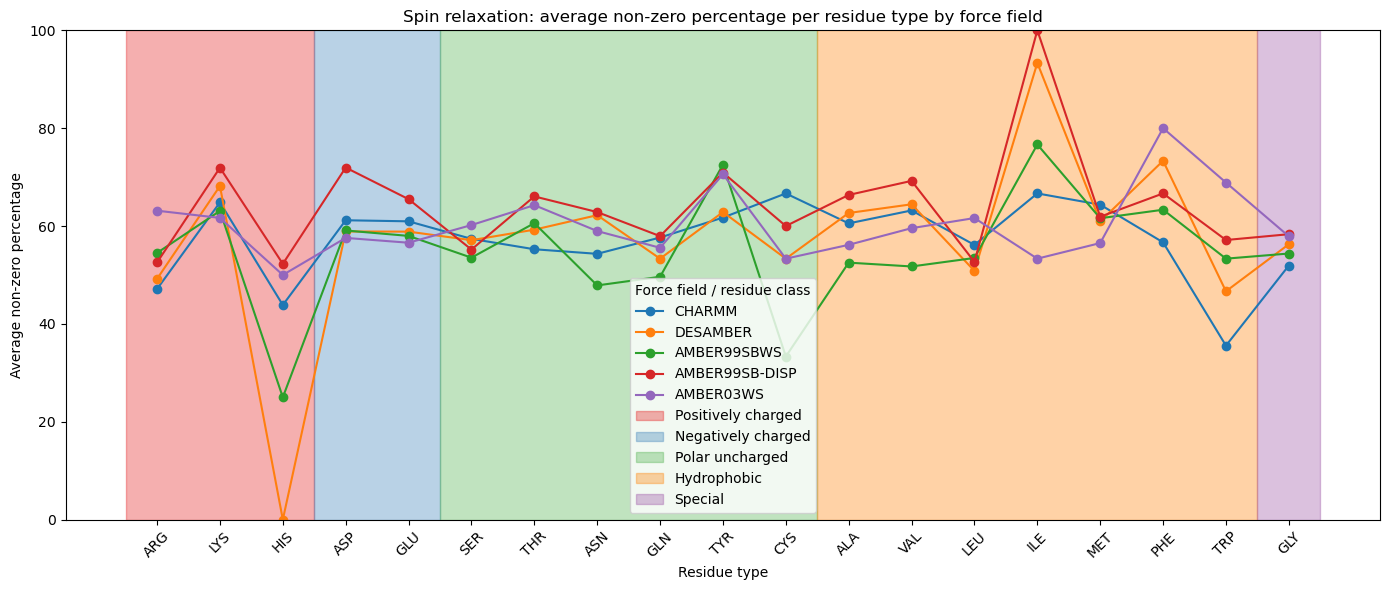


Chemical shift: average non-zero percentage over all residues
  CHARMM    :   7.34 %
  DESAMBER  :   8.07 %
  AMBER99SBWS:  12.56 %
  AMBER99SB-DISP:   8.87 %
  AMBER03WS :   9.41 %


<Figure size 640x480 with 0 Axes>

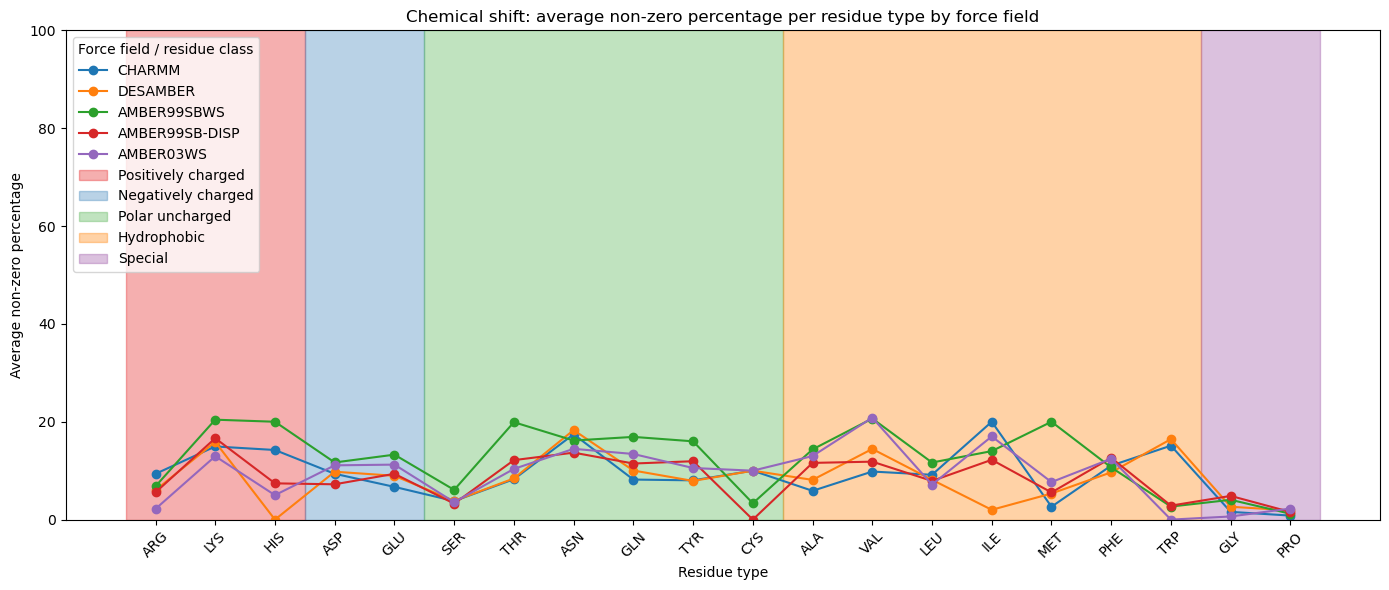

<Figure size 640x480 with 0 Axes>

In [5]:
import yaml
import matplotlib.pyplot as plt
from collections import defaultdict
import re

#databankPath = '/home/sosamuli/work/NMRlipids/IDPsimBank/'

QUALITY_FILES = {
    "Spin relaxation": "spin_relaxation_res_quality.yaml",
    "Chemical shift": "chemical_shift_res_quality.yaml",
}

SKIP_KEYS = {
    "Averages",
    "overall_non_zero_percentage",
    "overall_percentage",
}


# Amino-acid classification (standard biophysical grouping)
AA_CLASSES = {
    "Positively charged": ["ARG", "LYS", "HIS"],
    "Negatively charged": ["ASP", "GLU"],
    "Polar uncharged": ["SER", "THR", "ASN", "GLN", "TYR", "CYS"],
    "Hydrophobic": ["ALA", "VAL", "LEU", "ILE", "MET", "PHE", "TRP"],
    "Special": ["GLY", "PRO"],
}

# Ordered list of residue types for x-axis
ORDERED_RESIDUES = [aa for group in AA_CLASSES.values() for aa in group]


AA_CLASS_COLORS = {
    "Positively charged": "#e41a1c",  # strong red
    "Negatively charged": "#377eb8",  # strong blue
    "Polar uncharged": "#4daf4a",     # strong green
    "Hydrophobic": "#ff7f00",         # orange
    "Special": "#984ea3",             # purple
}


# ---- Run everything ----

for label, filename in QUALITY_FILES.items():
    #protein_class = 'folded'
    protein_class = 'unfolded'
    #protein_class = 'partially_folded'
    #protein_class = 'all'
    avg_residue_data, ff_overall_averages = process_quality_file(filename, systems,protein_class)

    print(f"\n{label}: average non-zero percentage over all residues")
    for ff, avg in ff_overall_averages.items():
        print(f"  {ff:10s}: {avg:6.2f} %")

    plot_quality(
        avg_residue_data,
        f"{label}: average non-zero percentage per residue type by force field"
    )


In [21]:
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re

# Example paths
#databankPath = '/home/sosamuli/work/NMRlipids/IDPsimBank/'
databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank

# Dictionary to store data: {force_field: {residue_type: [percentages]}}
residue_data = defaultdict(lambda: defaultdict(list))

for system in systems:
    dataFolder = databankPath + 'Data/Simulations/' + system['path'] + '/'
    
    # Extract force field from TRJ filename
    trj_file = system['TRJ'][0][0]  # [['filename']]
    # Example filename: aSyn_replica_03_AMBER99SBWS_2000ns.xtc
    match = re.search(r'_(AMBER|CHARMM|OPLS|GROMOS)[^_]*_', trj_file, re.IGNORECASE)
    if match:
        force_field = match.group(1).upper()
    else:
        force_field = "UNKNOWN"

    # Load spin relaxation YAML (or chemical shift, adjust if needed)
    spin_file = dataFolder + 'spin_relaxation_res_quality.yaml'
    try:
        with open(spin_file, 'r') as f:
            spin_data = yaml.safe_load(f)
        for residue_key, info in spin_data.items():
            if isinstance(info, dict) and 'non_zero_percentage' in info:
                # Extract residue type from residue key (e.g., 101GLY -> GLY)
                residue_type = re.findall(r'[A-Z]+$', residue_key)[0]
                residue_data[force_field][residue_type].append(info['non_zero_percentage'])
    except FileNotFoundError:
        print(f"Warning: {spin_file} not found")

# Compute average percentages per residue type and force field
avg_data = defaultdict(dict)
for ff, residues in residue_data.items():
    for res_type, percentages in residues.items():
        avg_data[ff][res_type] = sum(percentages) / len(percentages)

# Plotting
plt.figure(figsize=(12, 6))
res_types_sorted = sorted({res for residues in avg_data.values() for res in residues})

for ff, residues in avg_data.items():
    values = [residues.get(res, 0) for res in res_types_sorted]
    plt.plot(res_types_sorted, values, marker='o', label=ff)

plt.xlabel('Residue Type')
plt.ylabel('Average Non-zero Percentage')
plt.title('Average Non-zero Percentage per Residue Type by Force Field')
plt.ylim(0, 100)
plt.legend(title='Force Field')
plt.tight_layout()
plt.show()


IndexError: list index out of range

# Best protein simulation based on non-zero percentages

../../Data/Simulations/56f/b4a/56fb4a58dd1fd02c0c8651f6b1502cbef8de70a2/98cb10b22eb76b92238ac15a8c217e63464a7d1c/


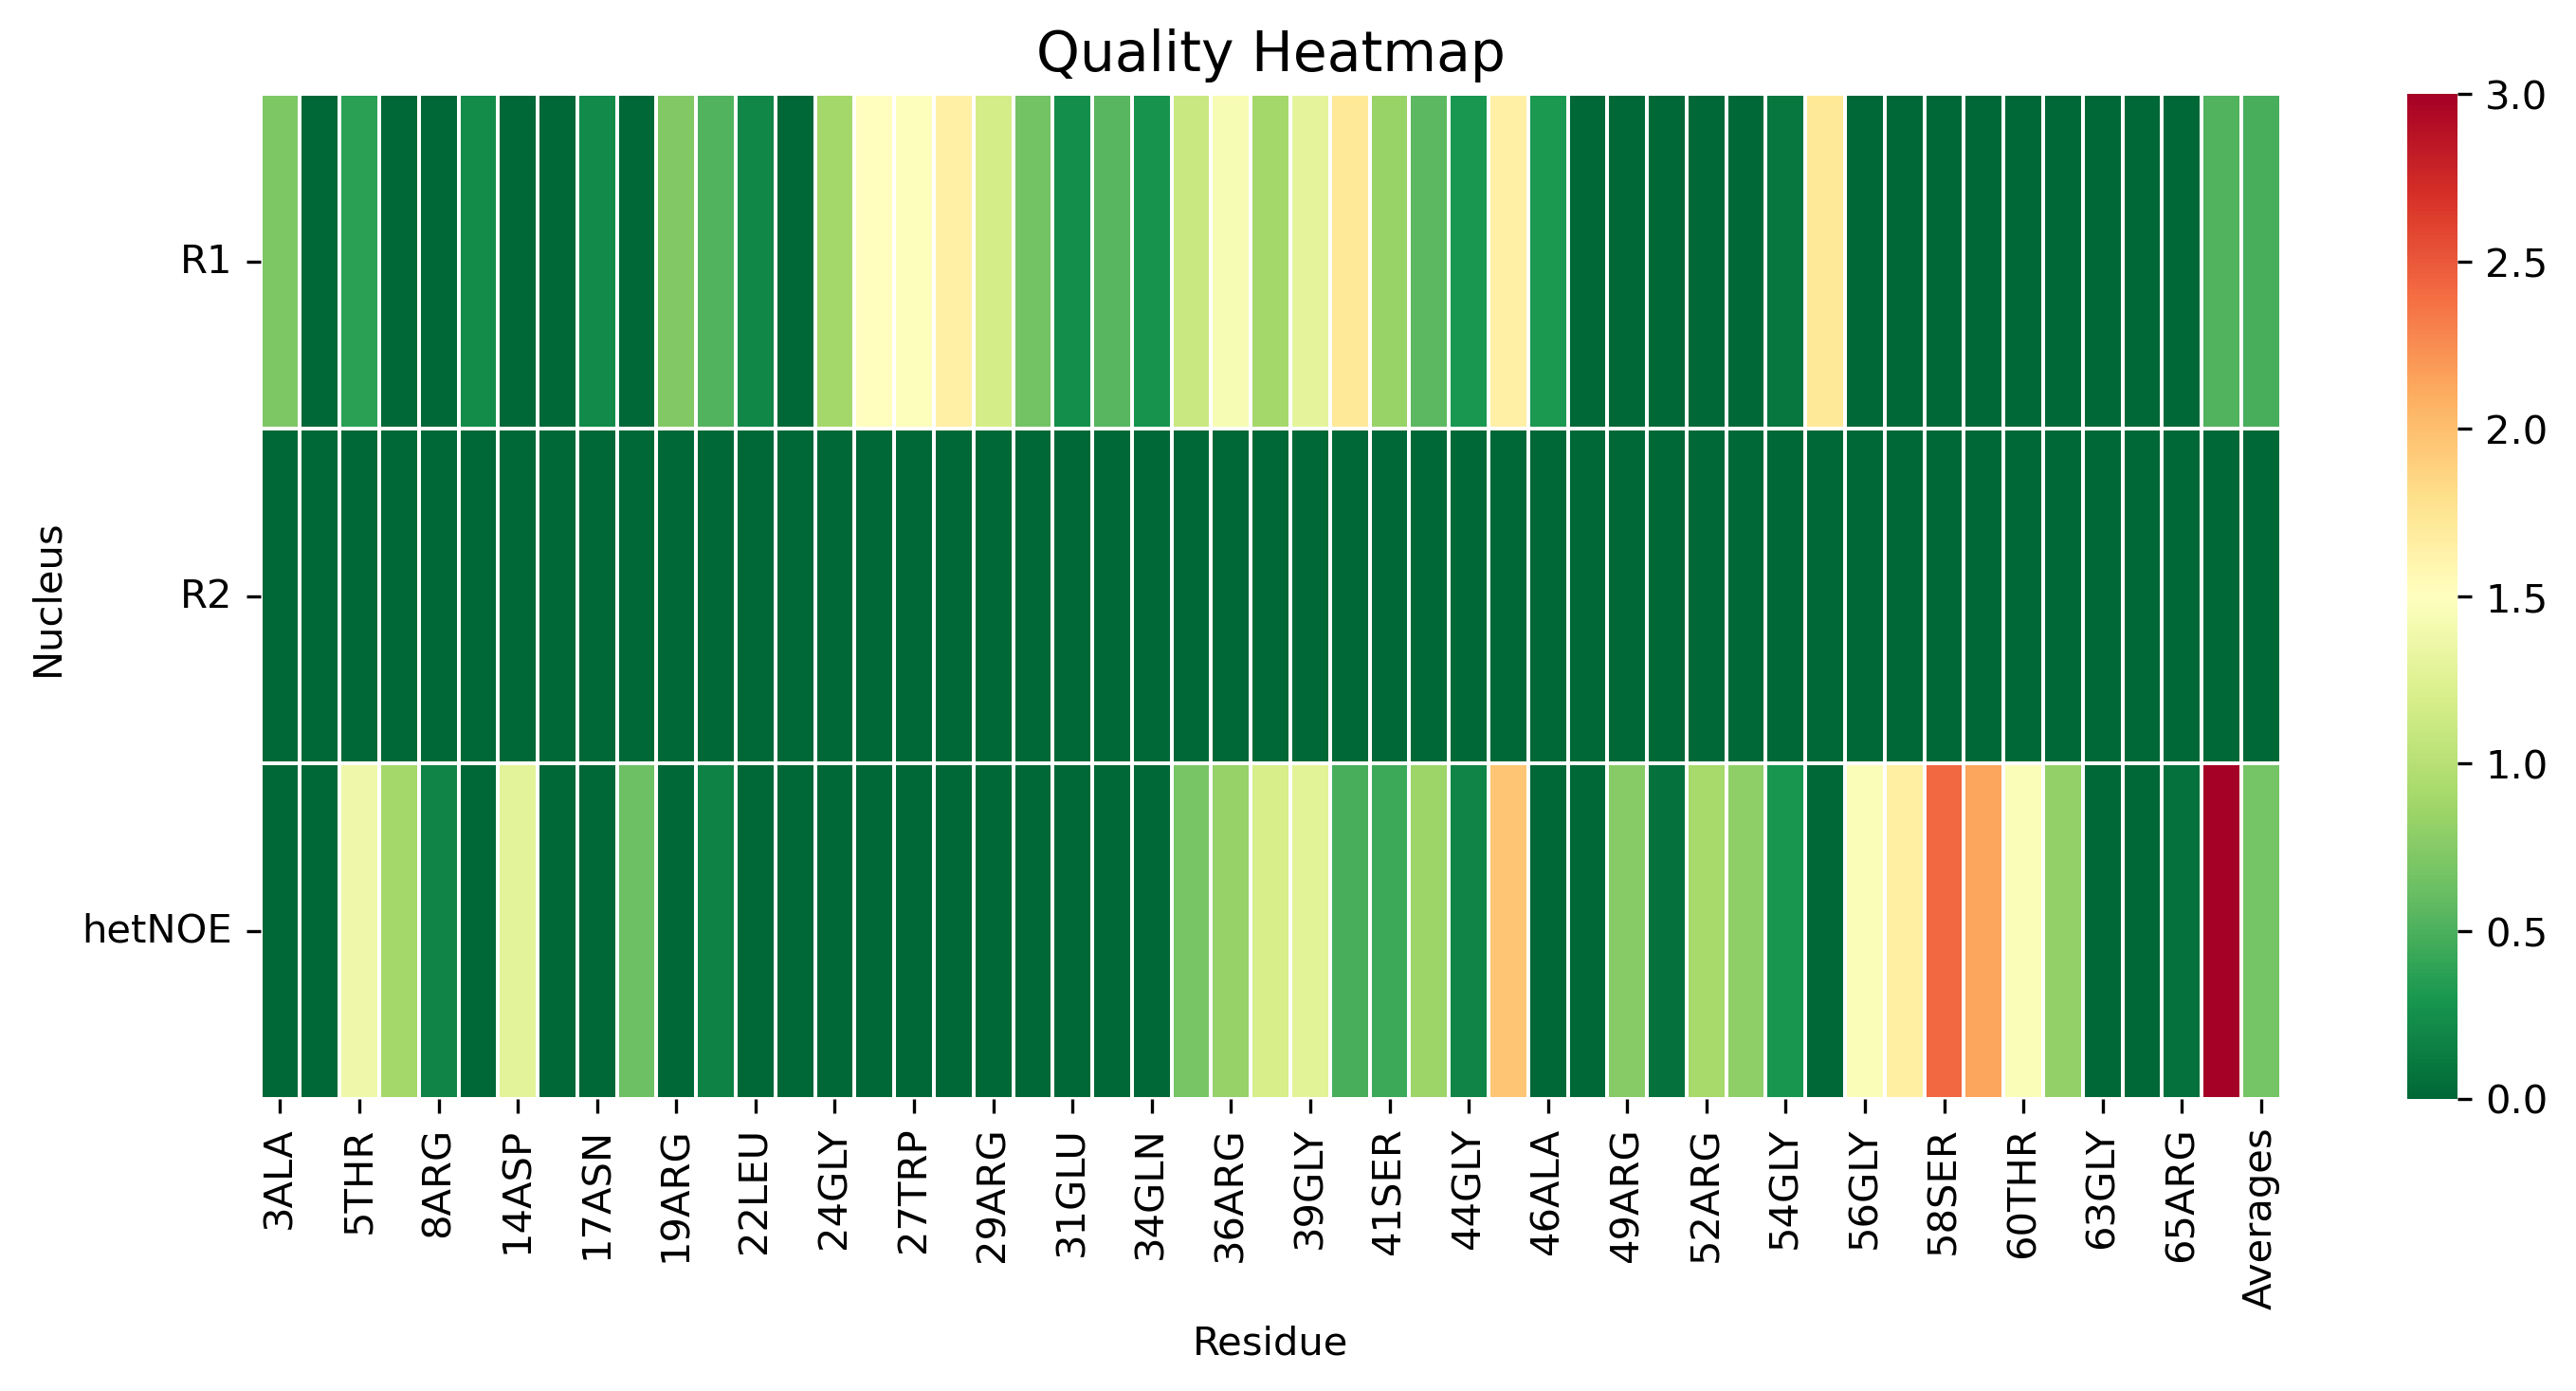

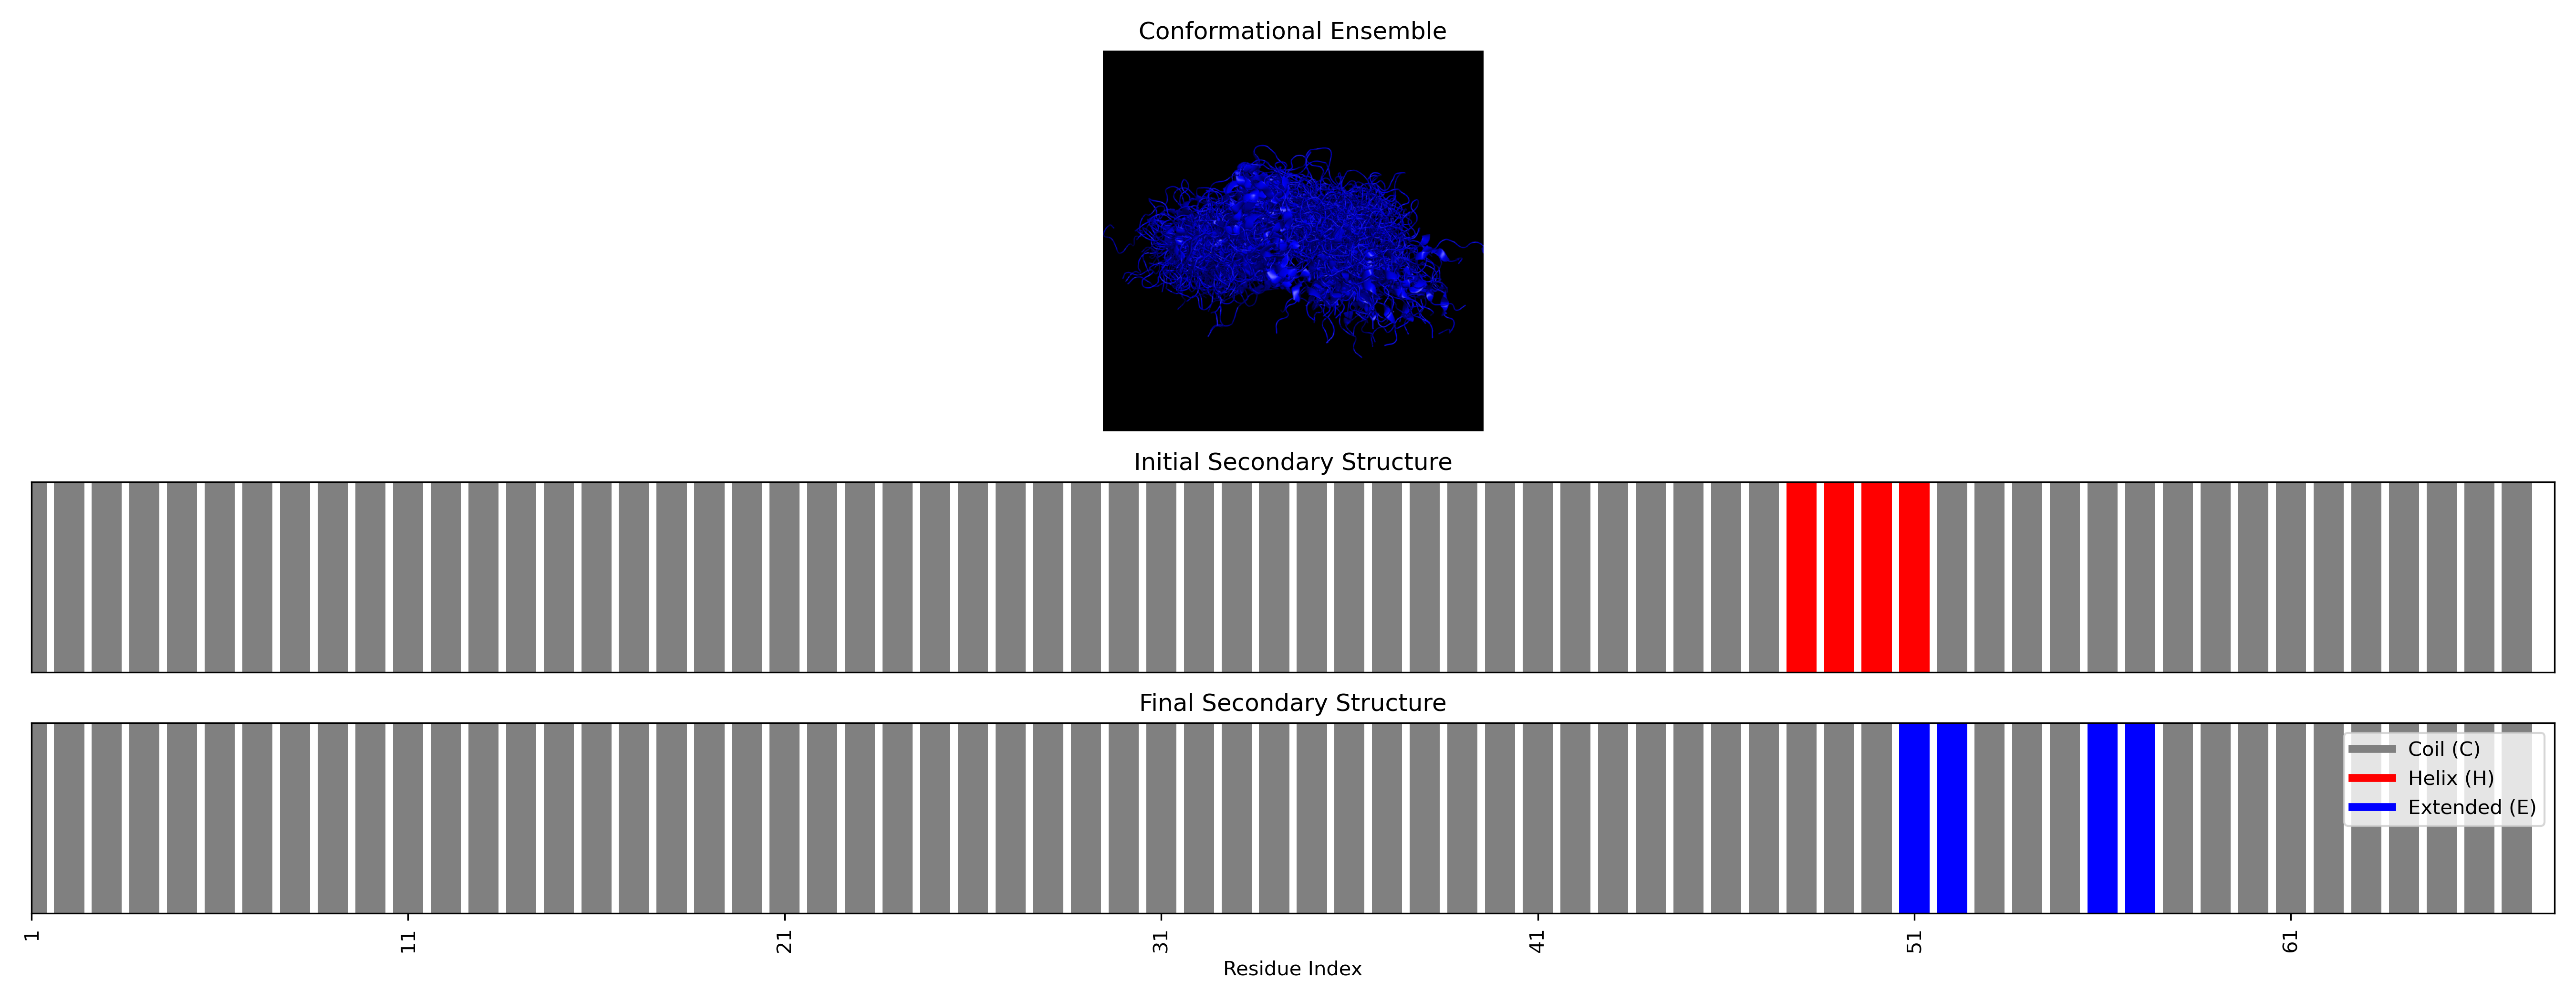

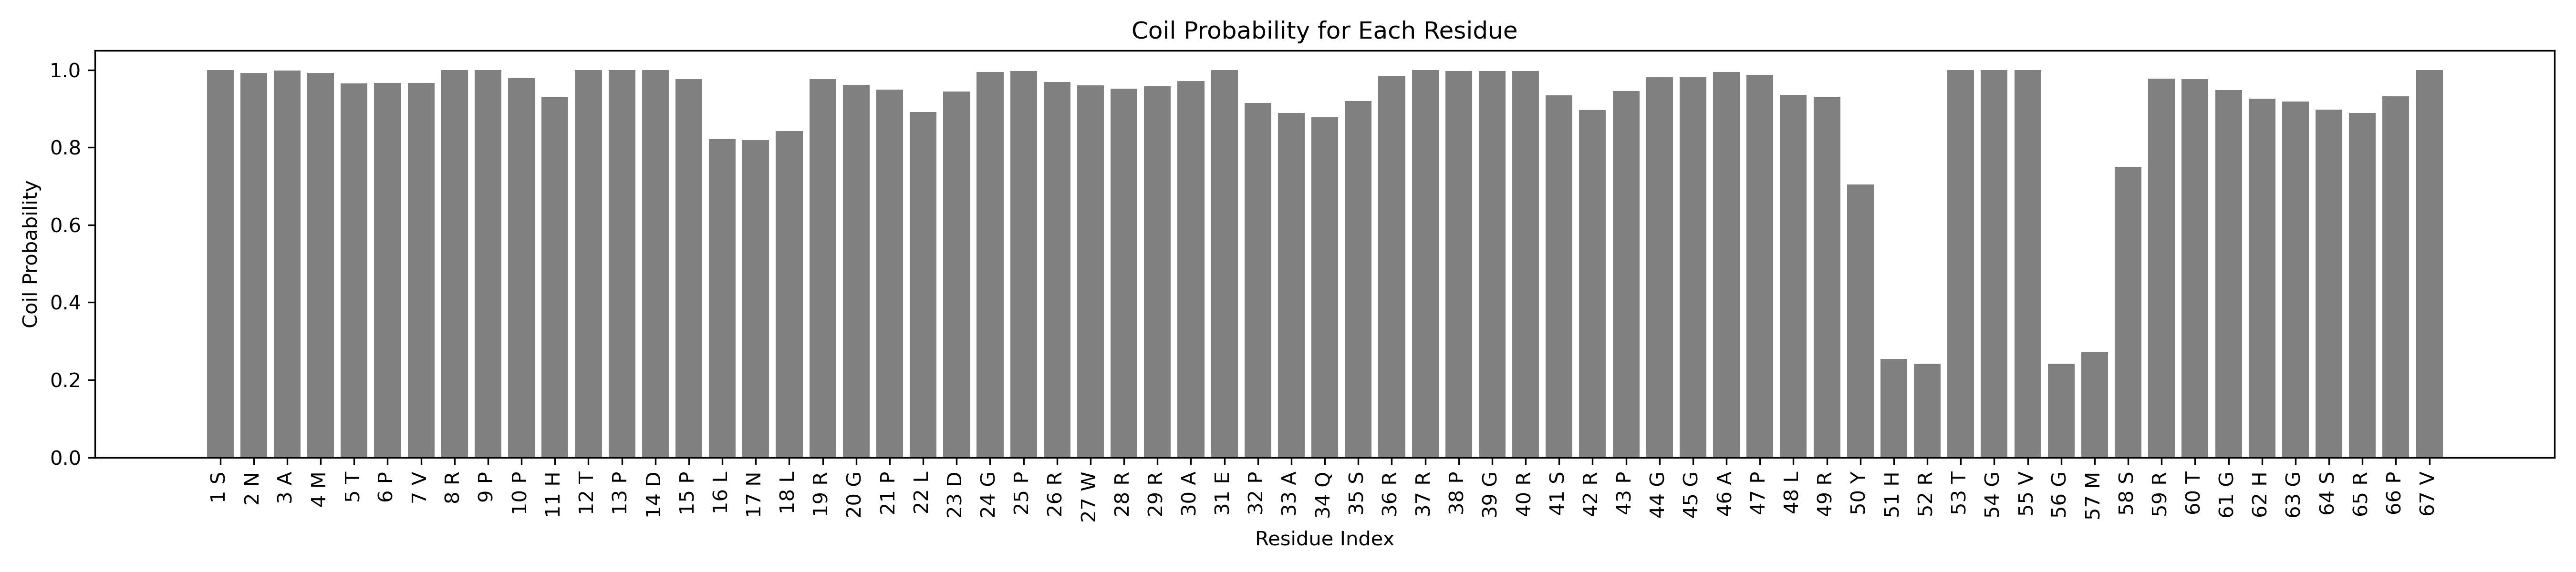

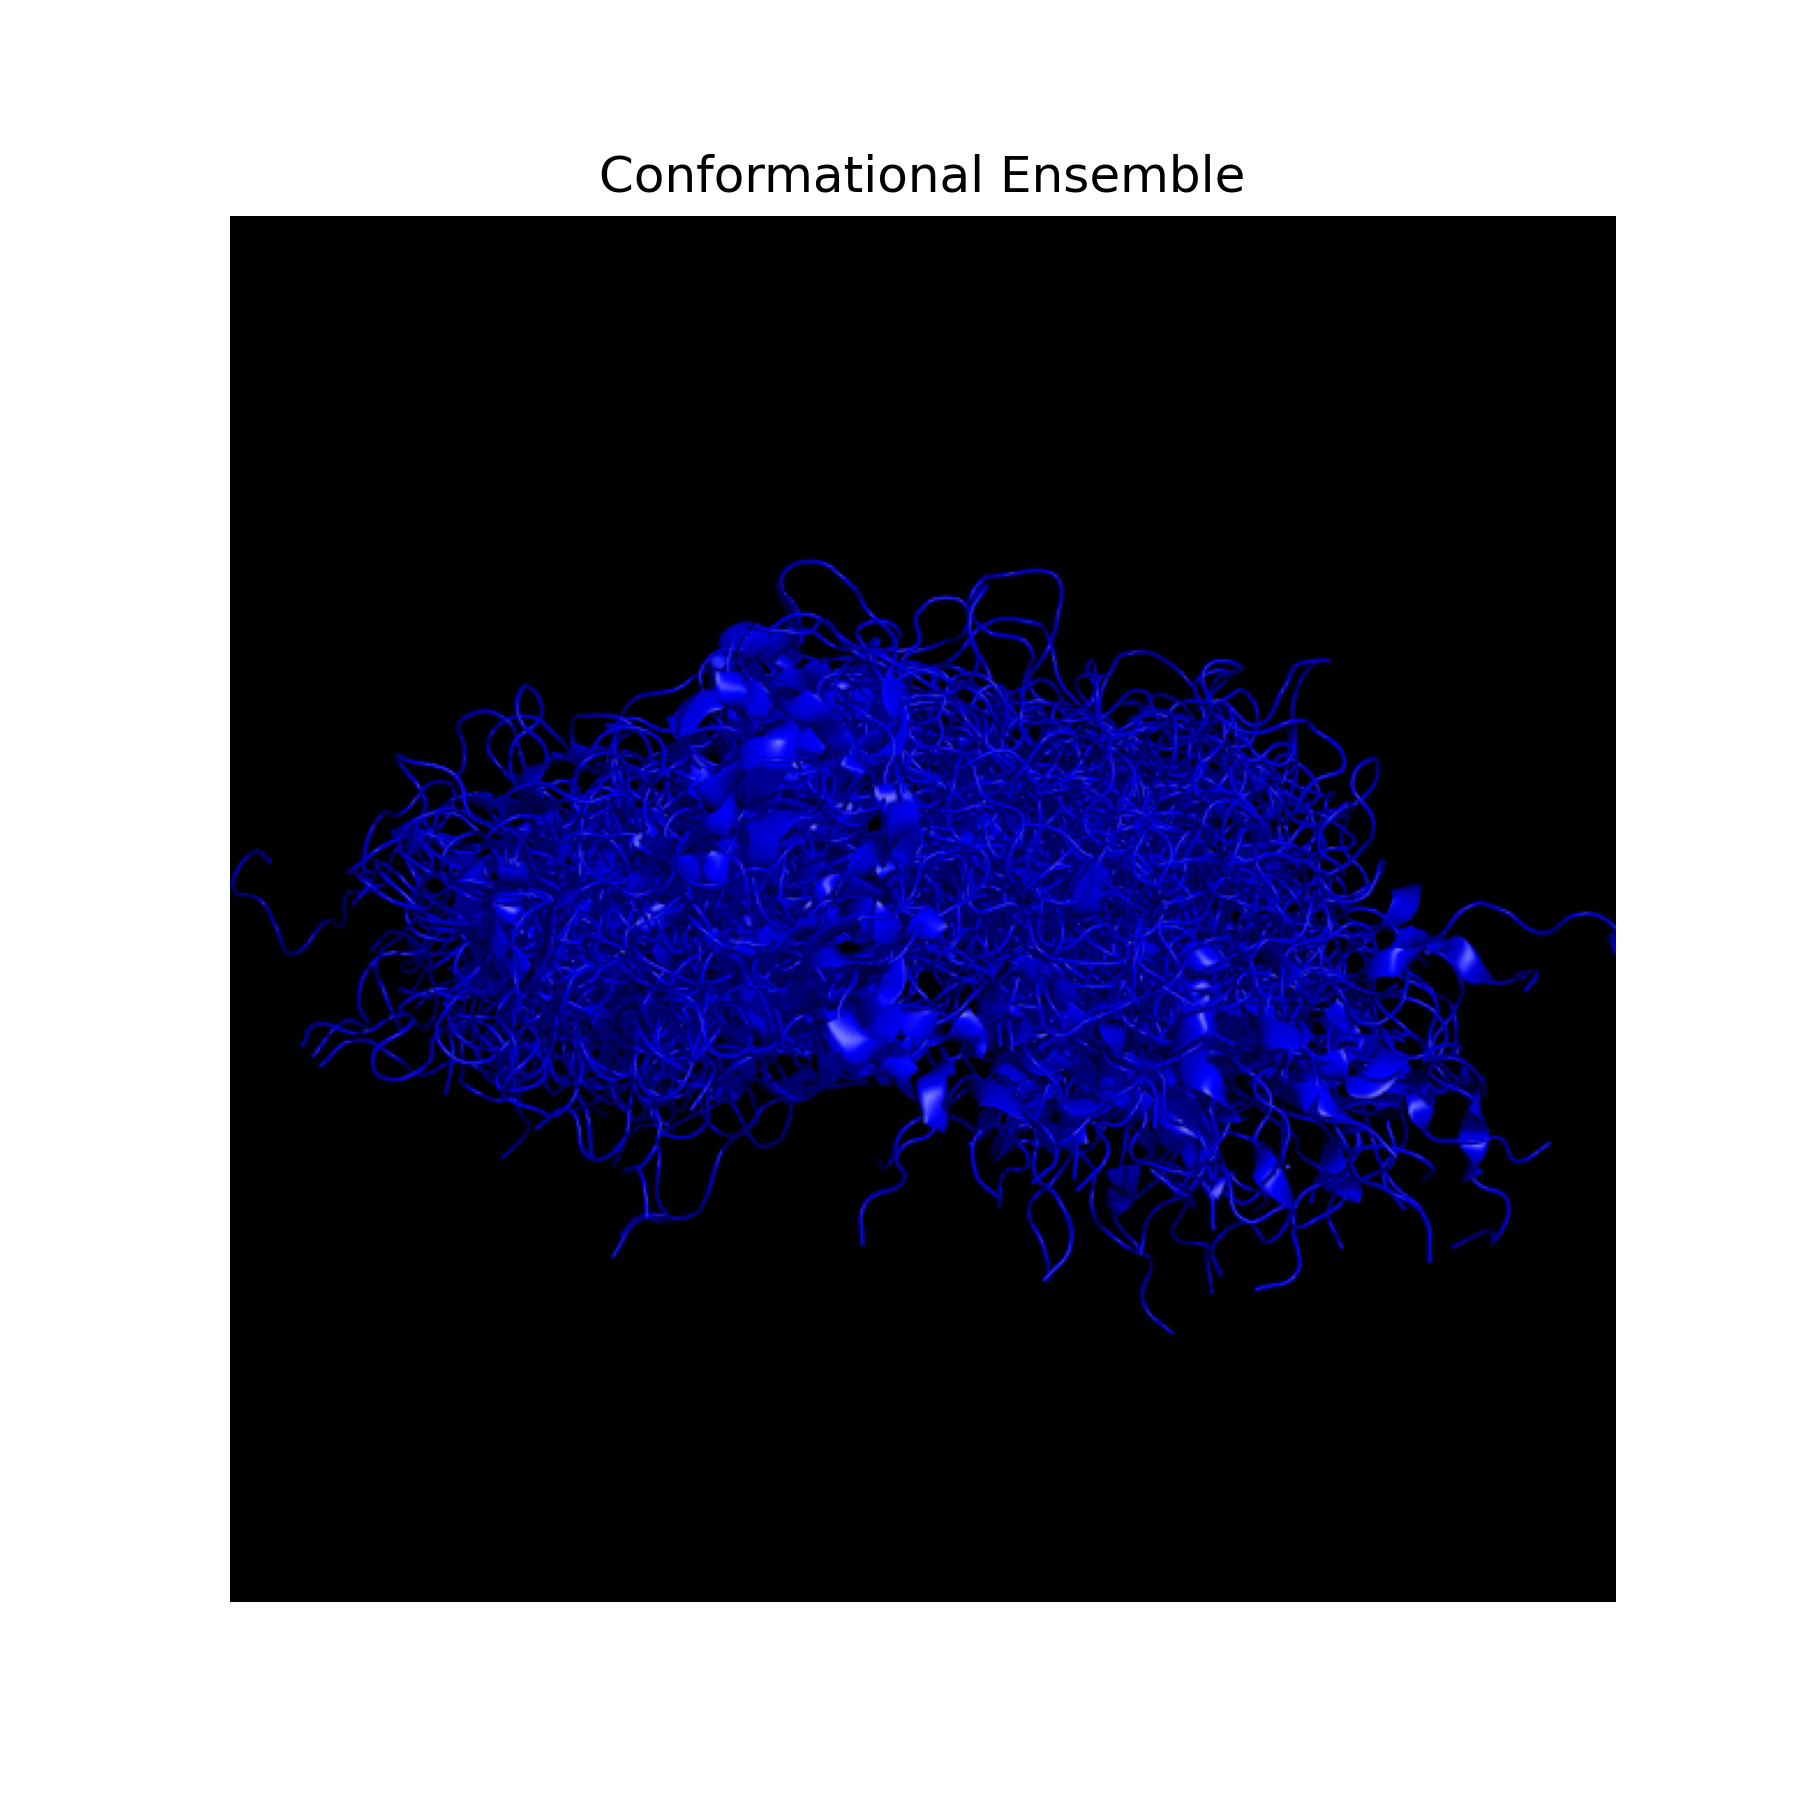

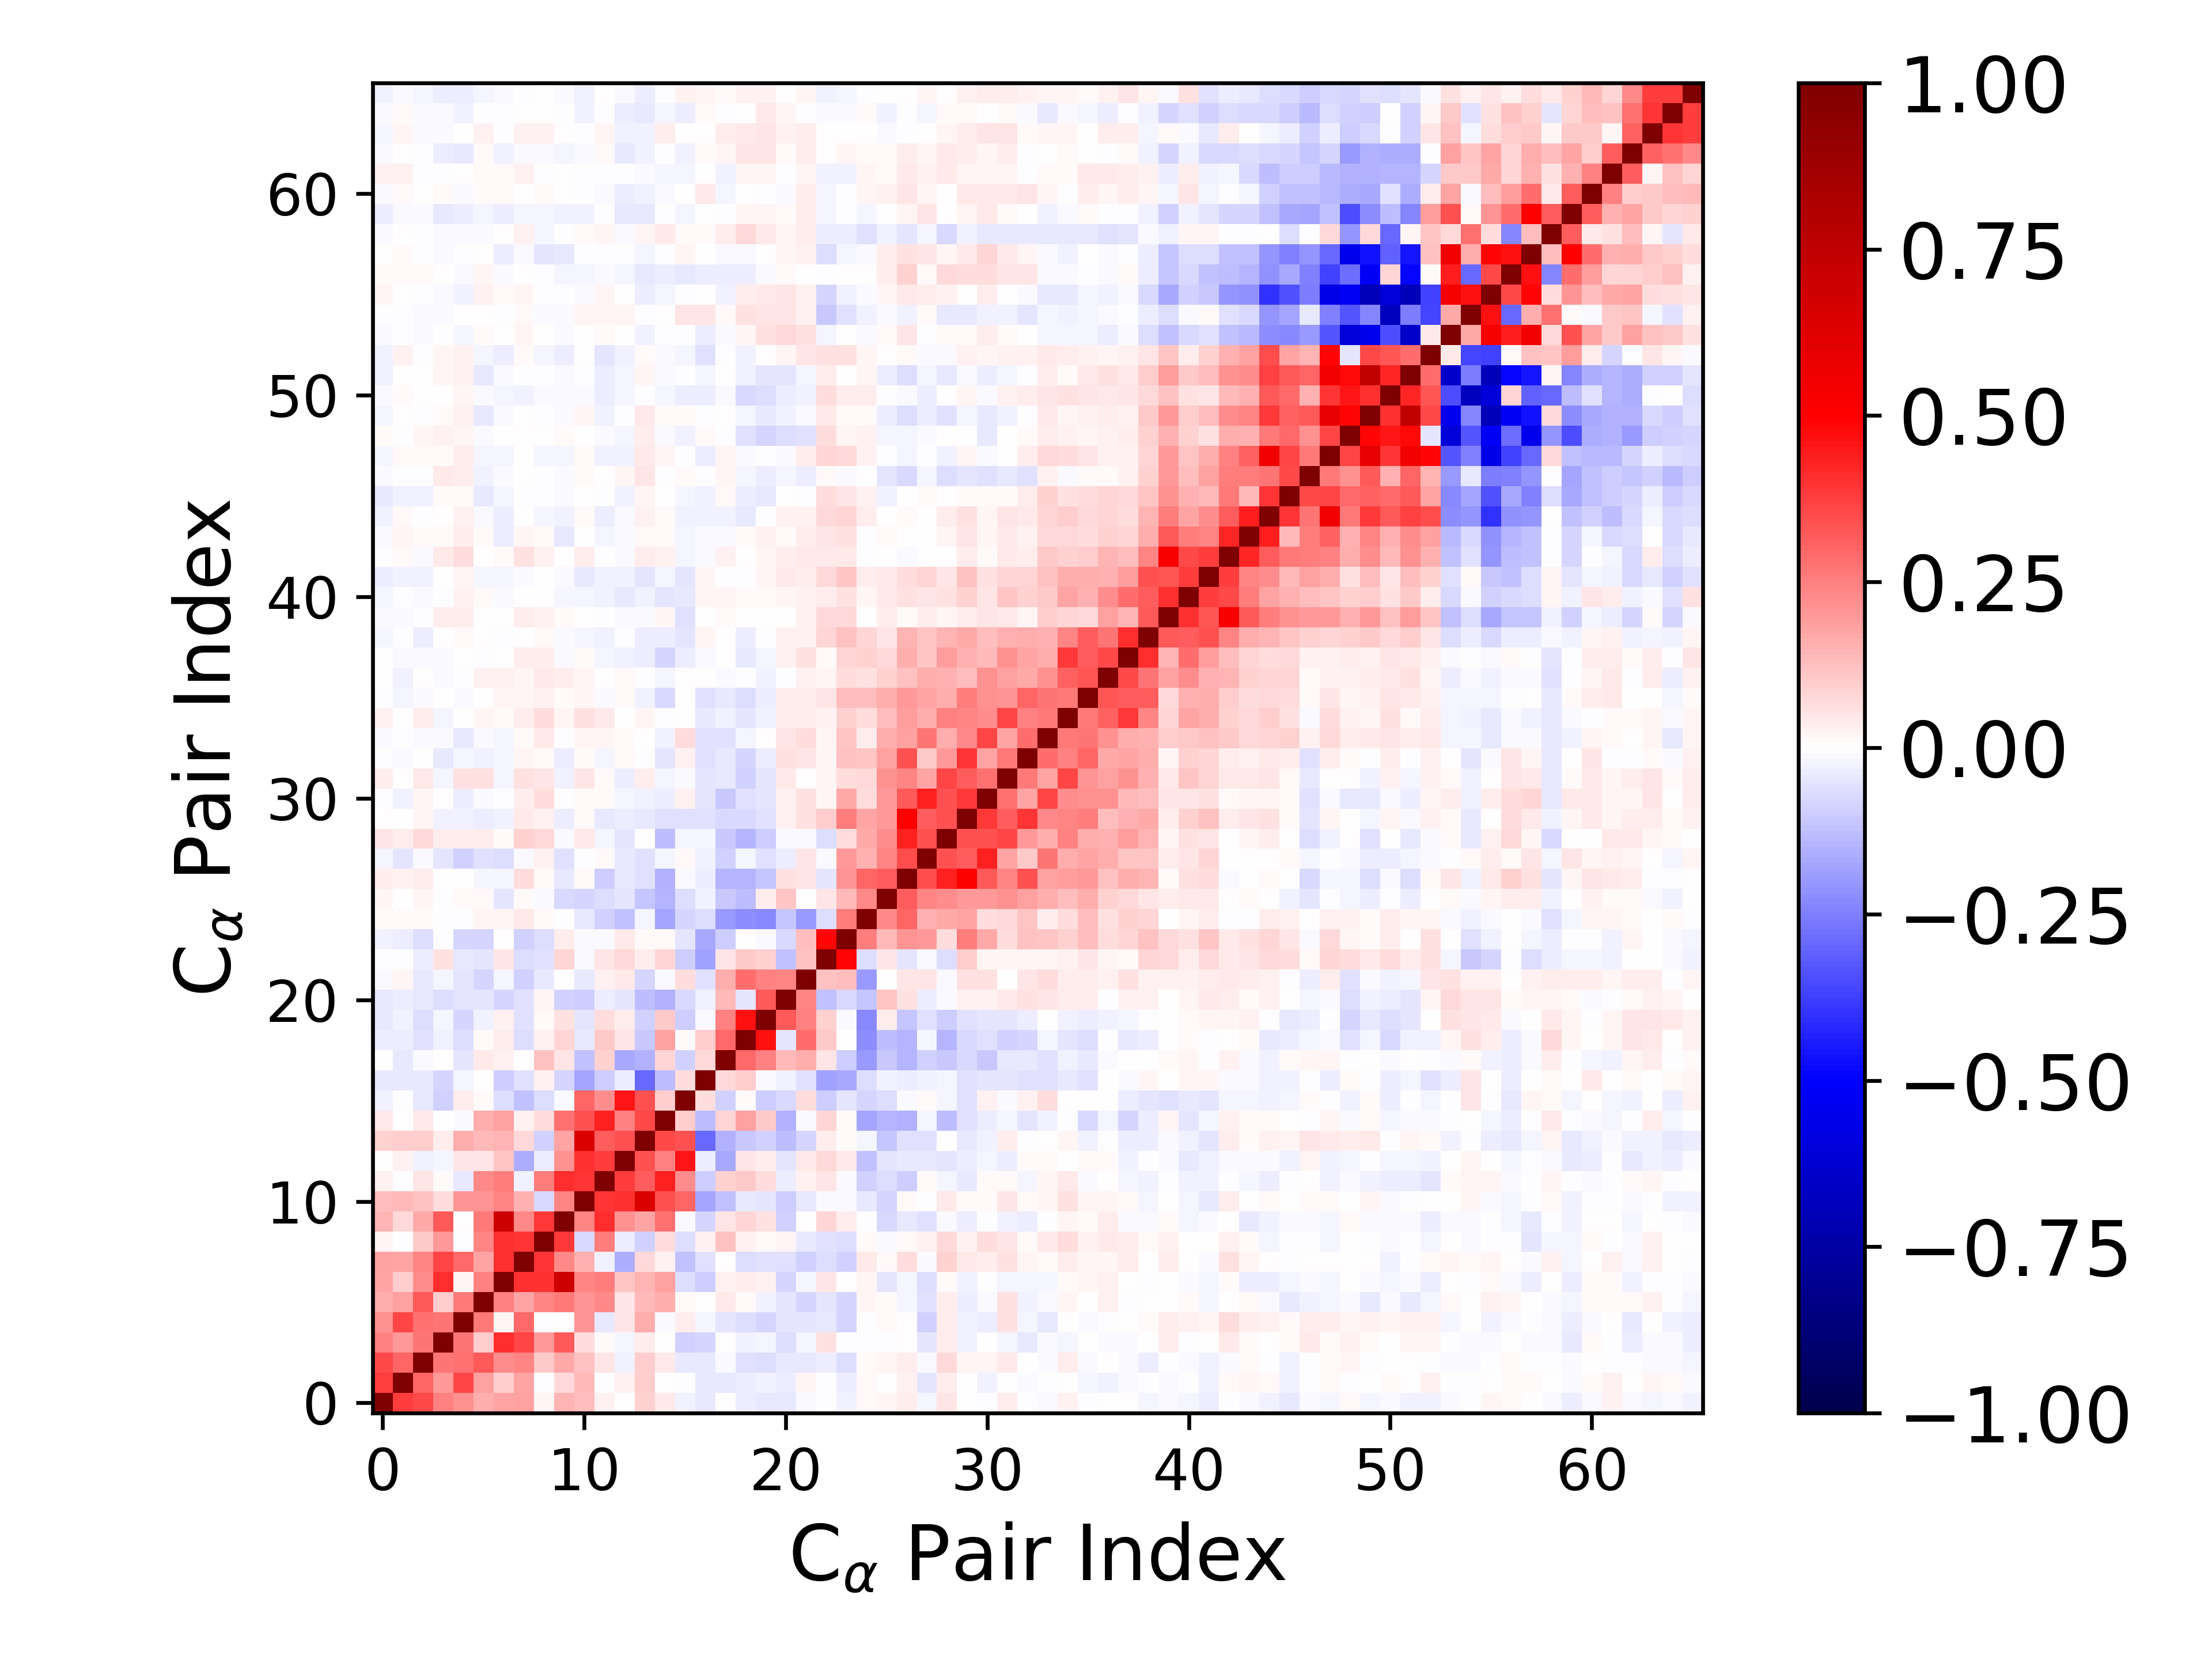

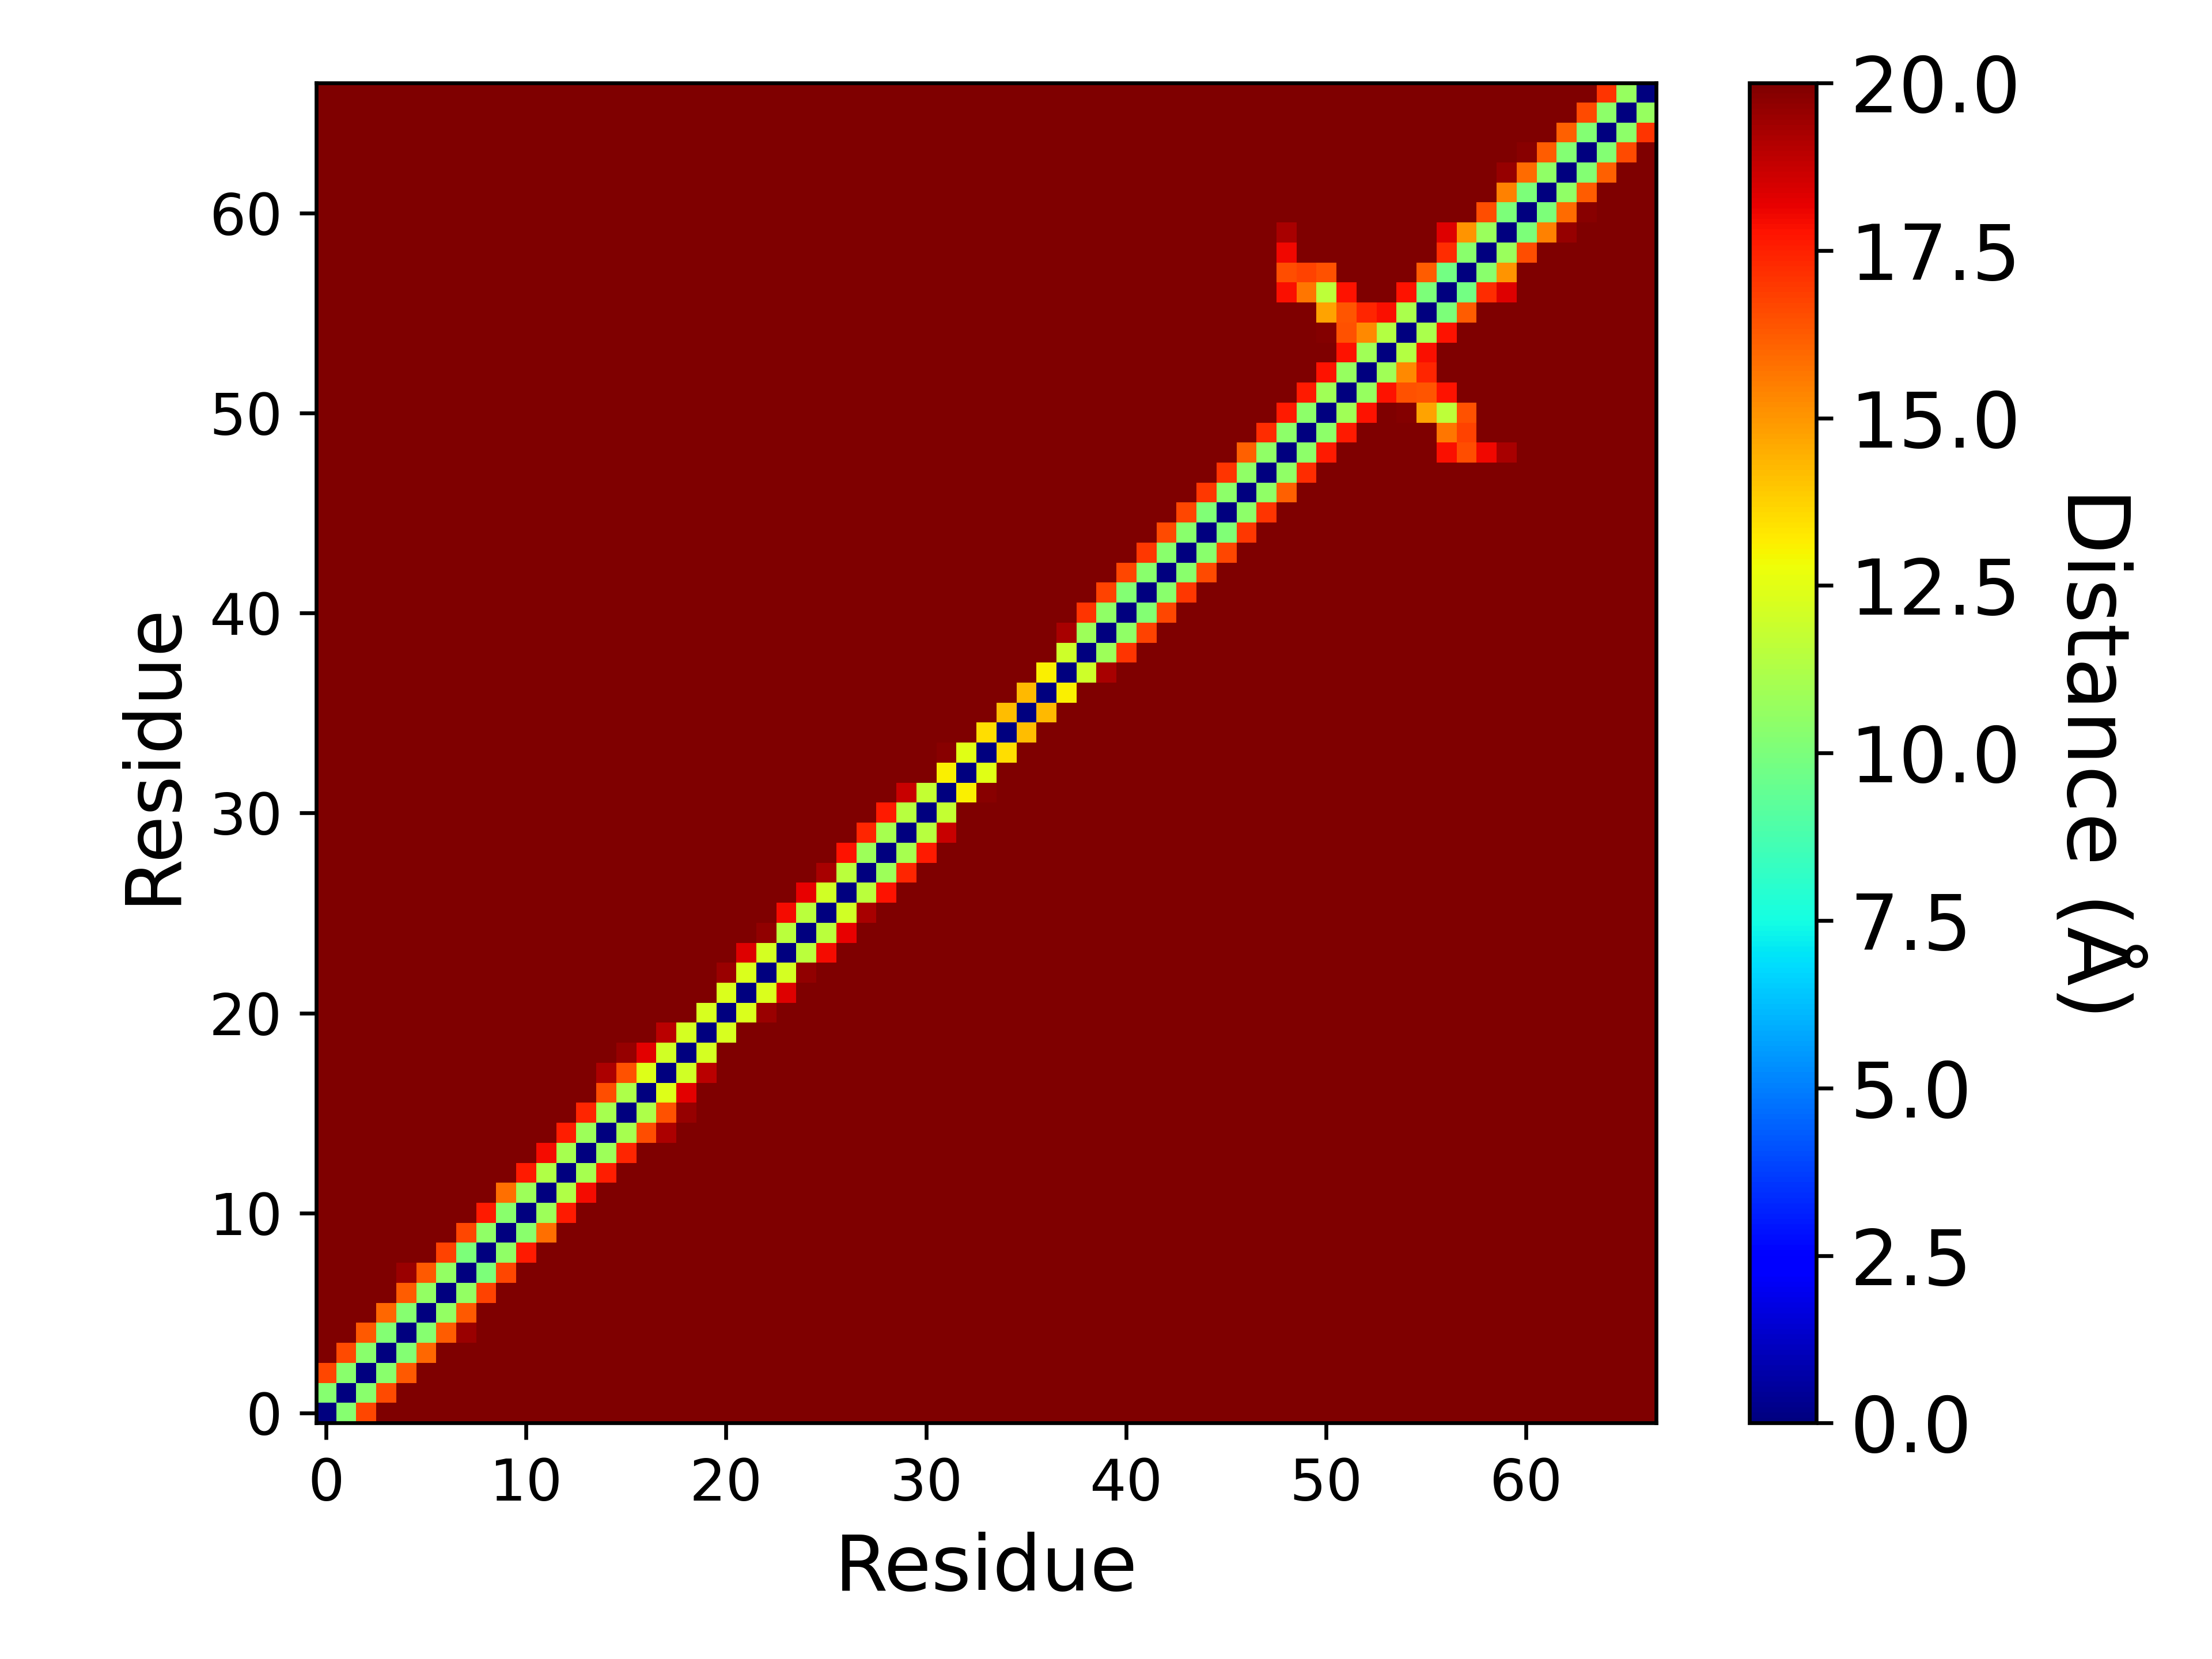

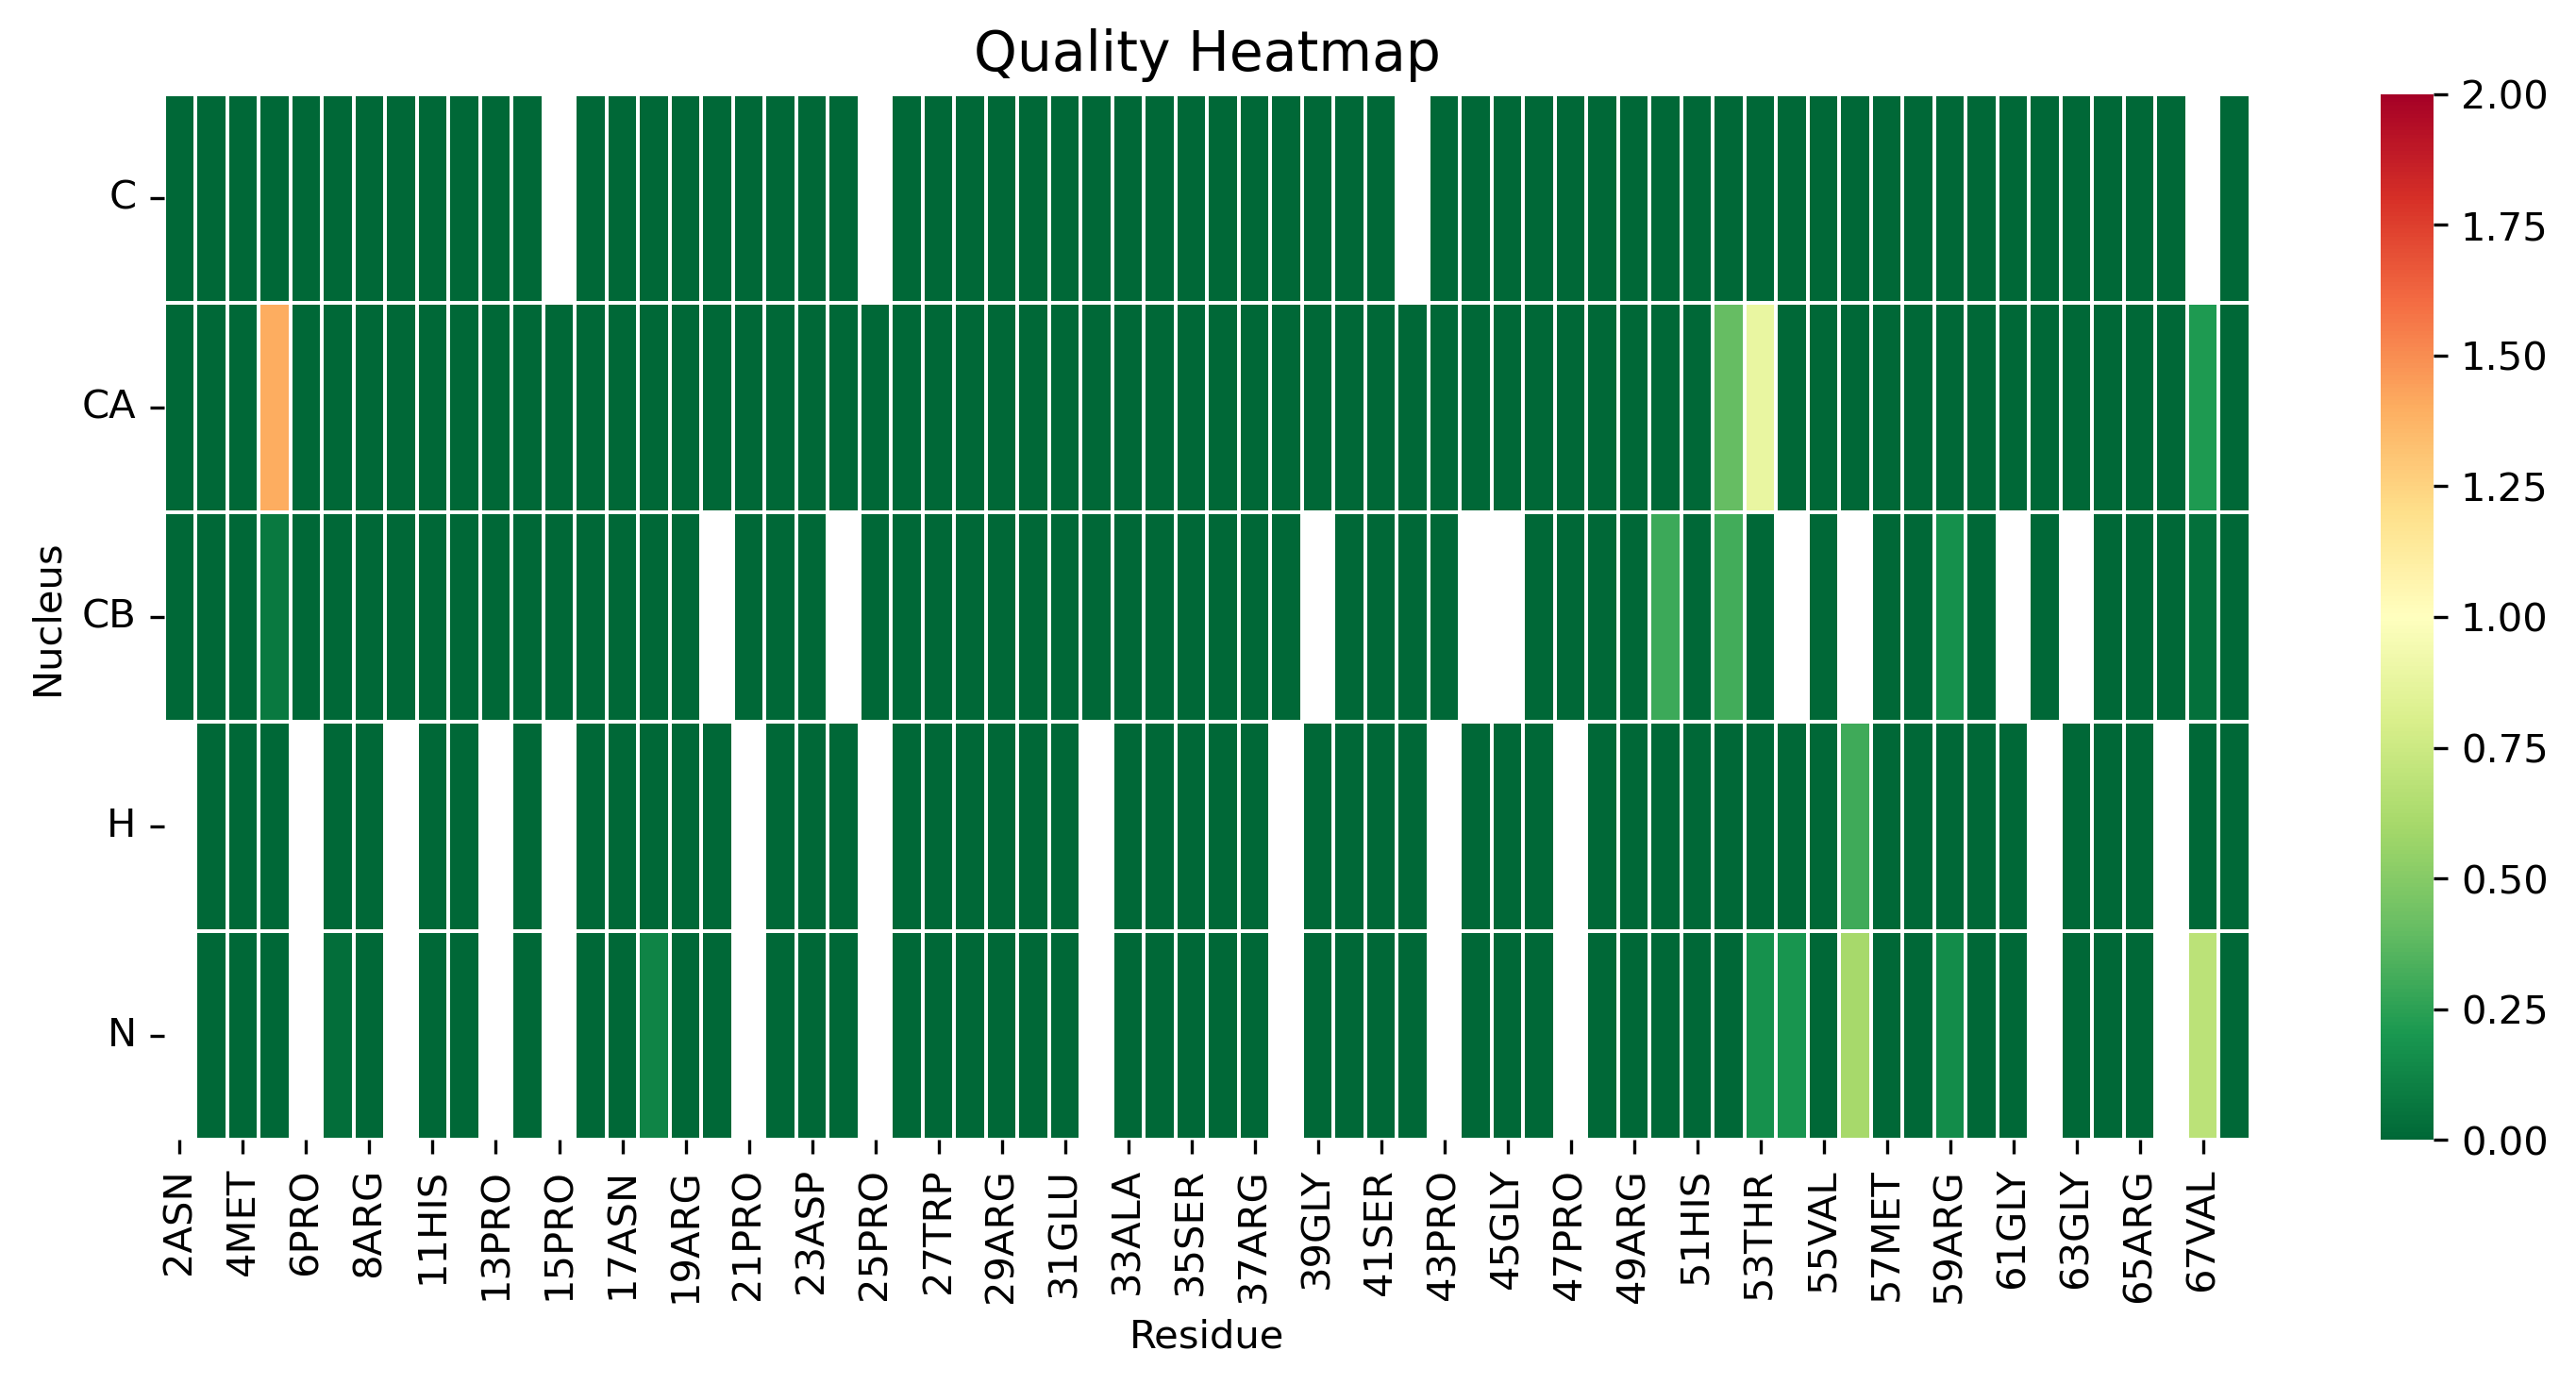

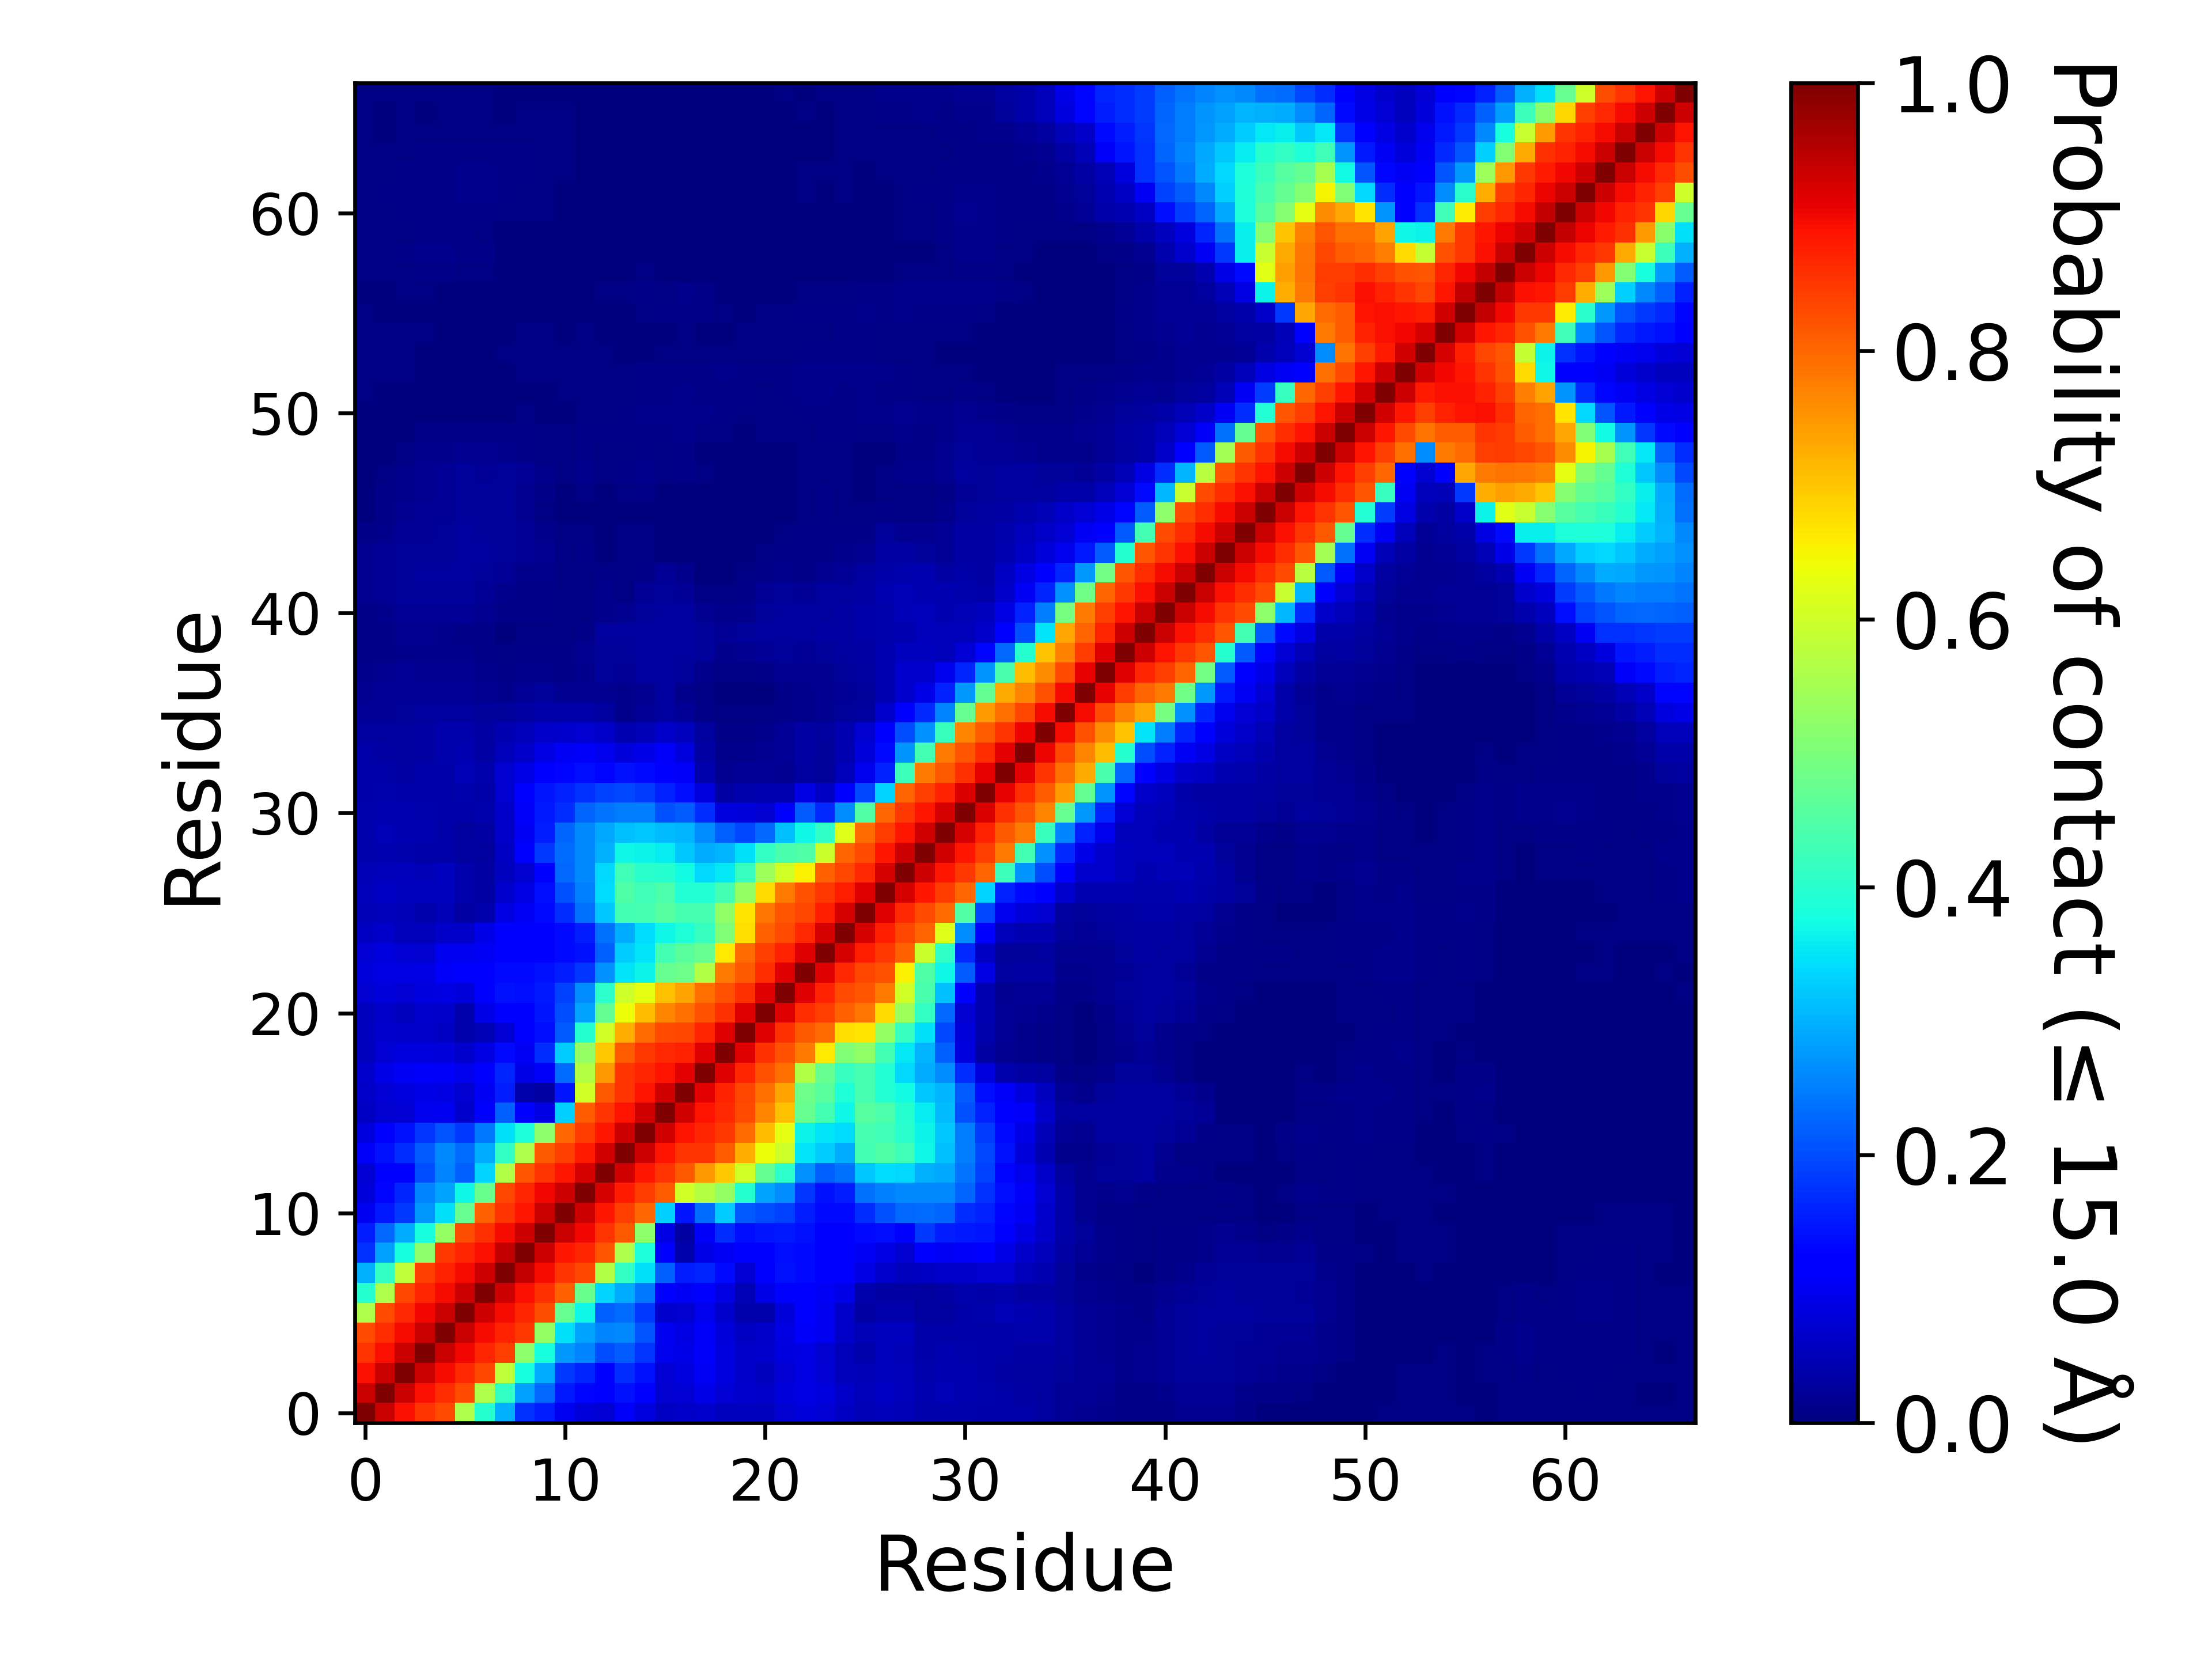

In [25]:
spin_overall = []
shift_overall = []

spin_overall_best = [0,100]
spin_overall_worst = [0,0]


for system in systems:
    dataFolder = databankPath + 'Data/Simulations/' + system['path'] + '/'

    spin_file = dataFolder + 'spin_relaxation_rmsd.yaml'
    shift_file = dataFolder + 'chemical_shift_res_quality.yaml'

    # Load spin relaxation overall percentage
    try:
        with open(spin_file, 'r') as f:
            spin_data = yaml.safe_load(f)
        total_rmsd = spin_data['R1'] + spin_data['R2'] + spin_data['hetNOE'] 
        spin_overall_value = total_rmsd
        spin_overall.append(spin_overall_value)
        if spin_overall_value < spin_overall_best[1]:
            #print(system, spin_overall_best)
            spin_overall_best = [system['path'],spin_overall_value]
        if spin_overall_value > spin_overall_worst[1]:
            #print(system, spin_overall_best)
            spin_overall_worst = [system['path'],spin_overall_value]
            #print(spin_overall_best)
    except FileNotFoundError:
        #print(f"Warning: {spin_file} not found")
        pass

    # Load chemical shift overall percentage
    try:
        with open(shift_file, 'r') as f:
            shift_data = yaml.safe_load(f)
        if 'overall_non_zero_percentage' in shift_data:
            shift_overall.append(shift_data['overall_non_zero_percentage'])
    except FileNotFoundError:
        #print(f"Warning: {shift_file} not found")
        pass

        
import os
from IPython.display import display, Image

folder = "../../Data/Simulations/" + spin_overall_best[0]
print(folder)

for file in os.listdir(folder):
    if file.endswith(".png"):
        display(Image(filename=os.path.join(folder, file)))

# Worst protein simulation based on non-zero percentages

../../Data/Simulations/79e/689/79e689f8e01714092ac51e3ee4aab8c6bb71b747/8a6537a6cc6526029a43ffbe114db00973369359/


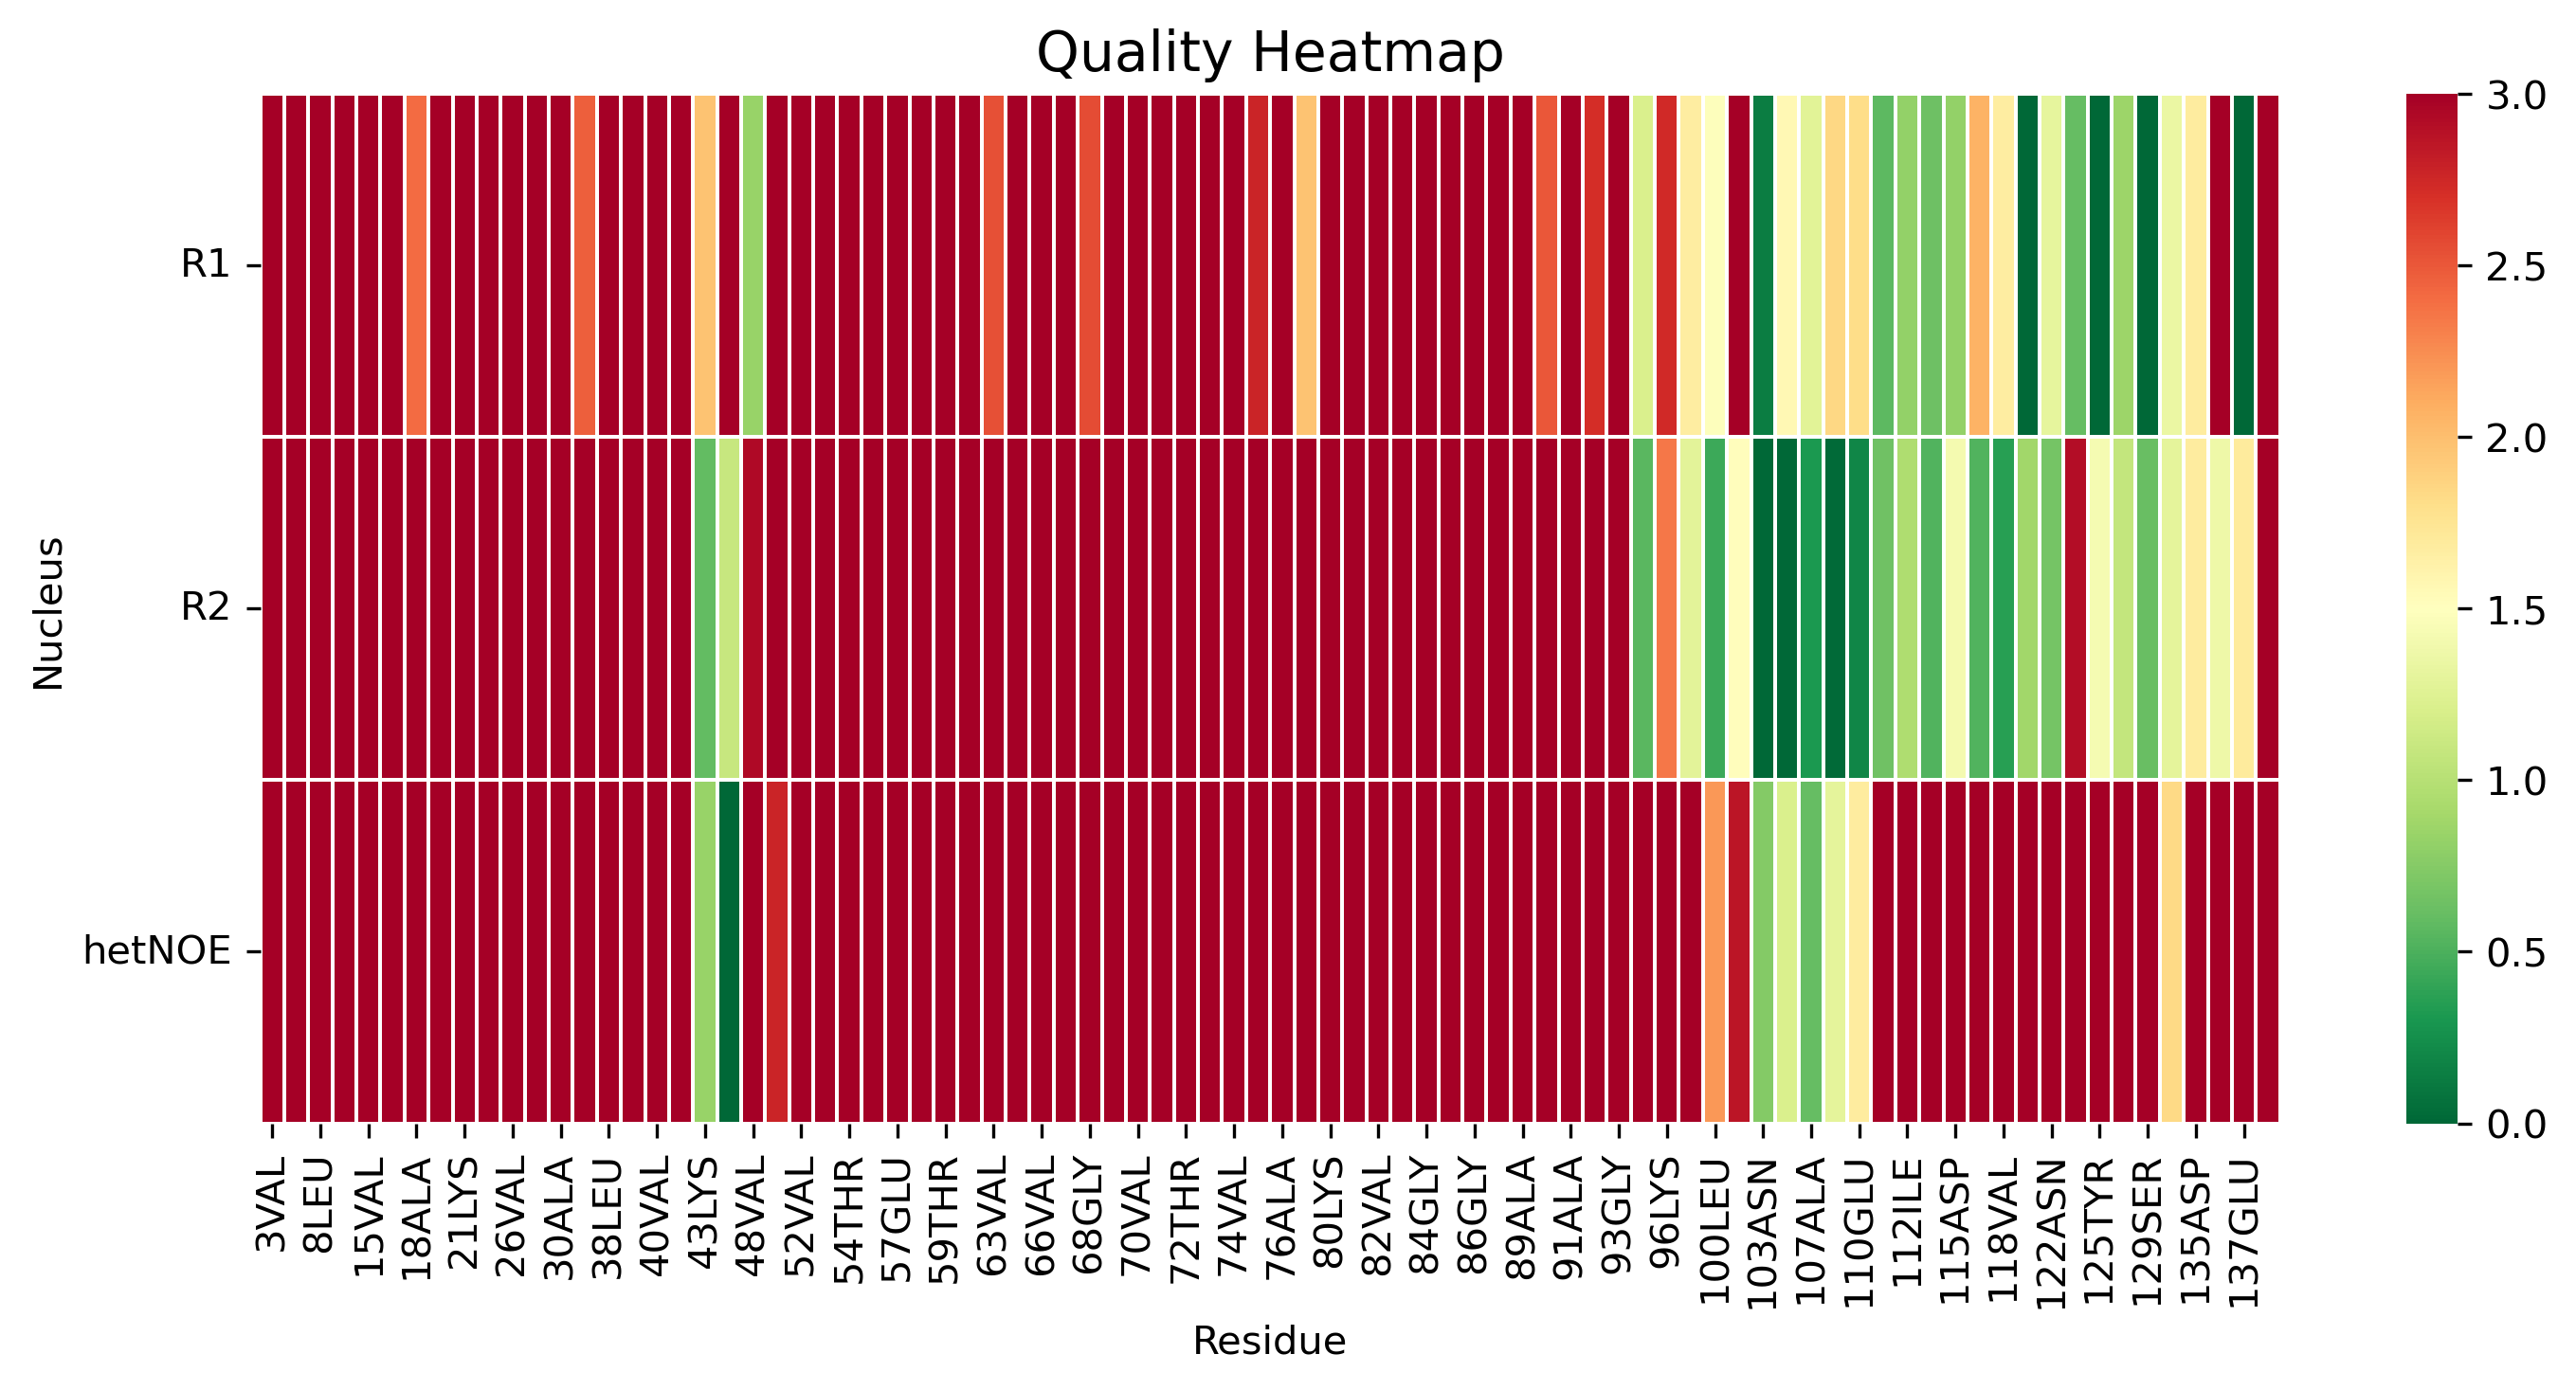

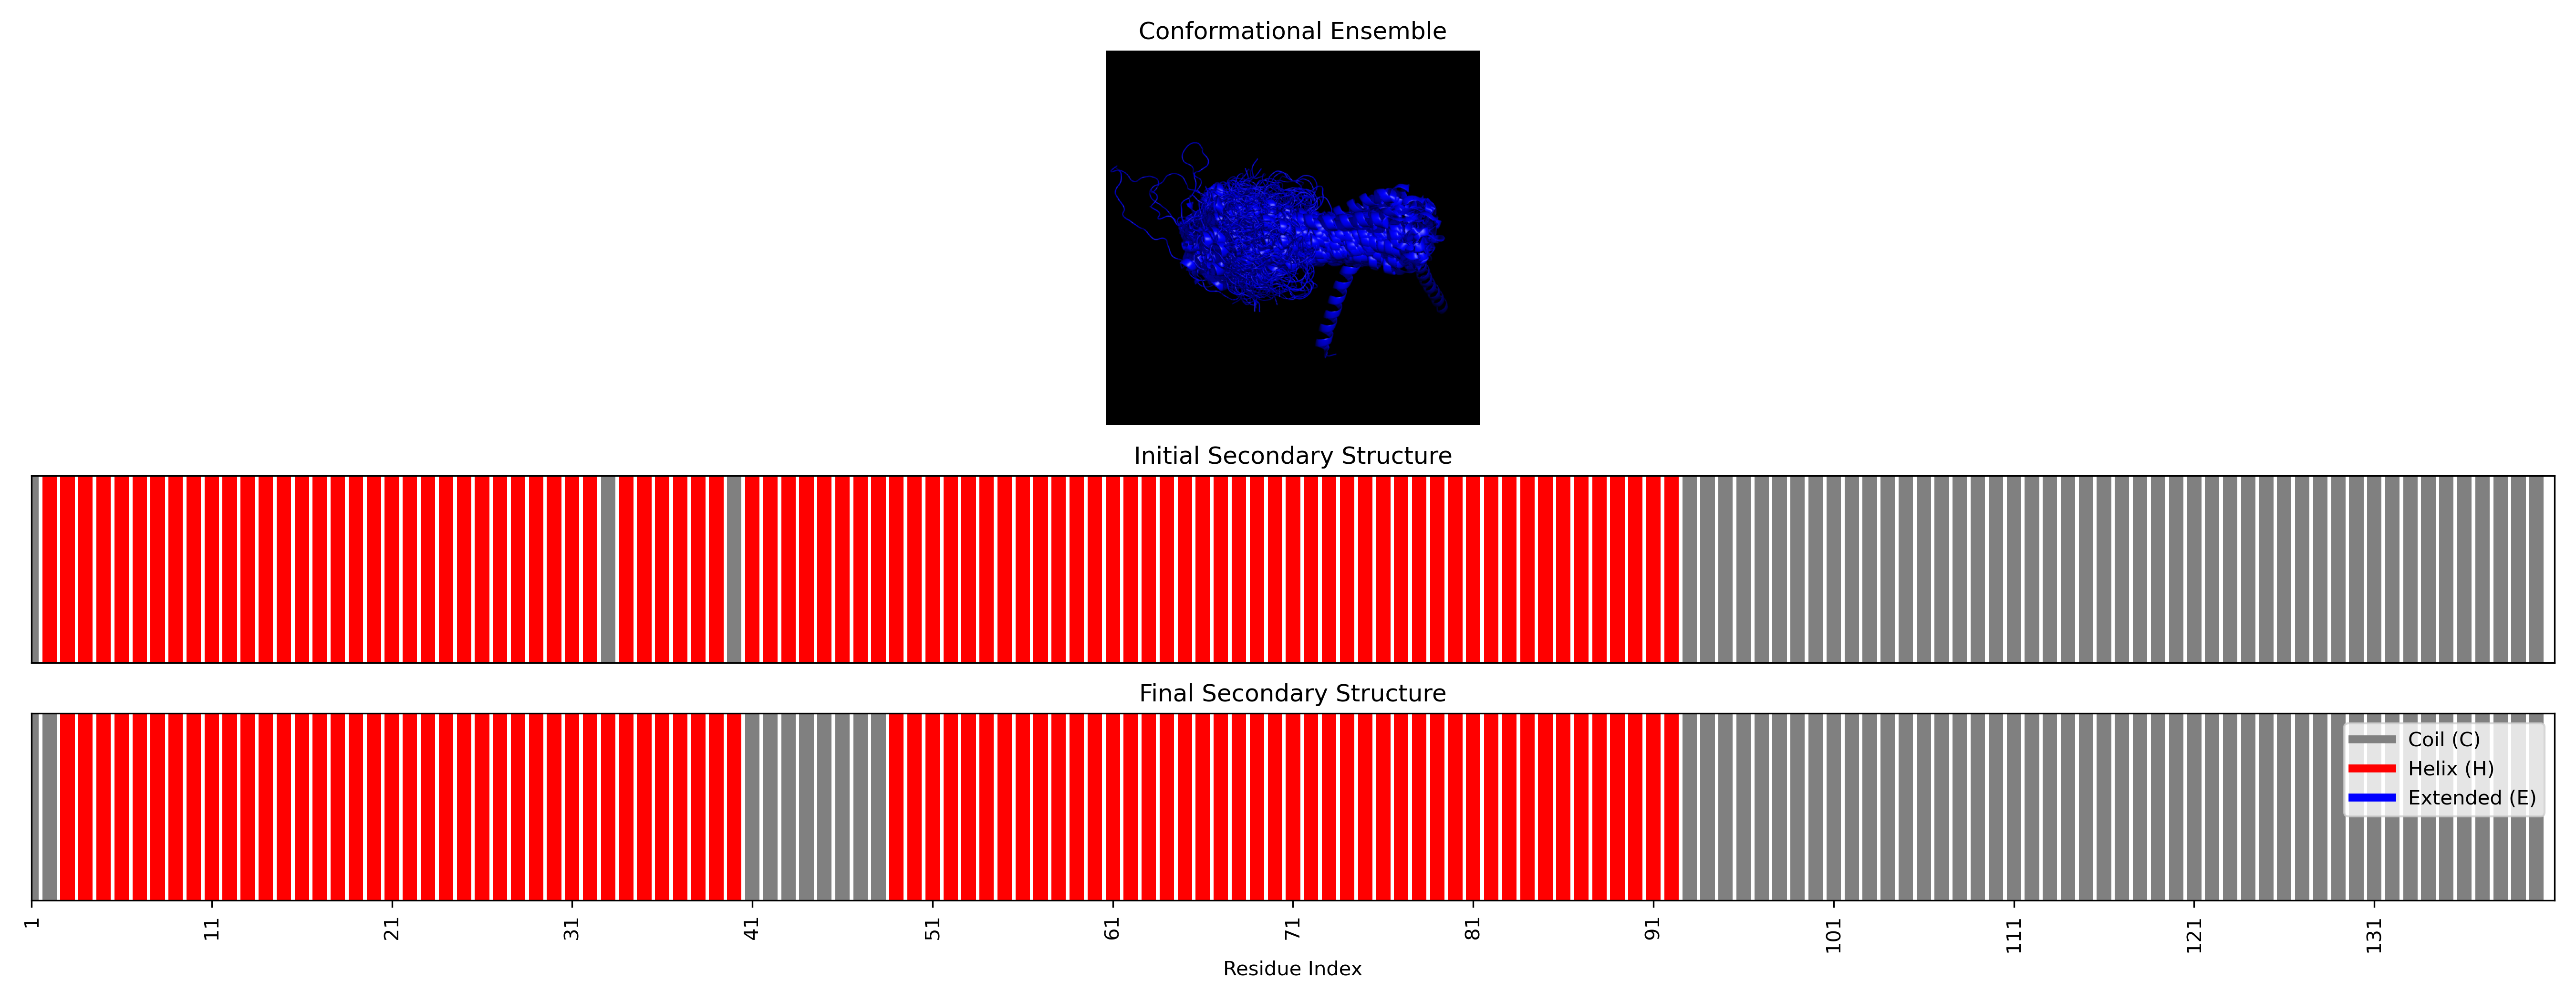

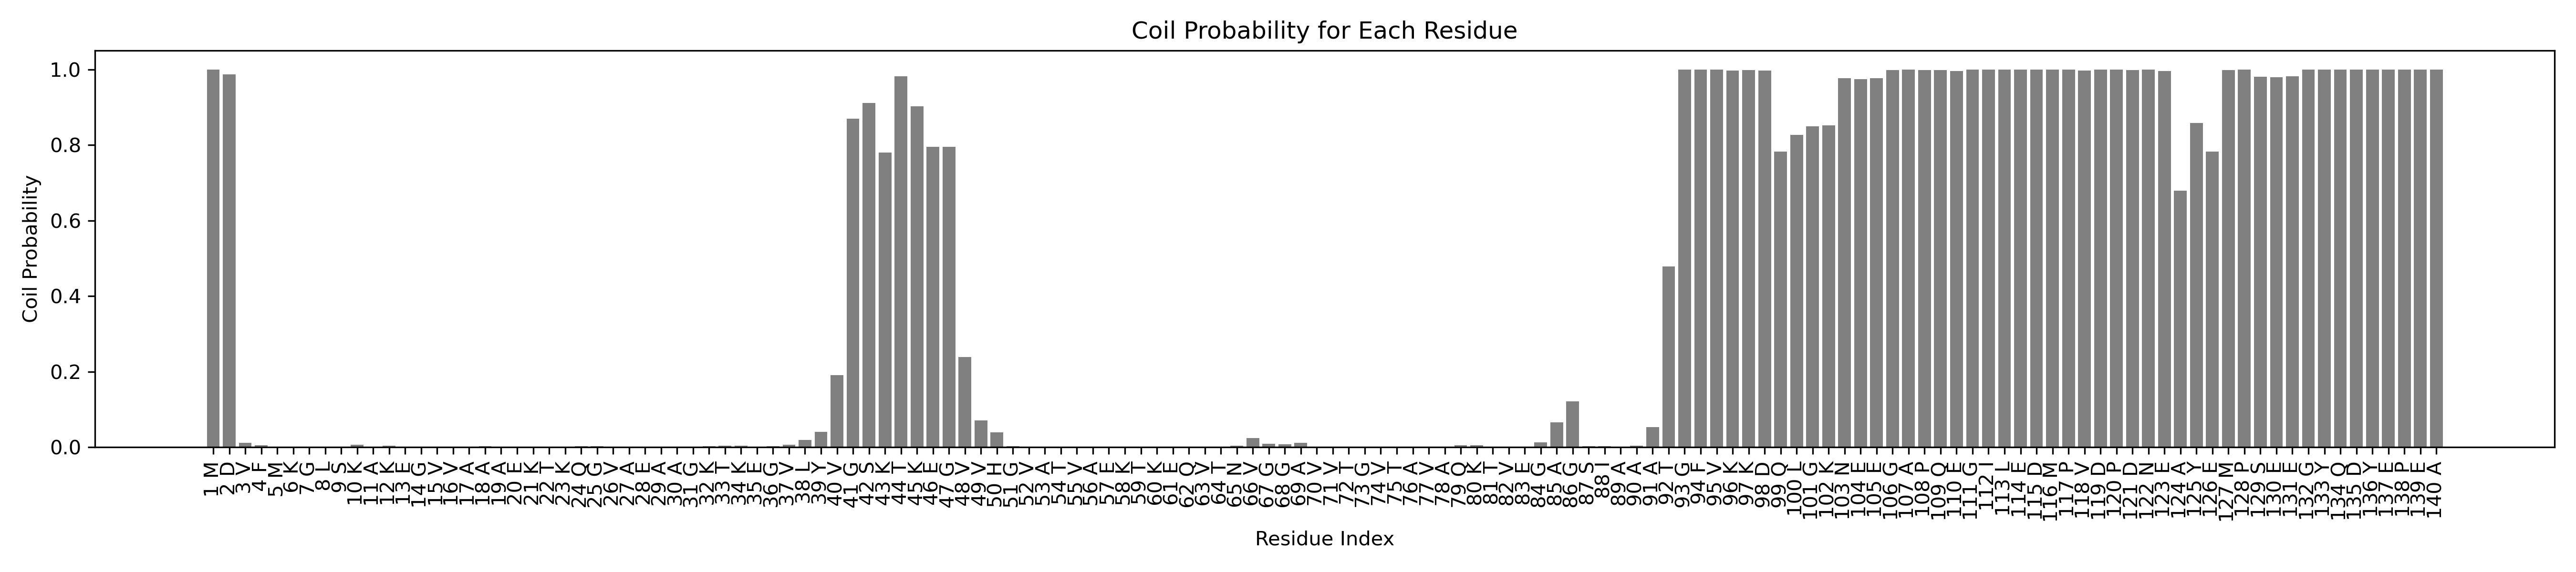

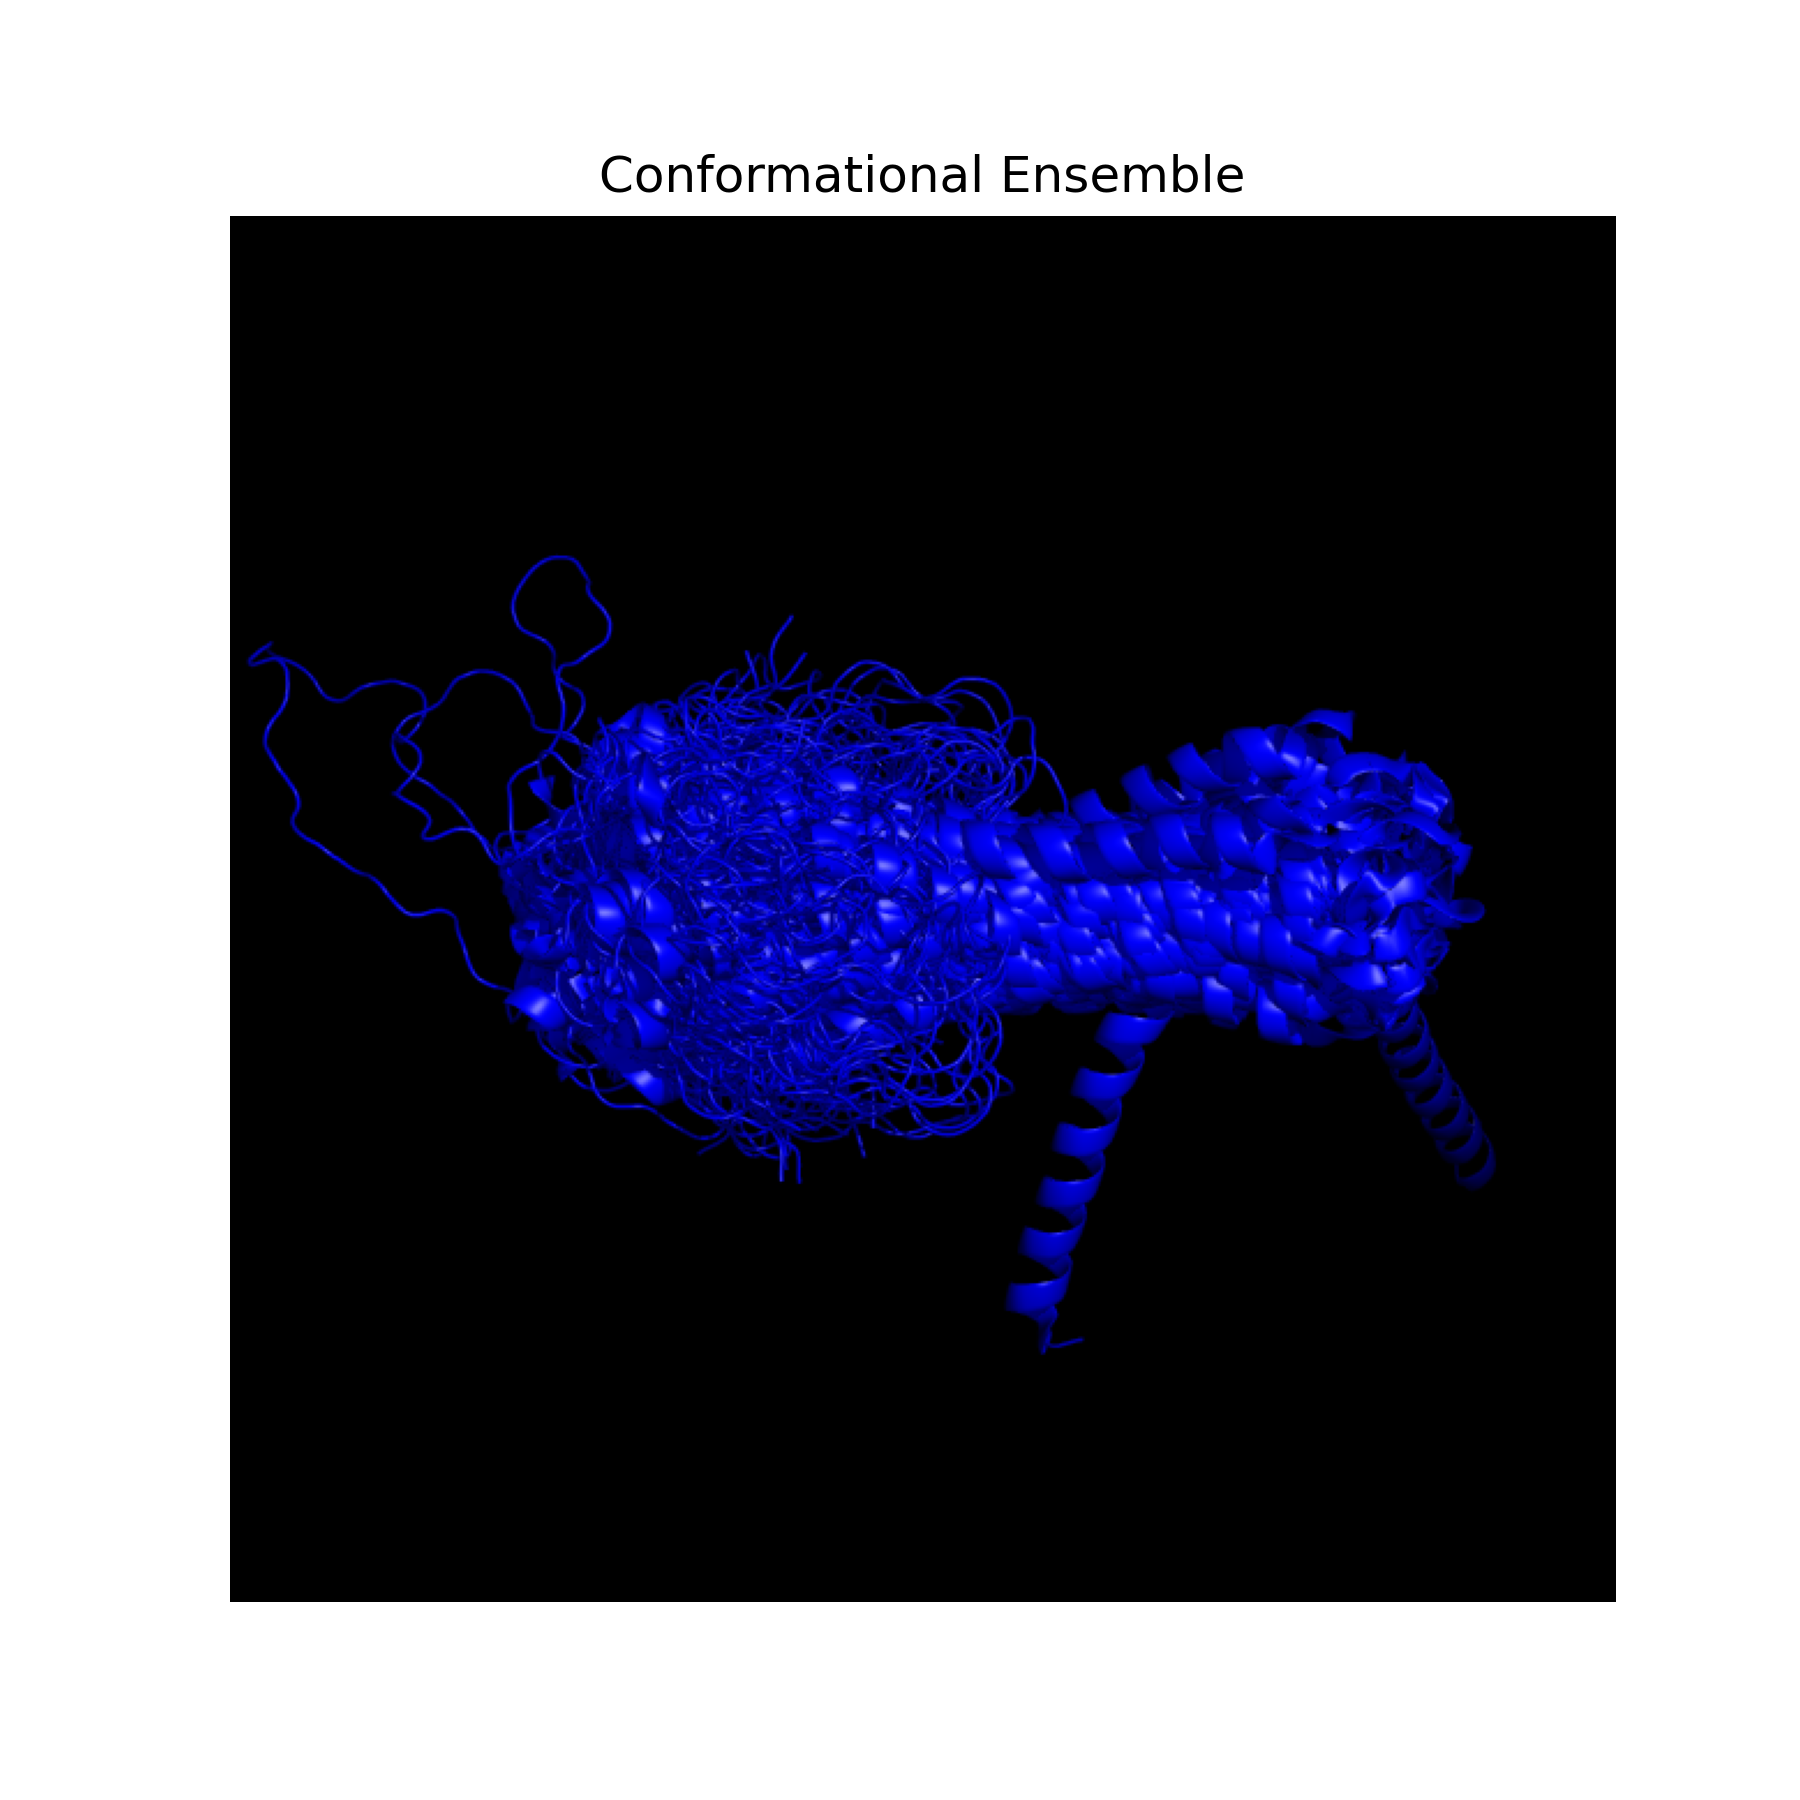

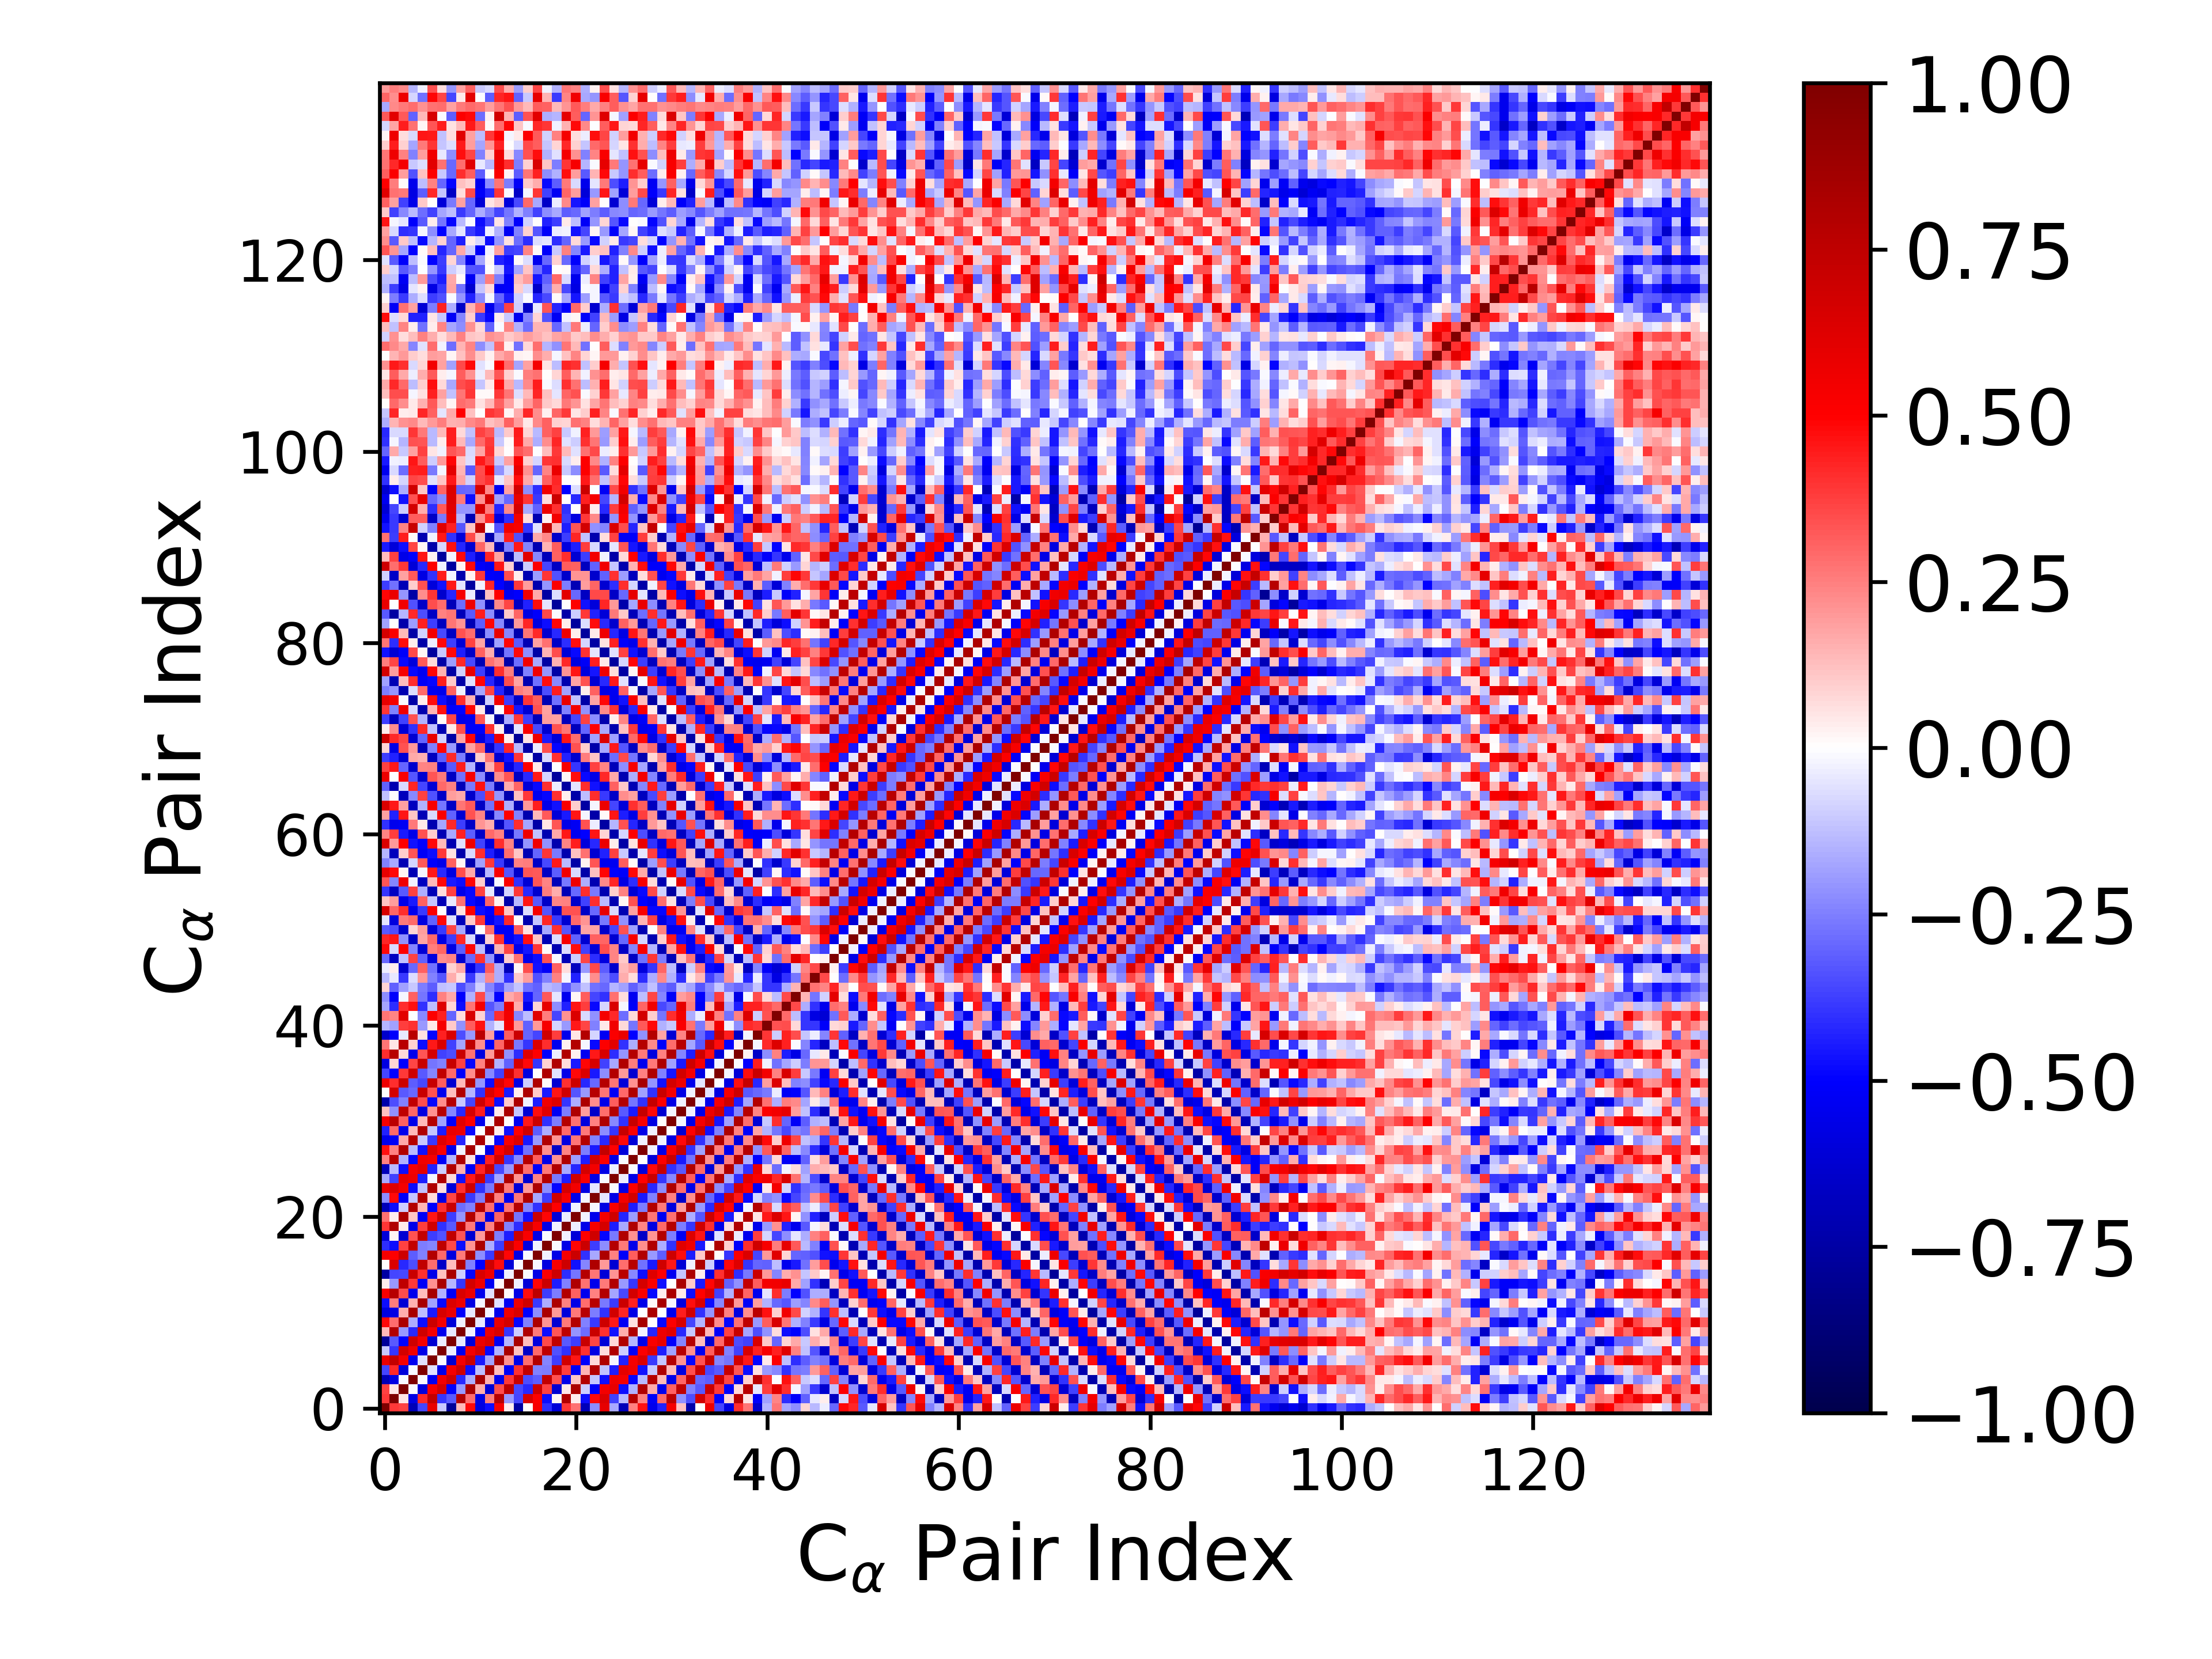

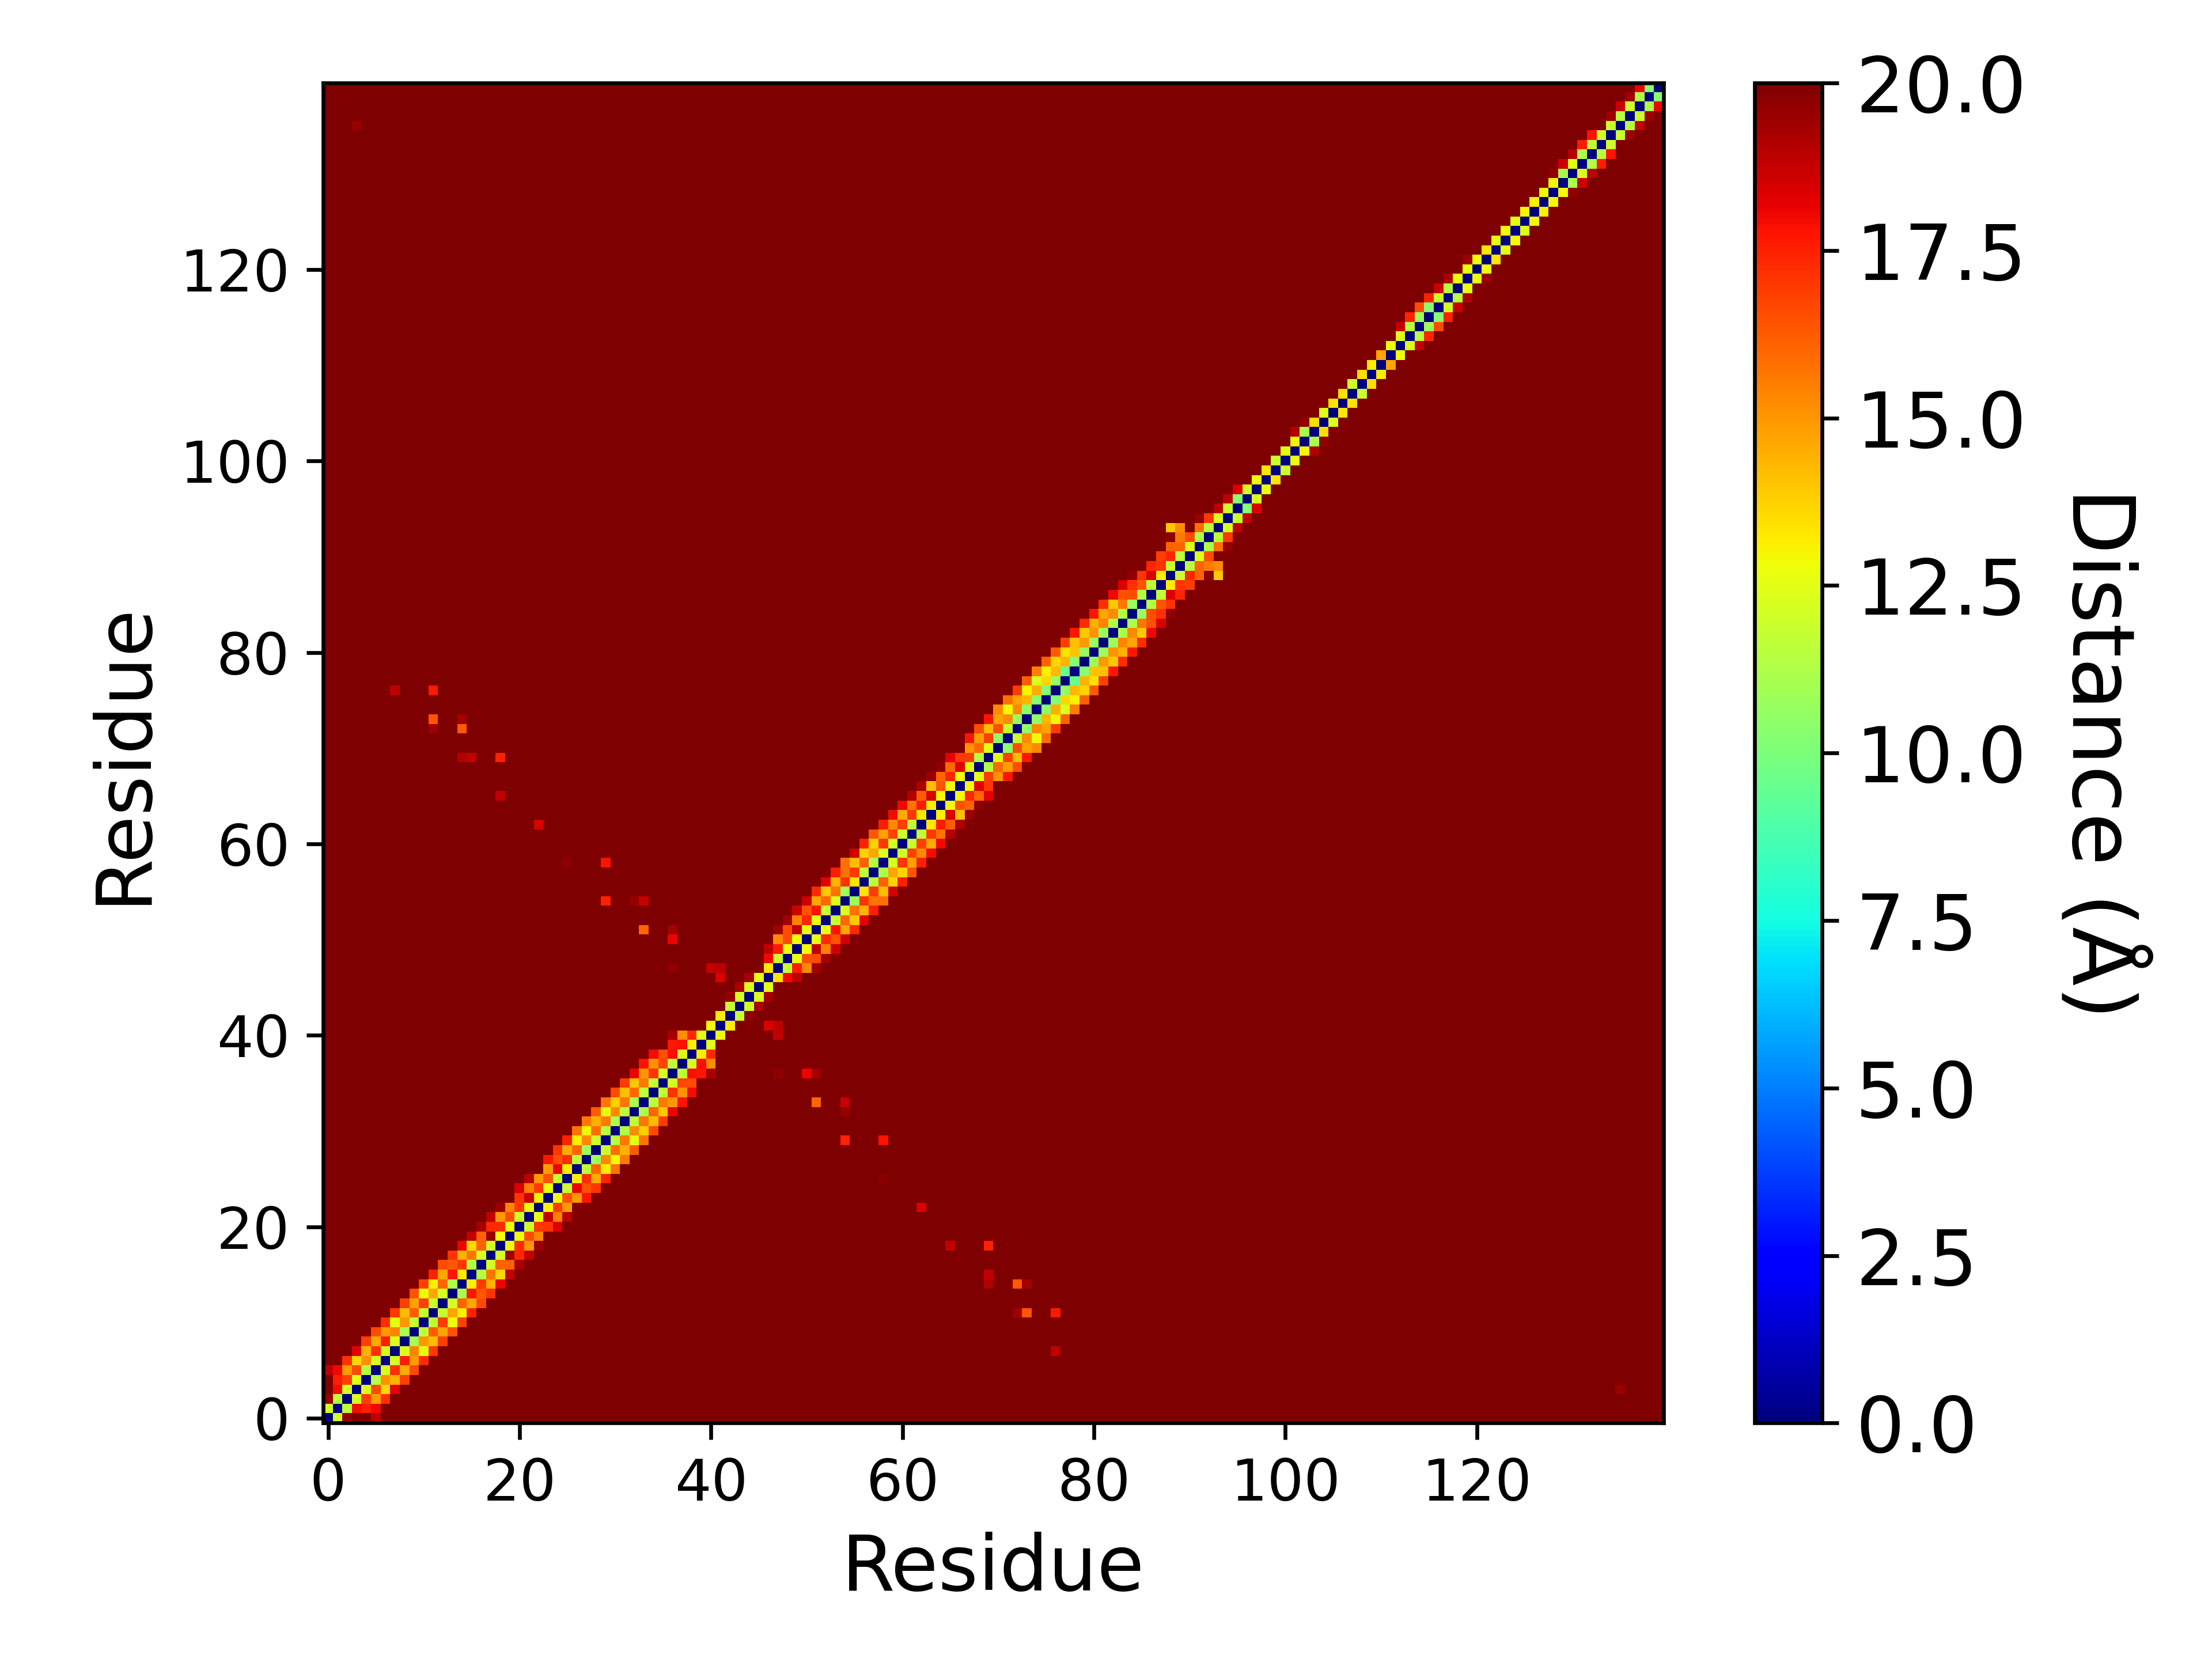

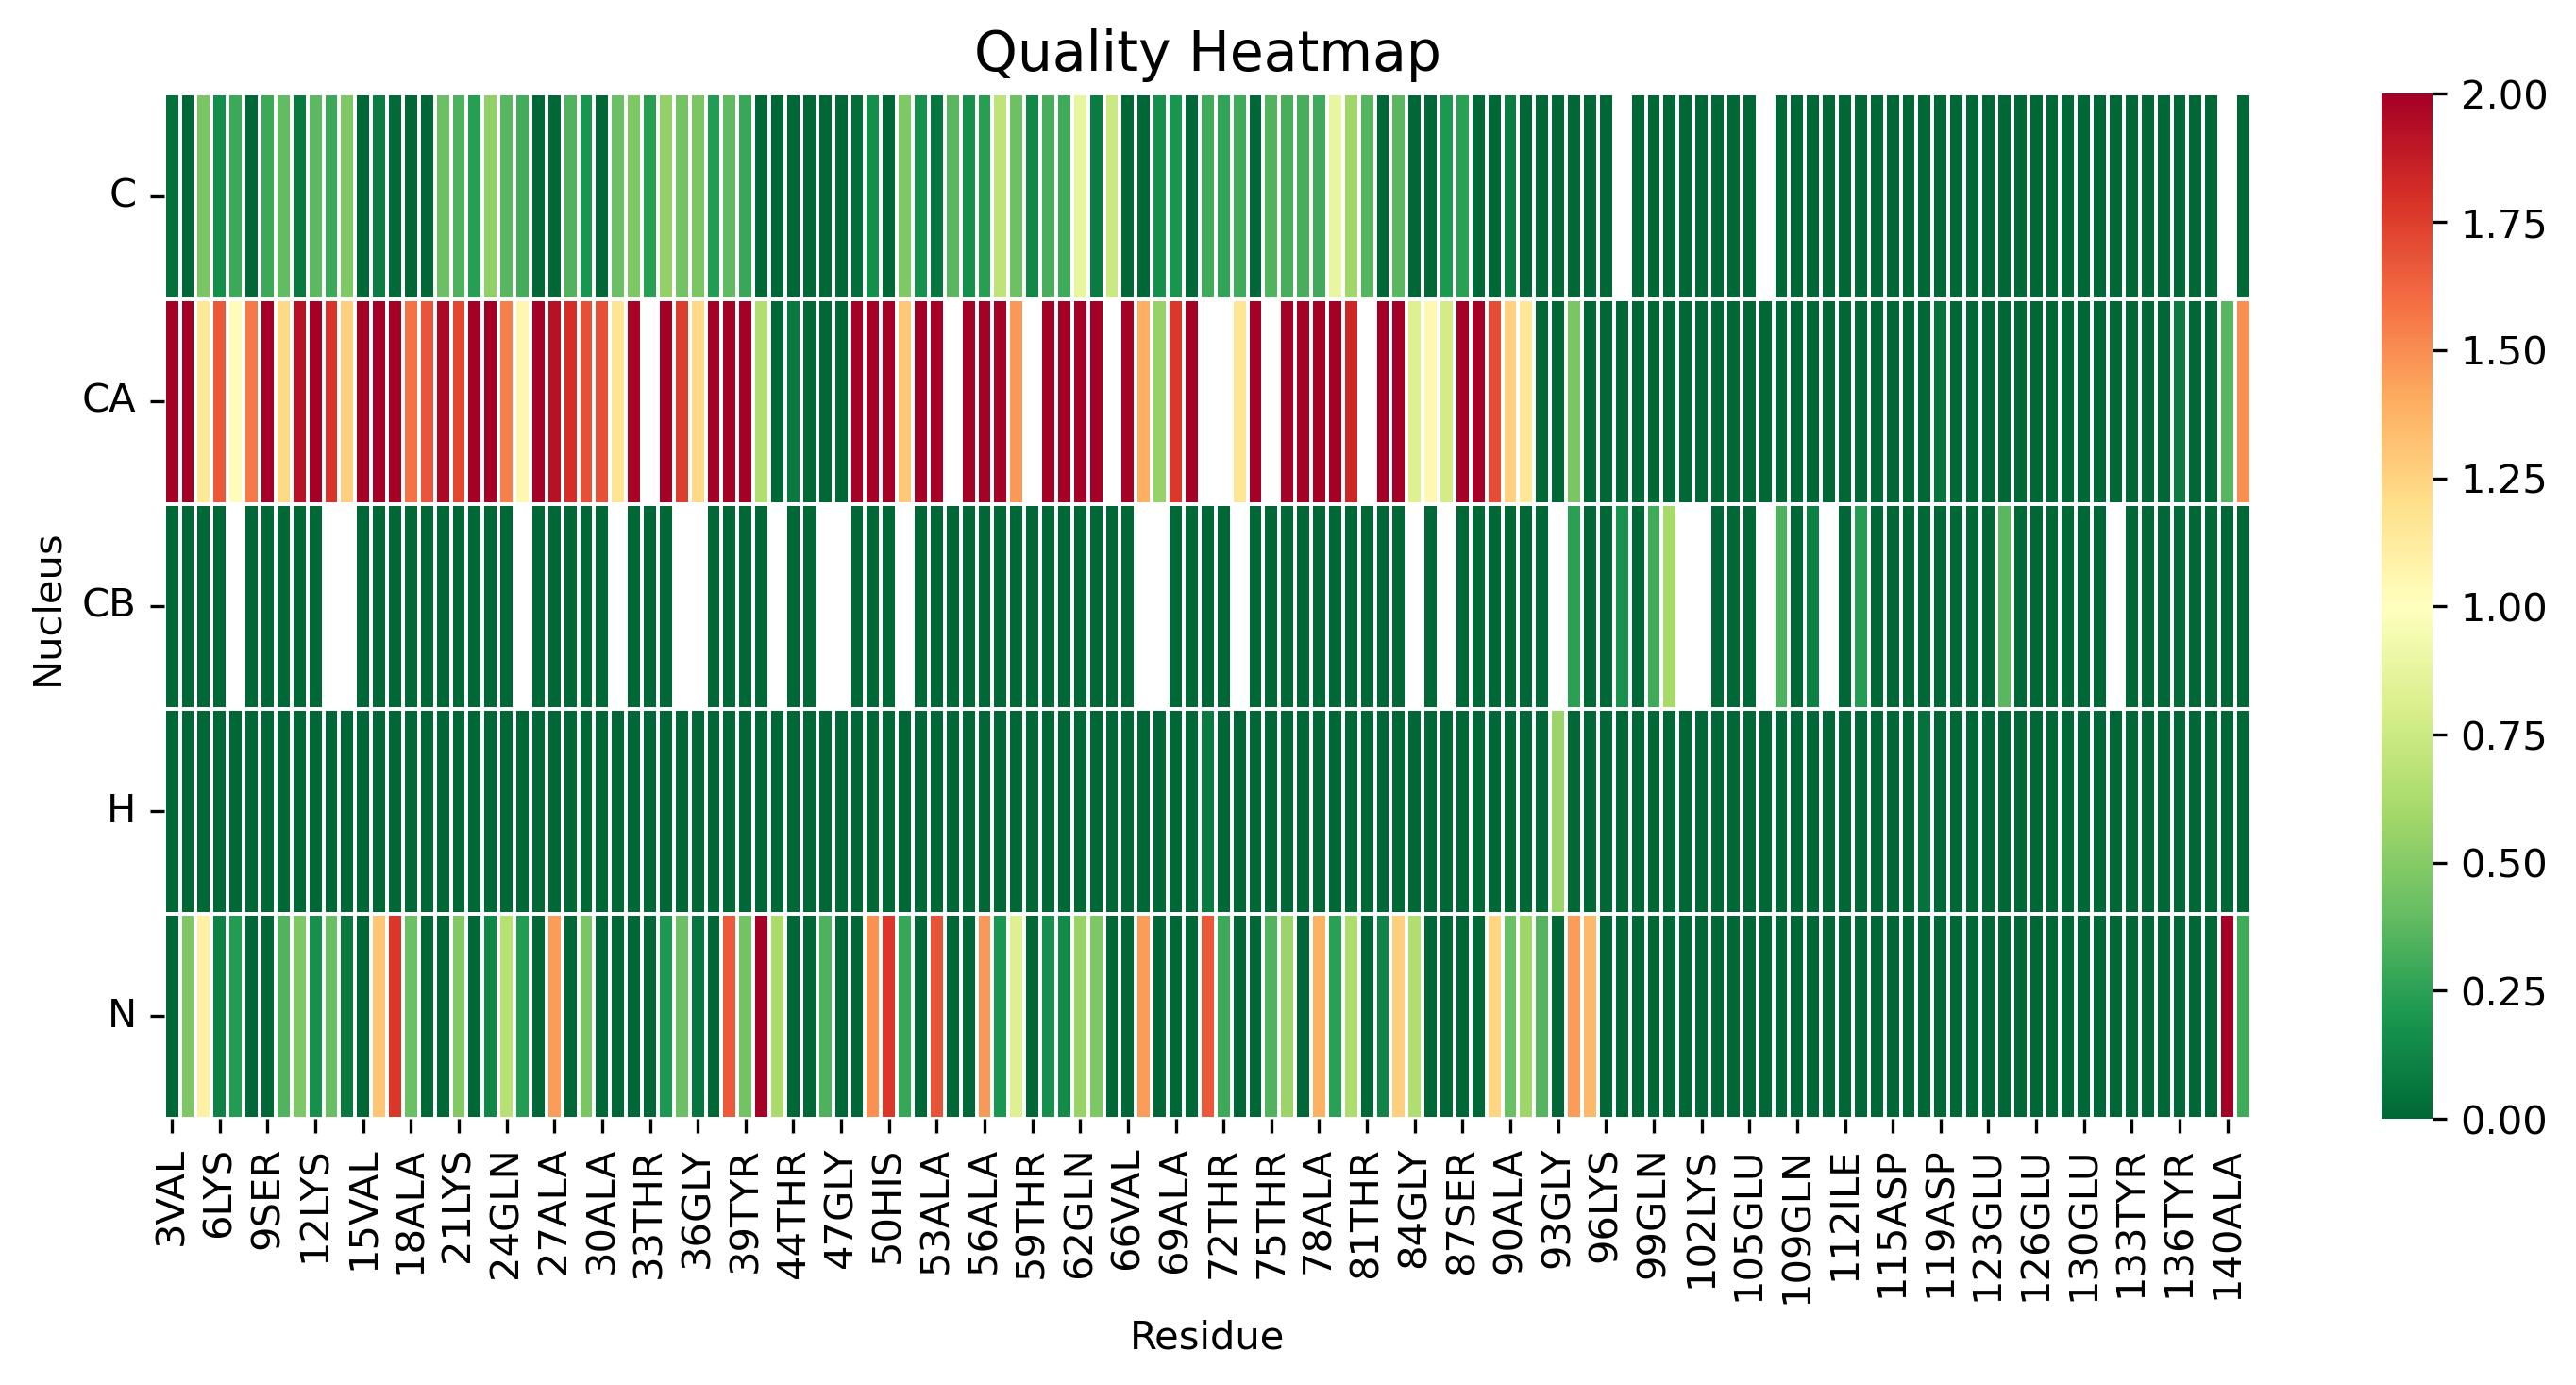

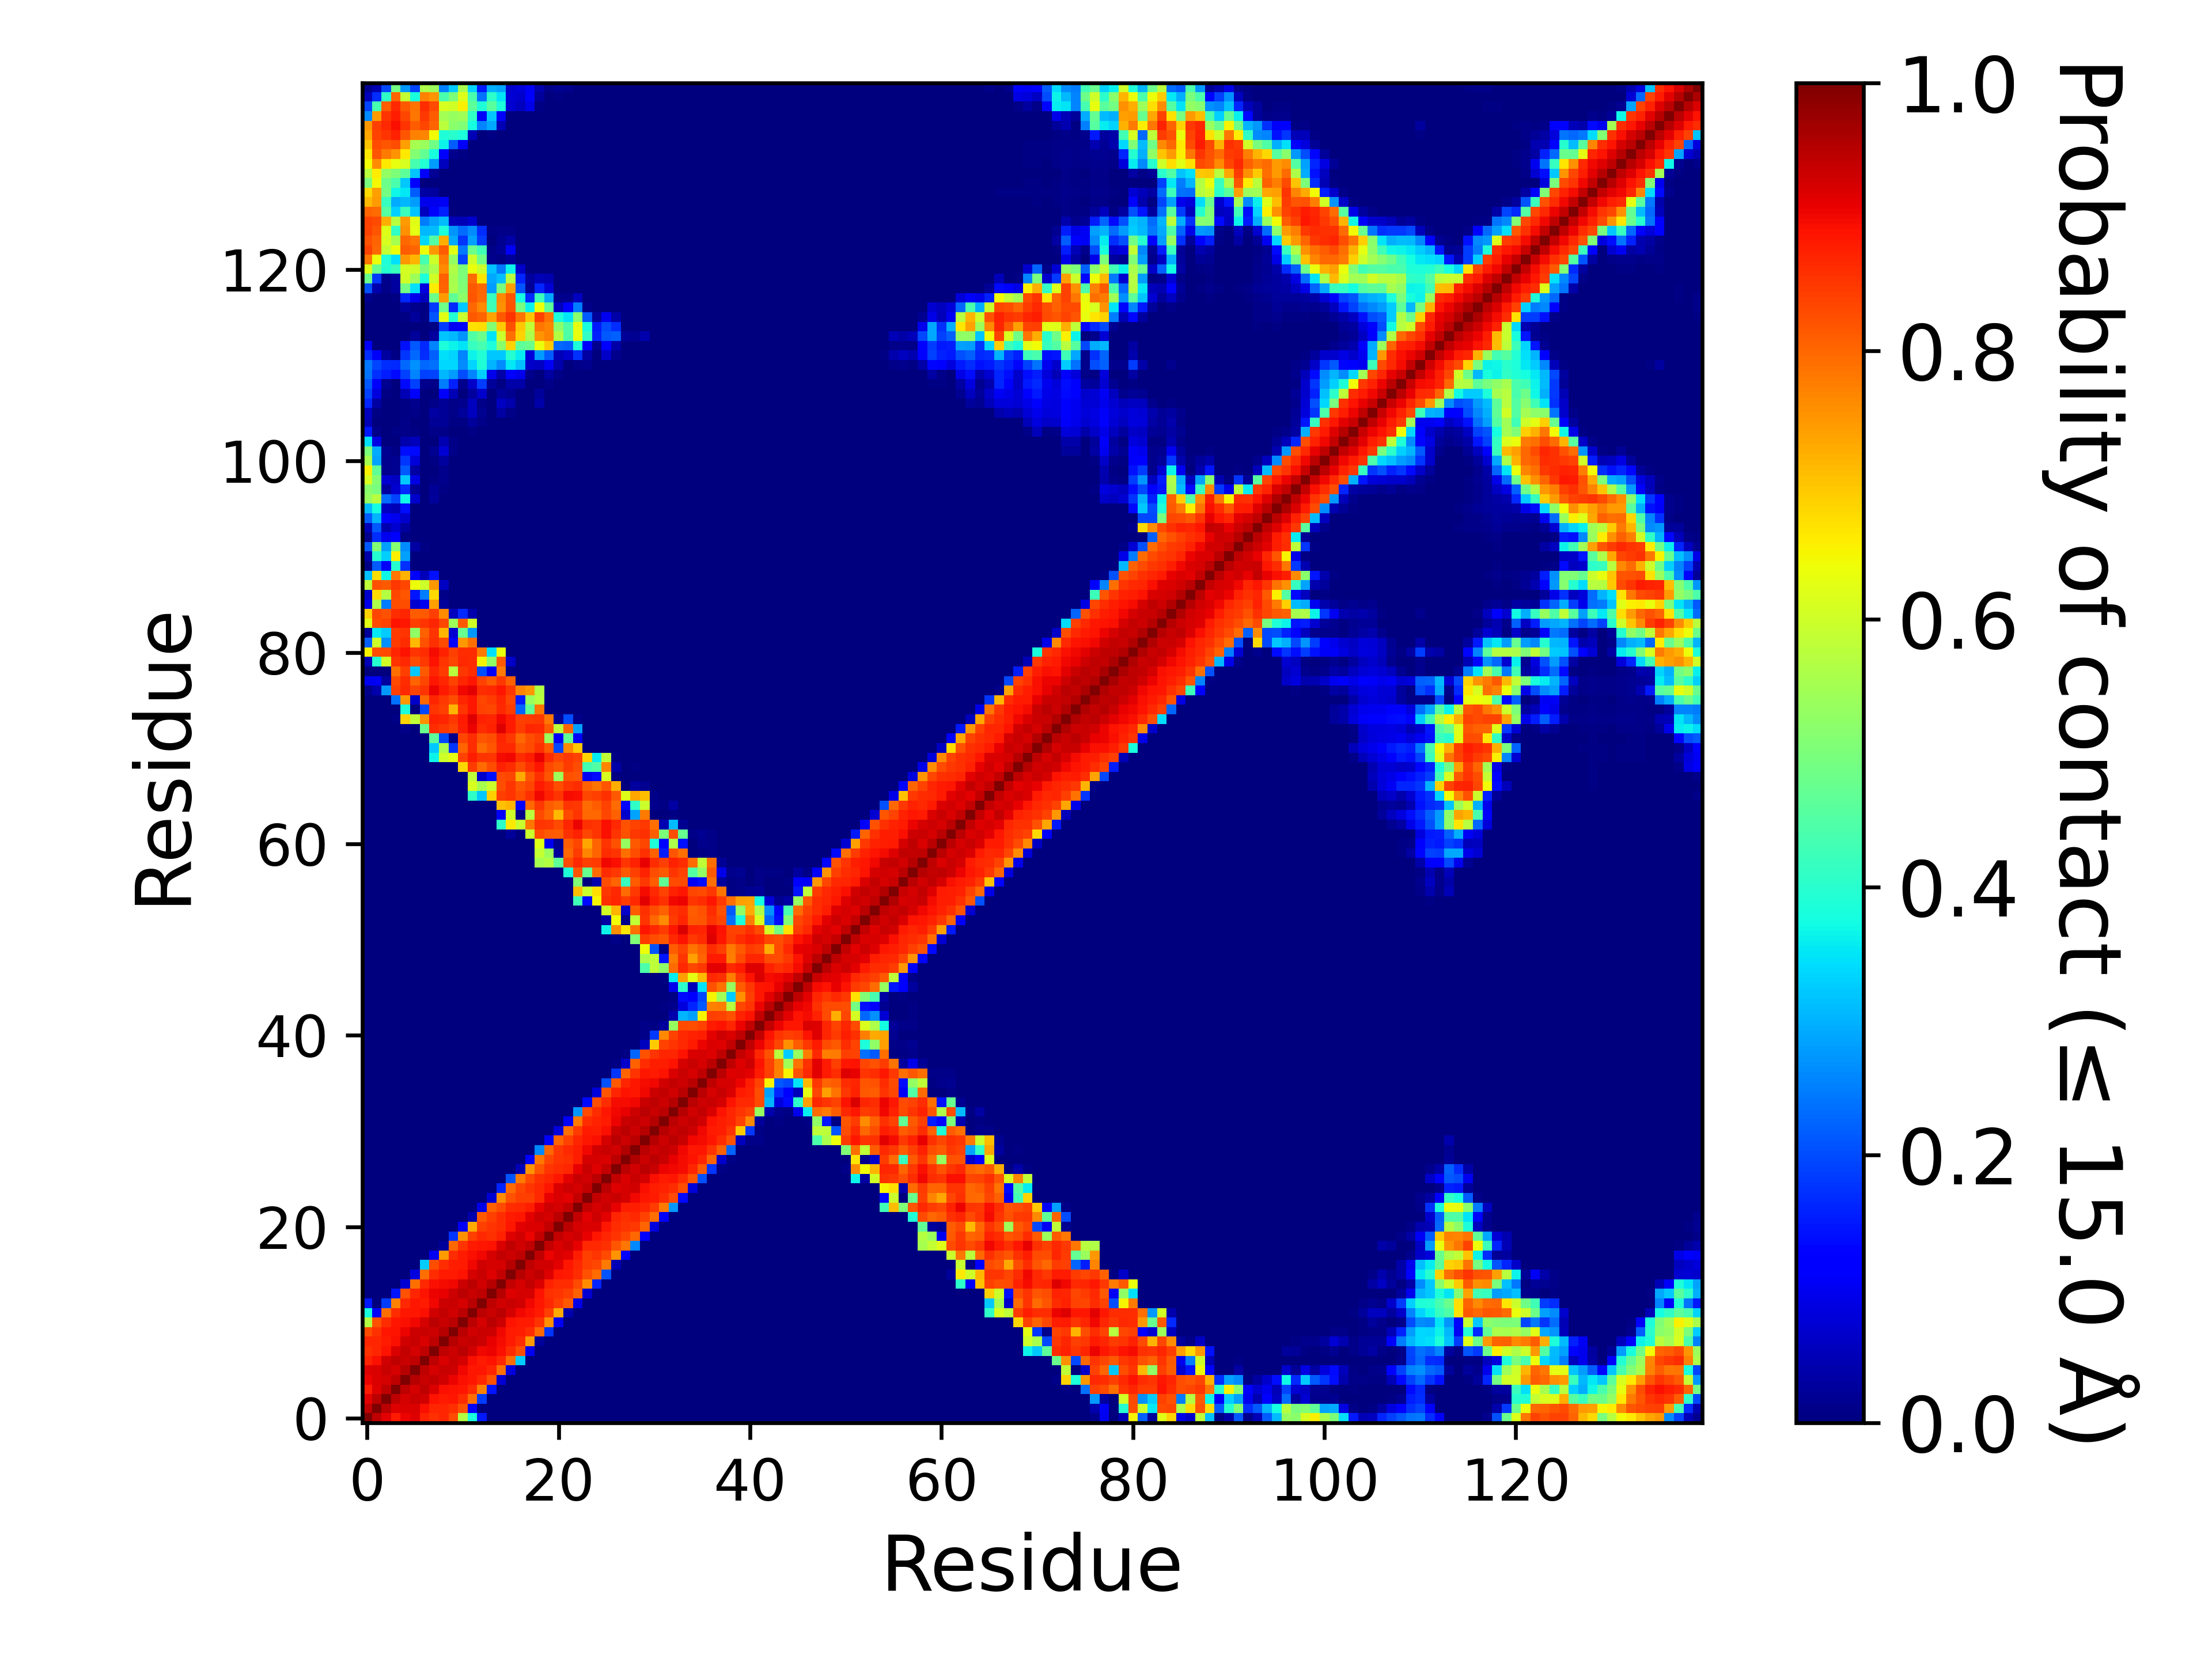

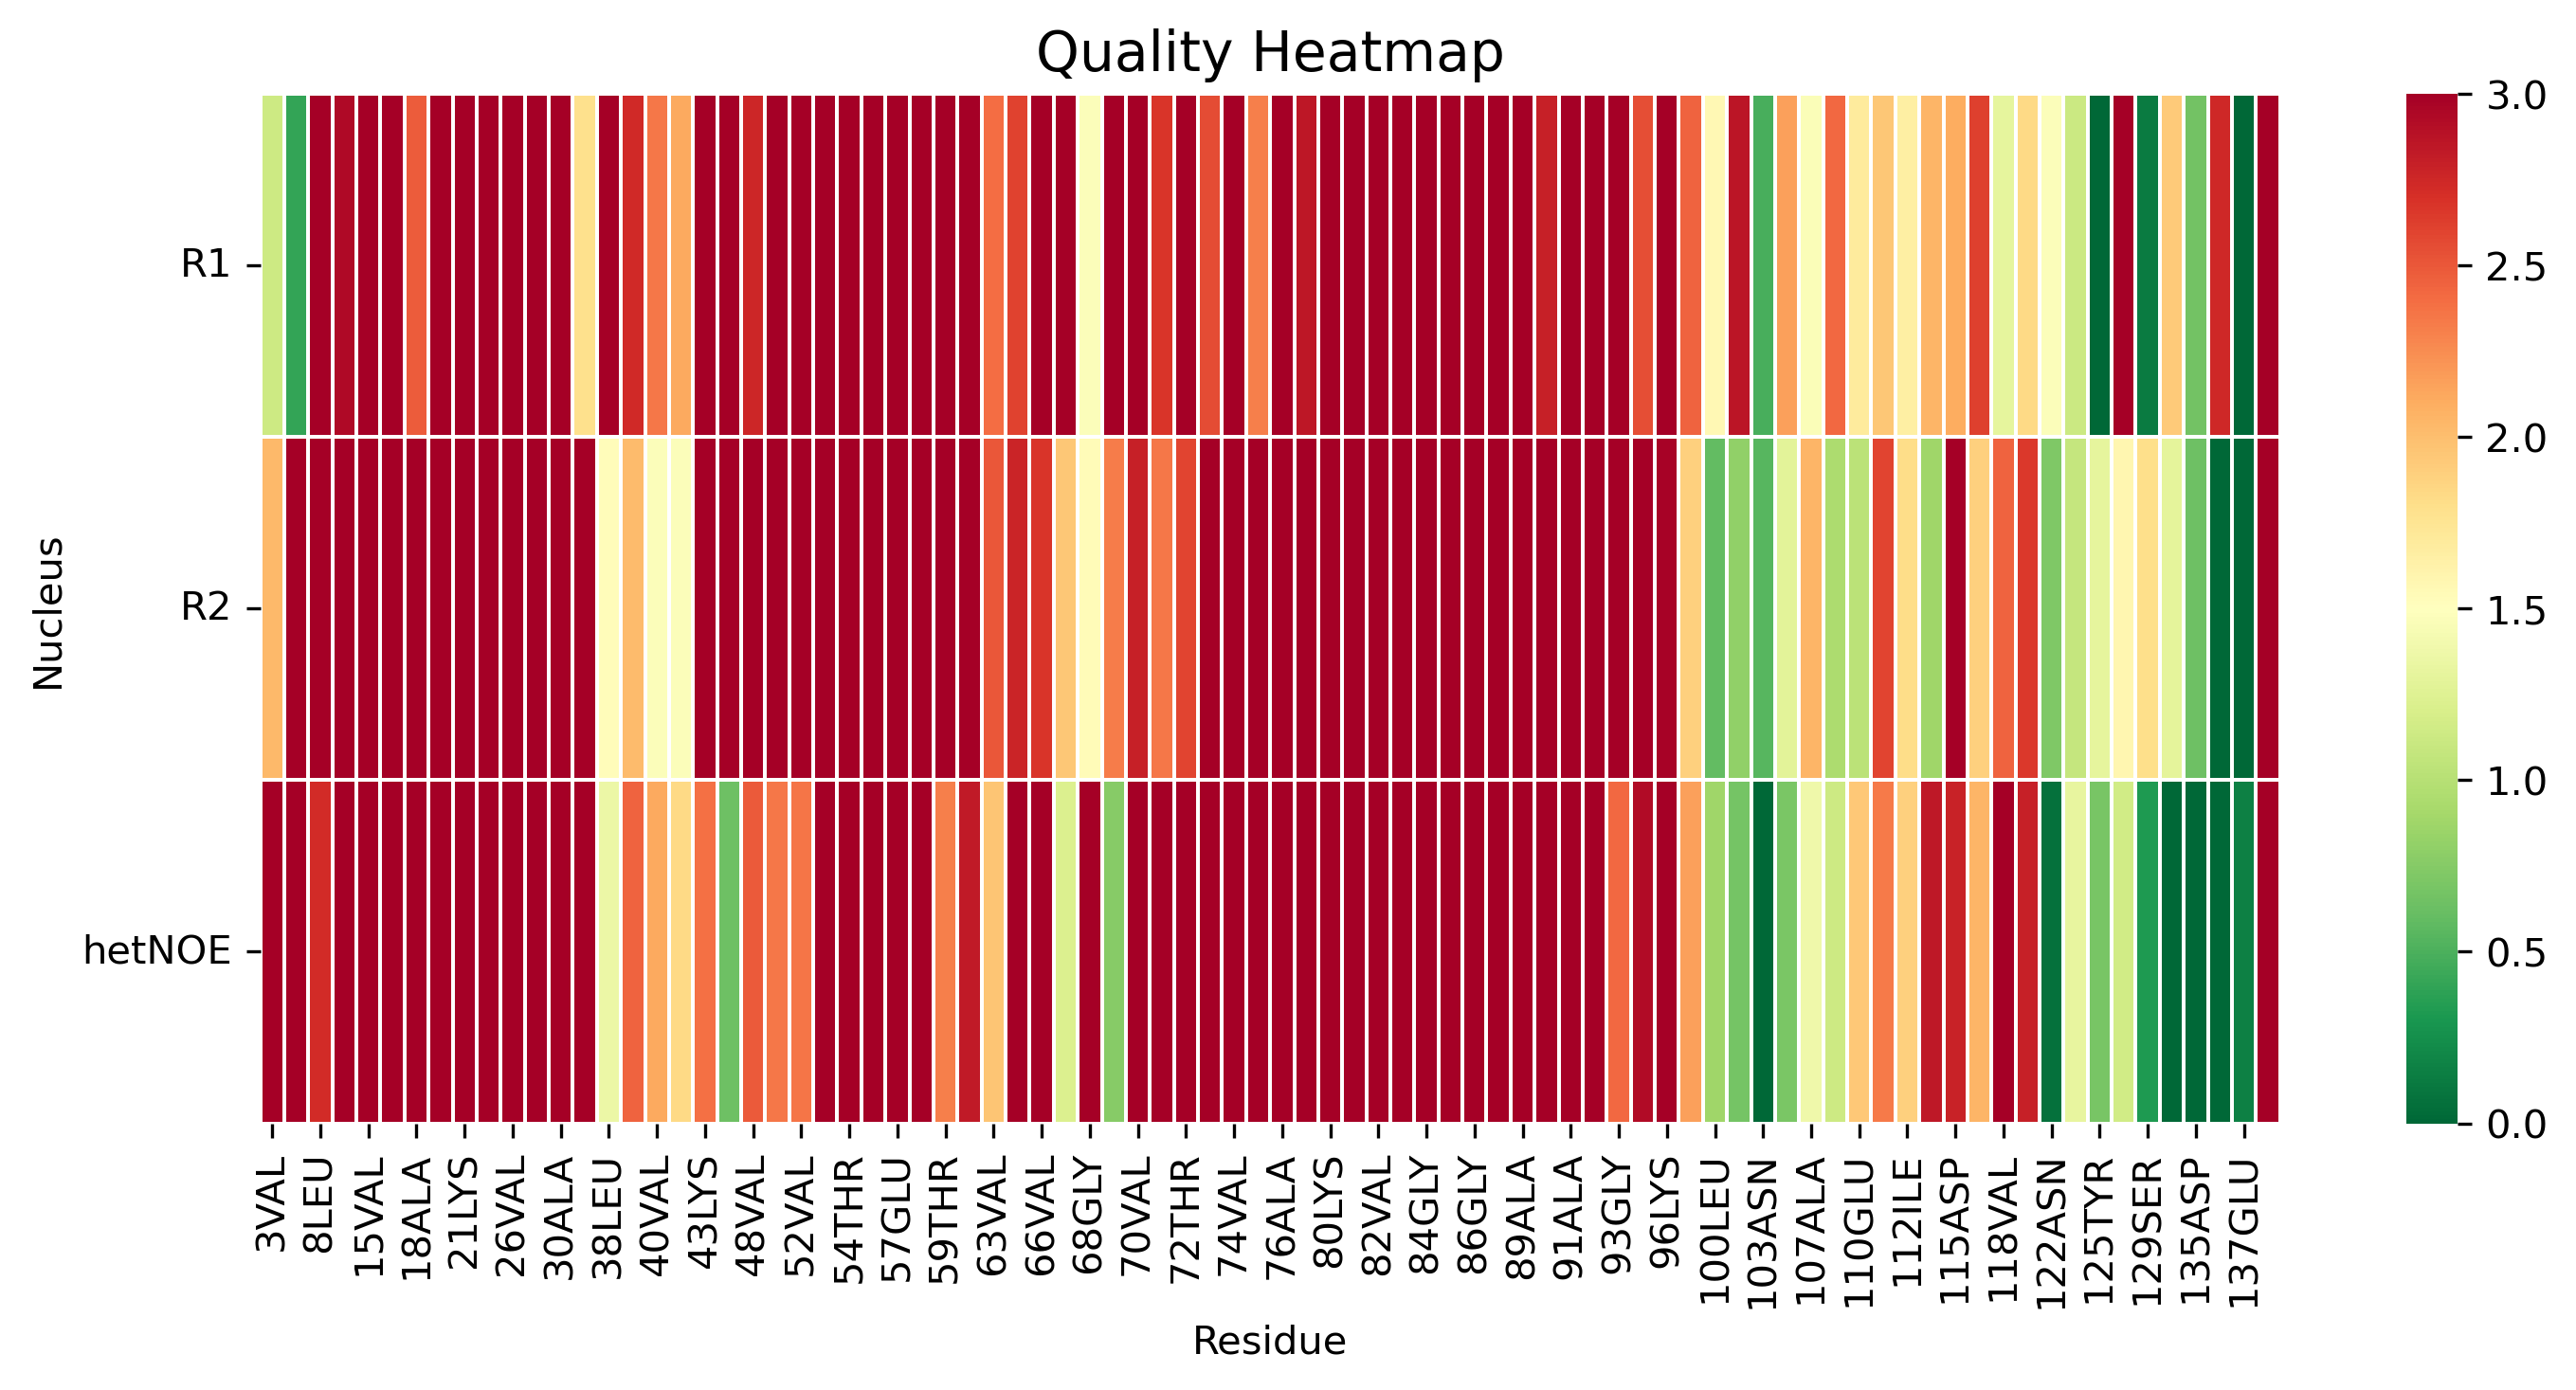

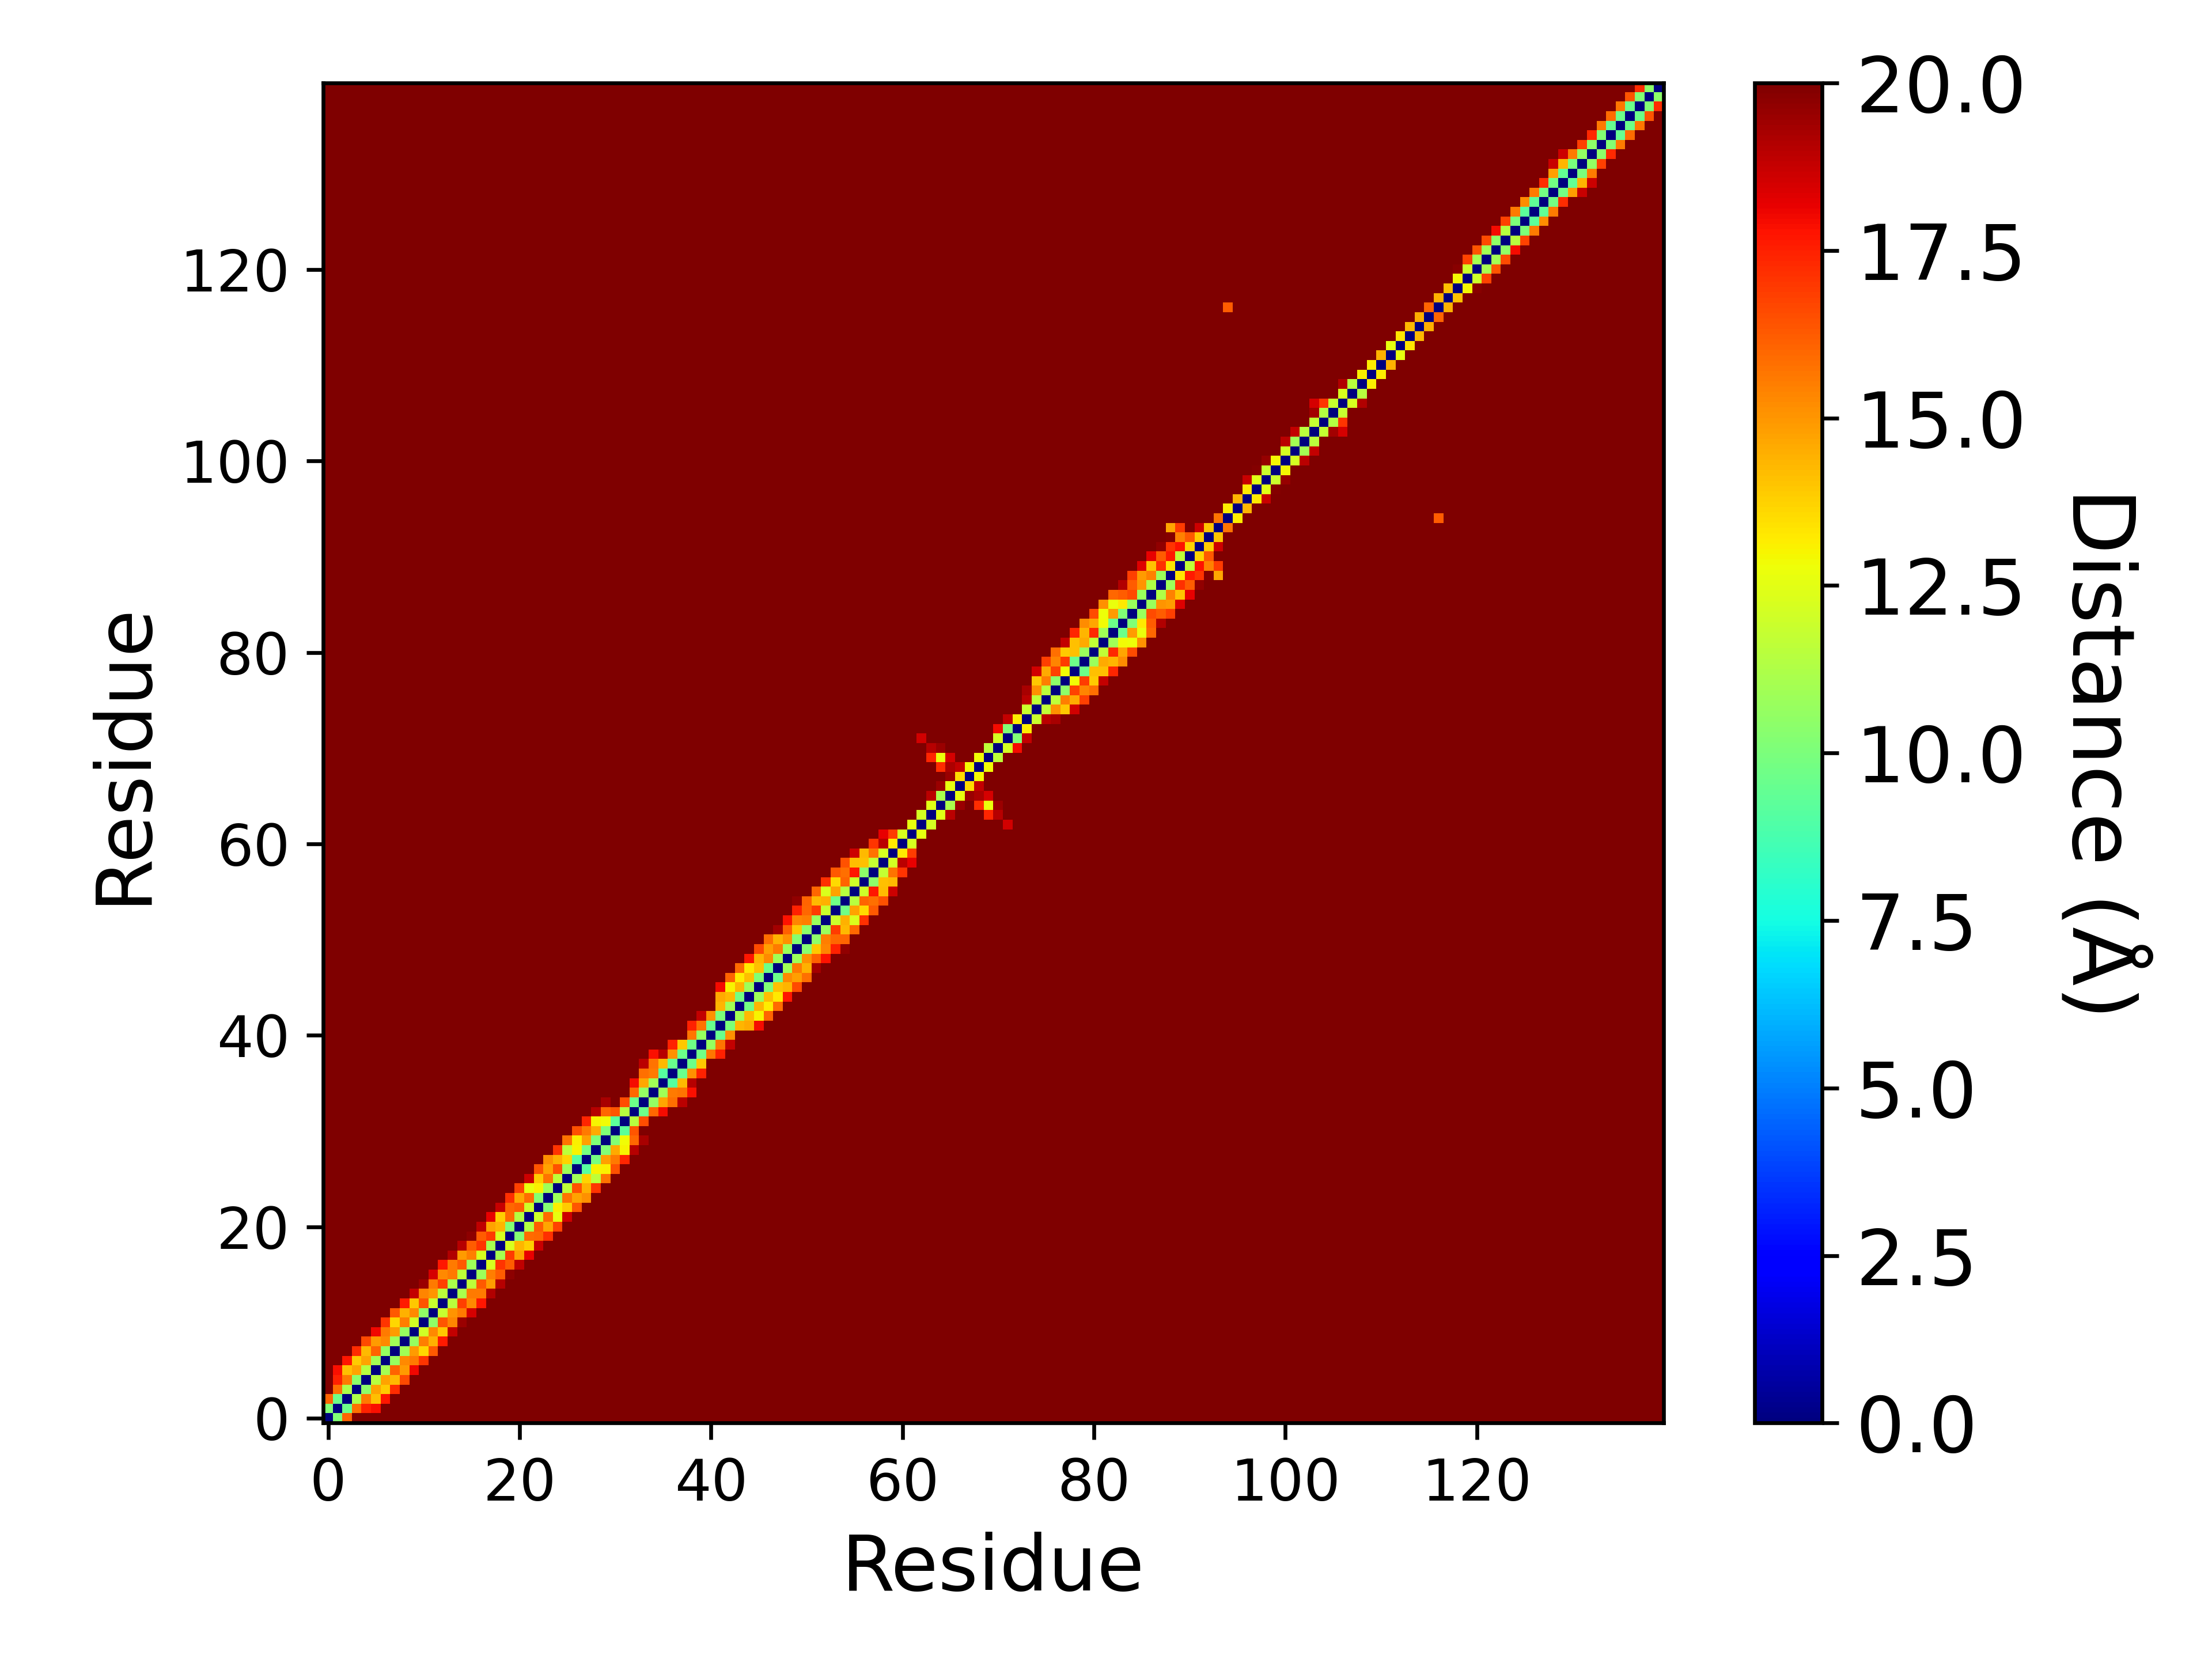

In [22]:
spin_overall = []
shift_overall = []

spin_overall_best = [0,100]
spin_overall_worst = [0,0]


for system in systems:
    dataFolder = databankPath + 'Data/Simulations/' + system['path'] + '/'

    spin_file = dataFolder + 'spin_relaxation_res_quality.yaml'
    shift_file = dataFolder + 'chemical_shift_res_quality.yaml'

    # Load spin relaxation overall percentage
    try:
        with open(spin_file, 'r') as f:
            spin_data = yaml.safe_load(f)
        if 'overall_non_zero_percentage' in spin_data:
            spin_overall_value = spin_data['overall_non_zero_percentage']
            spin_overall.append(spin_overall_value)
            if spin_overall_value < spin_overall_best[1]:
                #print(system, spin_overall_best)
                spin_overall_best = [system['path'],spin_overall_value]
            if spin_overall_value > spin_overall_worst[1]:
                #print(system, spin_overall_best)
                spin_overall_worst = [system['path'],spin_overall_value]
                #print(spin_overall_best)
    except FileNotFoundError:
        pass
        #print(f"Warning: {spin_file} not found")

    # Load chemical shift overall percentage
    try:
        with open(shift_file, 'r') as f:
            shift_data = yaml.safe_load(f)
        if 'overall_non_zero_percentage' in shift_data:
            shift_overall.append(shift_data['overall_non_zero_percentage'])
    except FileNotFoundError:
        pass
        #print(f"Warning: {shift_file} not found")

        
import os
from IPython.display import display, Image

folder = "../../Data/Simulations/" + spin_overall_worst[0]
print(folder)

for file in os.listdir(folder):
    if file.endswith(".png"):
        display(Image(filename=os.path.join(folder, file)))